# Results

Hand-curated analysis of the MLPlatformAgentBench runs in `results.csv`. Not
regenerated by the runner.

The benchmark runs the same FTI task suite across a grid of conditions. The bars
below use one quality metric throughout:

**assert pass rate** = `asserts_passed / total_asserts`, averaged over the `valid`
runs in each group (a run is `valid` when the agent finished and a deliverable was
gradeable). Runs that never produced a gradeable deliverable are excluded from the
mean, so a low bar means the work was wrong, not that the harness crashed. Coverage
(`valid / total`) is reported alongside the tables.

The interface under test is encoded by colour: **grey = CLI, blue = SDK**. The
skill bundle is encoded by shade: **light = no skills, dark = official skills**.

| section | question |
|---|---|
| 1 | overall pass rate per model, with and without skills, per platform |
| 2 | the same, split by task category |
| 3 | every task individually (heatmap) |
| 4 | CLI optimizations vs baseline, with and without the tuned skill bundle |
| 5 | data validity: audit, exclusions and their rationale |
| 6 | statistical analysis: paired tests per comparison family, Holm-corrected |
| 7 | efficiency frontier: who reaches the ceiling at the lowest cost and fewest turns |

All numbers are computed on the **cleaned** data: one duplicate attempt is
deduplicated and 8 rows whose failure was traced to the harness rather than the
agent are excluded (4 grader crashes, 4 grading-convention artifacts). Section 5
documents each exclusion.

Models: `opus` = claude-opus-4-8, `sonnet` = claude-sonnet-4-6, `fable` =
claude-fable-5, plus mistral-large-3 and mistral-medium-3-5. Fable and the mistral
models were run only without skills, and Fable only partially, so their bars appear
only where data exists.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.color": "#e6e6e6",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.edgecolor": "#bdbdbd",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

raw = pd.read_csv("results.csv")
for c in ["asserts_passed", "total_asserts", "local_time_s", "cost_usd", "llm_calls", "n"]:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")
raw["valid"] = raw["valid"].astype(str).str.lower() == "true"
raw["success"] = raw["success"].astype(str).str.lower() == "true"  # all asserts passed
raw["pass_rate"] = raw["asserts_passed"] / raw["total_asserts"]

# --- cleaning (rationale in section 5) ---
# (a) one combo was attempted twice; keep the latest attempt only.
df = raw.sort_values("n").drop_duplicates(
    subset=["config", "interface", "skills", "category", "task"], keep="last")
# (b) grader-infra crashes: the harness failed to grade, the agent was never judged.
_infra = df["error"].astype(str).str.contains("grader failed to run", na=False)
# (c) gcp full_reload: versioned-table grading-convention artifact (section 5).
_artifact = (df.platform == "gcp") & (df.task == "full_reload")
excluded = df[_infra | _artifact].copy()
df = df[~(_infra | _artifact)].copy()

# config id per (platform, model)
CFG = {
    "hopsworks": {
        "opus": "1_hw-full-cli-sdk-skills-opus",
        "mistral-large": "2_hw-full-cli-sdk-skills-mistral-large",
        "sonnet": "3_hw-full-cli-sdk-skills-sonnet",
        "mistral-medium": "4_hw-full-cli-sdk-skills-mistral-medium",
        "fable": "23_hw-full-cli-sdk-fable",
    },
    "databricks": {
        "opus": "18_db-full-cli-sdk-skills-opus",
        "mistral-large": "20_db-full-cli-sdk-skills-mistral-large",
        "sonnet": "19_db-full-cli-sdk-skills-sonnet",
        "mistral-medium": "21_db-full-cli-sdk-skills-mistral-medium",
        "fable": "24_db-full-cli-sdk-fable",
    },
    "gcp": {
        "opus": "22_gcp-full-cli-sdk-skills-opus",
    },
}
PLATFORMS = ["hopsworks", "databricks", "gcp"]
MODEL_ORDER = ["opus", "mistral-large", "sonnet", "mistral-medium", "fable"]

# the four interface x skills variants, fixed order + fixed colours
VARIANTS = [("cli", "none"), ("cli", "official"), ("sdk", "none"), ("sdk", "official")]
VLABEL = {
    ("cli", "none"): "CLI, no skills",
    ("cli", "official"): "CLI, +skills",
    ("sdk", "none"): "SDK, no skills",
    ("sdk", "official"): "SDK, +skills",
}
VCOLOR = {
    ("cli", "none"): "#b0bec5",
    ("cli", "official"): "#546e7a",
    ("sdk", "none"): "#64b5f6",
    ("sdk", "official"): "#1565c0",
}
CATEGORIES = ["feature", "training", "inference", "ops", "capstone"]


def sel(cfg, iface=None, sk=None, category=None, task=None):
    m = df.config == cfg
    if iface is not None:
        m &= df.interface == iface
    if sk is not None:
        m &= df.skills == sk
    if category is not None:
        m &= df.category == category
    if task is not None:
        m &= df.task == task
    return df[m]


def rate(d):
    """Mean assert pass rate over valid runs; NaN when there are none."""
    v = d[d.valid]
    if len(v) == 0:
        return np.nan
    return v.pass_rate.mean()


def legend_handles():
    return [Patch(facecolor=VCOLOR[v], label=VLABEL[v]) for v in VARIANTS]


def bar_labels(ax, bars, vals):
    for b, h in zip(bars, vals):
        if pd.notna(h):
            ax.annotate(f"{h:.0%}", (b.get_x() + b.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=6, rotation=90,
                        color="#333")

## 1. Overall pass rate per model and platform

One bar per interface x skills variant, grouped by model, one panel per platform.
Grey = CLI, blue = SDK, light = no skills, dark = official skills. Empty slots have
no runs (Fable and the mistral models were run without skills only, GCP with Opus
only).

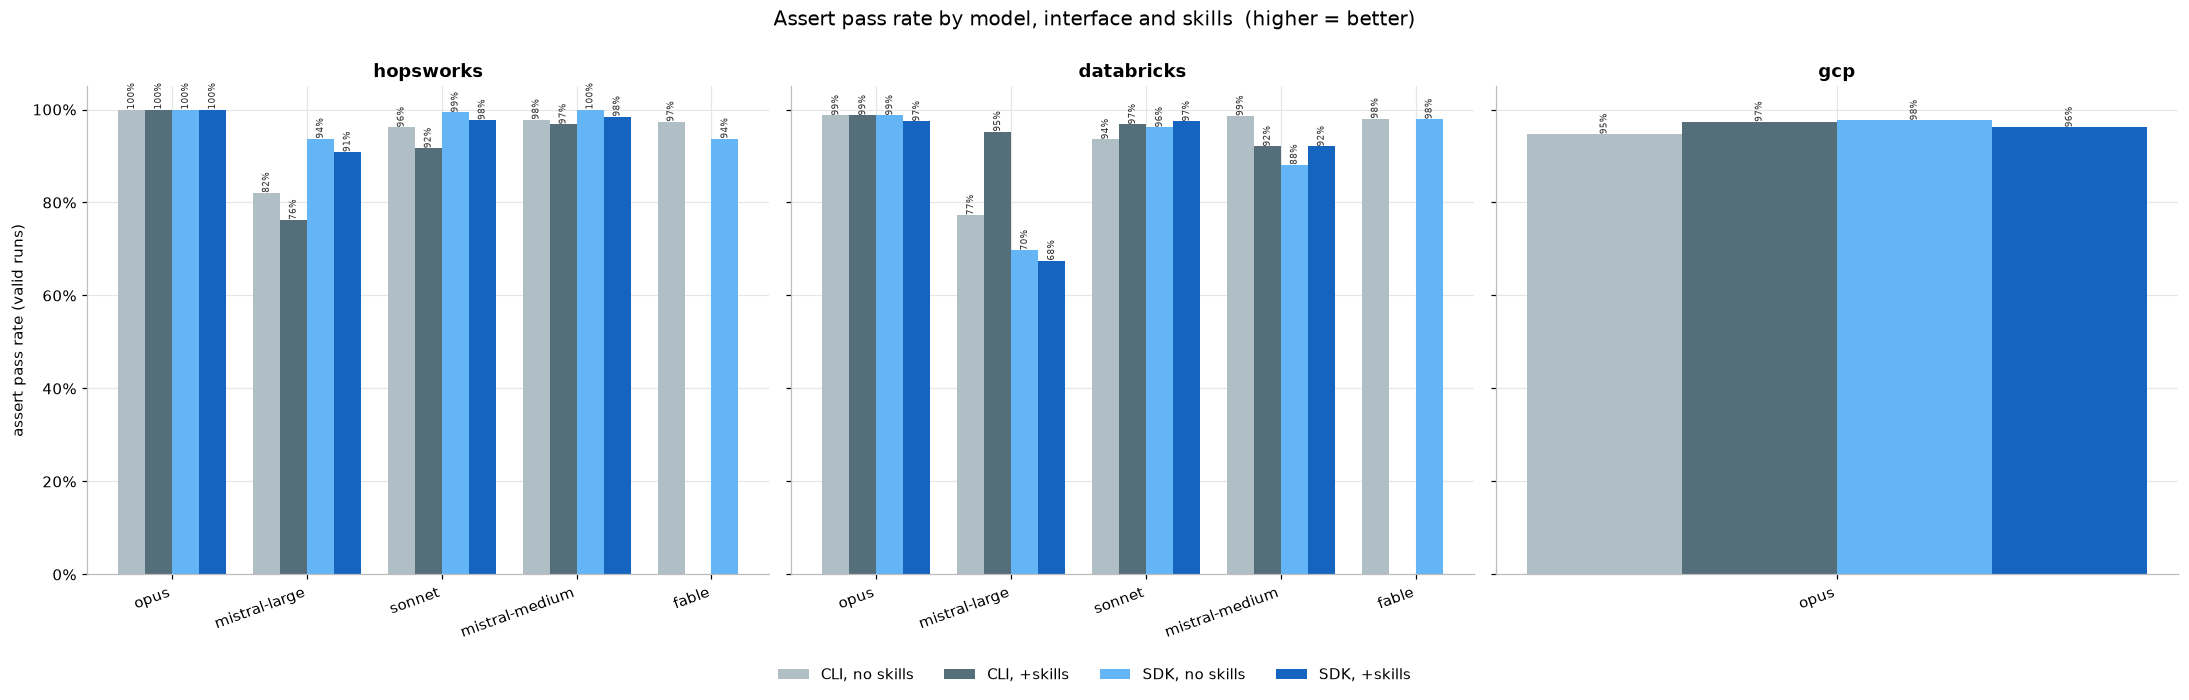

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
w = 0.2
for ax, plat in zip(axes, PLATFORMS):
    models = [m for m in MODEL_ORDER if m in CFG[plat]]
    x = np.arange(len(models))
    for j, (iface, sk) in enumerate(VARIANTS):
        vals = [rate(sel(CFG[plat][m], iface, sk)) for m in models]
        bars = ax.bar(x + (j - 1.5) * w, vals, w, color=VCOLOR[(iface, sk)])
        bar_labels(ax, bars, vals)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, ha="right")
    ax.set_title(plat, fontsize=12, fontweight="bold")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("assert pass rate (valid runs)")
fig.legend(handles=legend_handles(), loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.04), frameon=False)
fig.suptitle("Assert pass rate by model, interface and skills  (higher = better)",
             fontsize=13, y=1.0)
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.show()

Underlying numbers, including coverage (`valid / total`):

In [3]:
rows = []
for plat in PLATFORMS:
    for m in [m for m in MODEL_ORDER if m in CFG[plat]]:
        cfg = CFG[plat][m]
        for iface, sk in VARIANTS:
            s = sel(cfg, iface, sk)
            if len(s) == 0:
                continue
            v = s[s.valid]
            rows.append({
                "platform": plat, "model": m, "interface": iface, "skills": sk,
                "coverage": f"{len(v)}/{len(s)}",
                "pass_rate": rate(s),
            })
tbl1 = pd.DataFrame(rows).set_index(["platform", "model", "interface", "skills"])
tbl1.style.format({"pass_rate": "{:.1%}"})

## 1b. Local compute time, cost and LLM turns

The same model x interface x skills layout, for three efficiency metrics, averaged
over valid runs (lower = leaner):

- **local_time_s** — wall time the agent spent working locally, with platform
  provisioning/teardown waits and rate-limit back-offs already excluded. This is
  the agent's own thinking-and-tool time, so it is comparable across platforms and
  is not inflated by a slow cloud or a throttled key.
- **cost_usd** — dollar cost of the run (model tokens).
- **llm_calls** — number of LLM turns (model round-trips) the agent took to finish
  the task.

Panels share a y-axis within each figure so platforms are directly comparable.

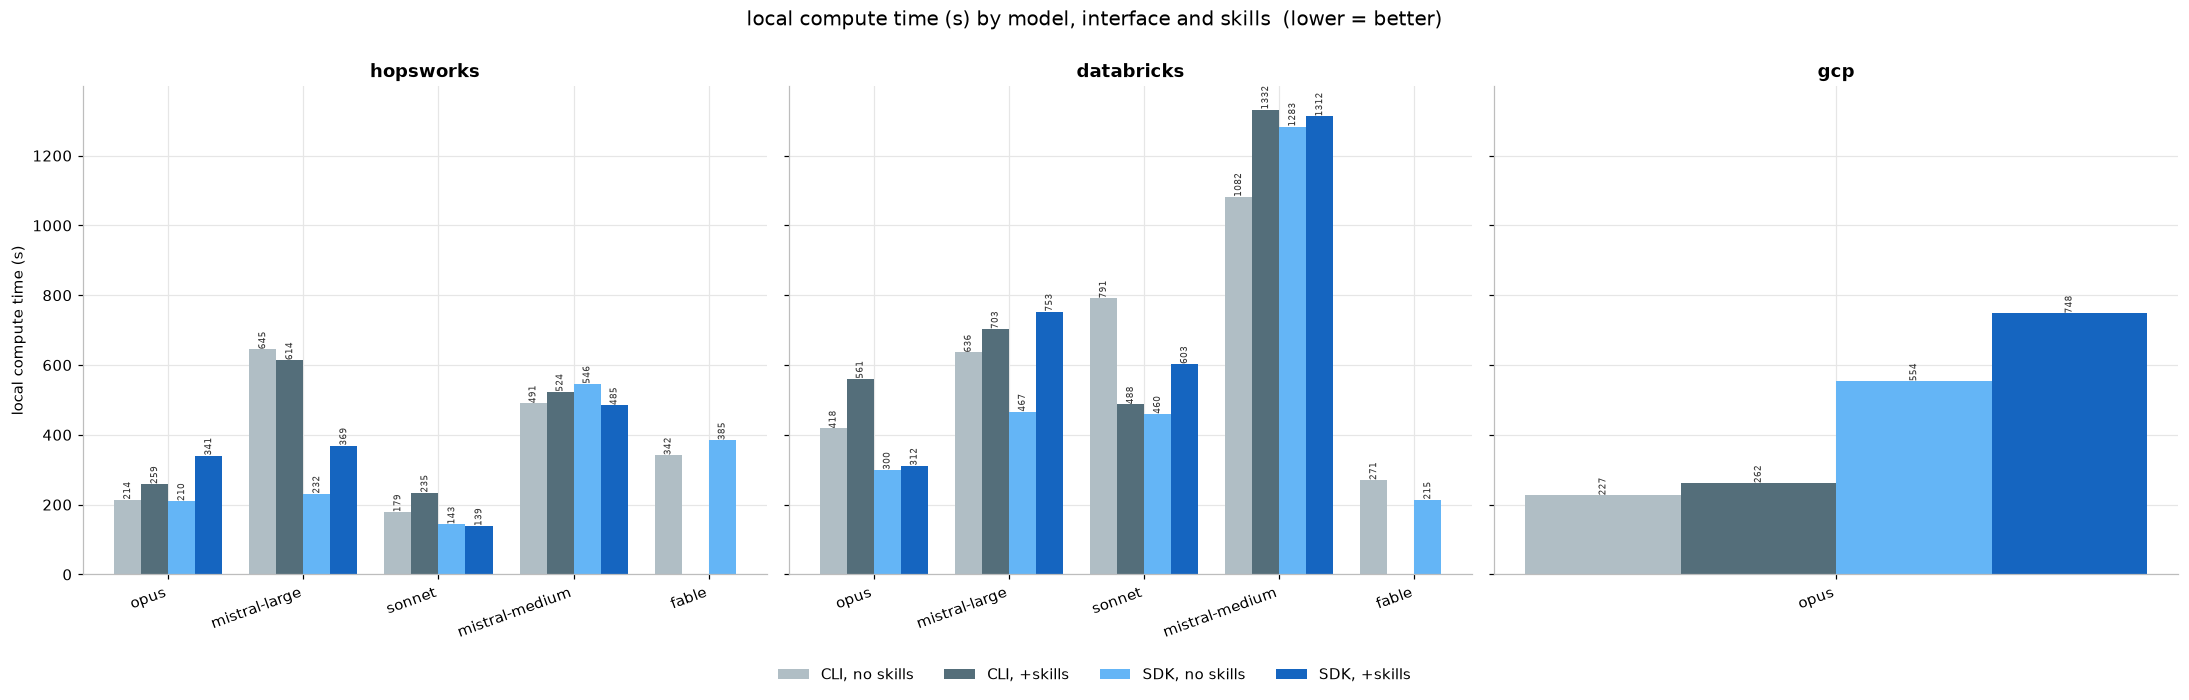

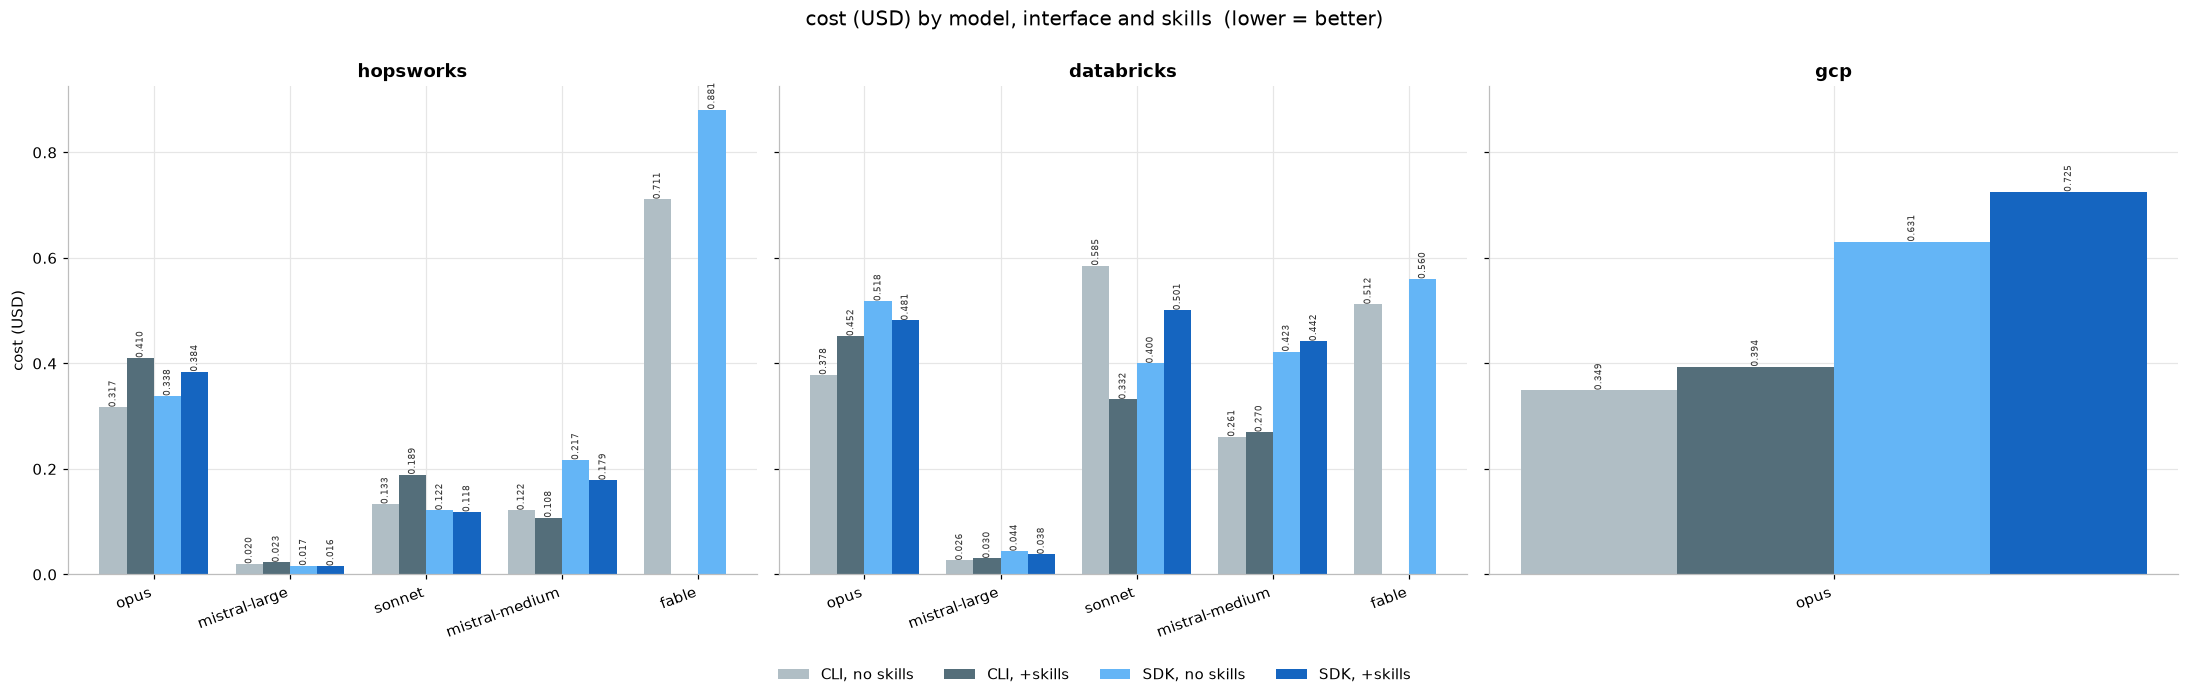

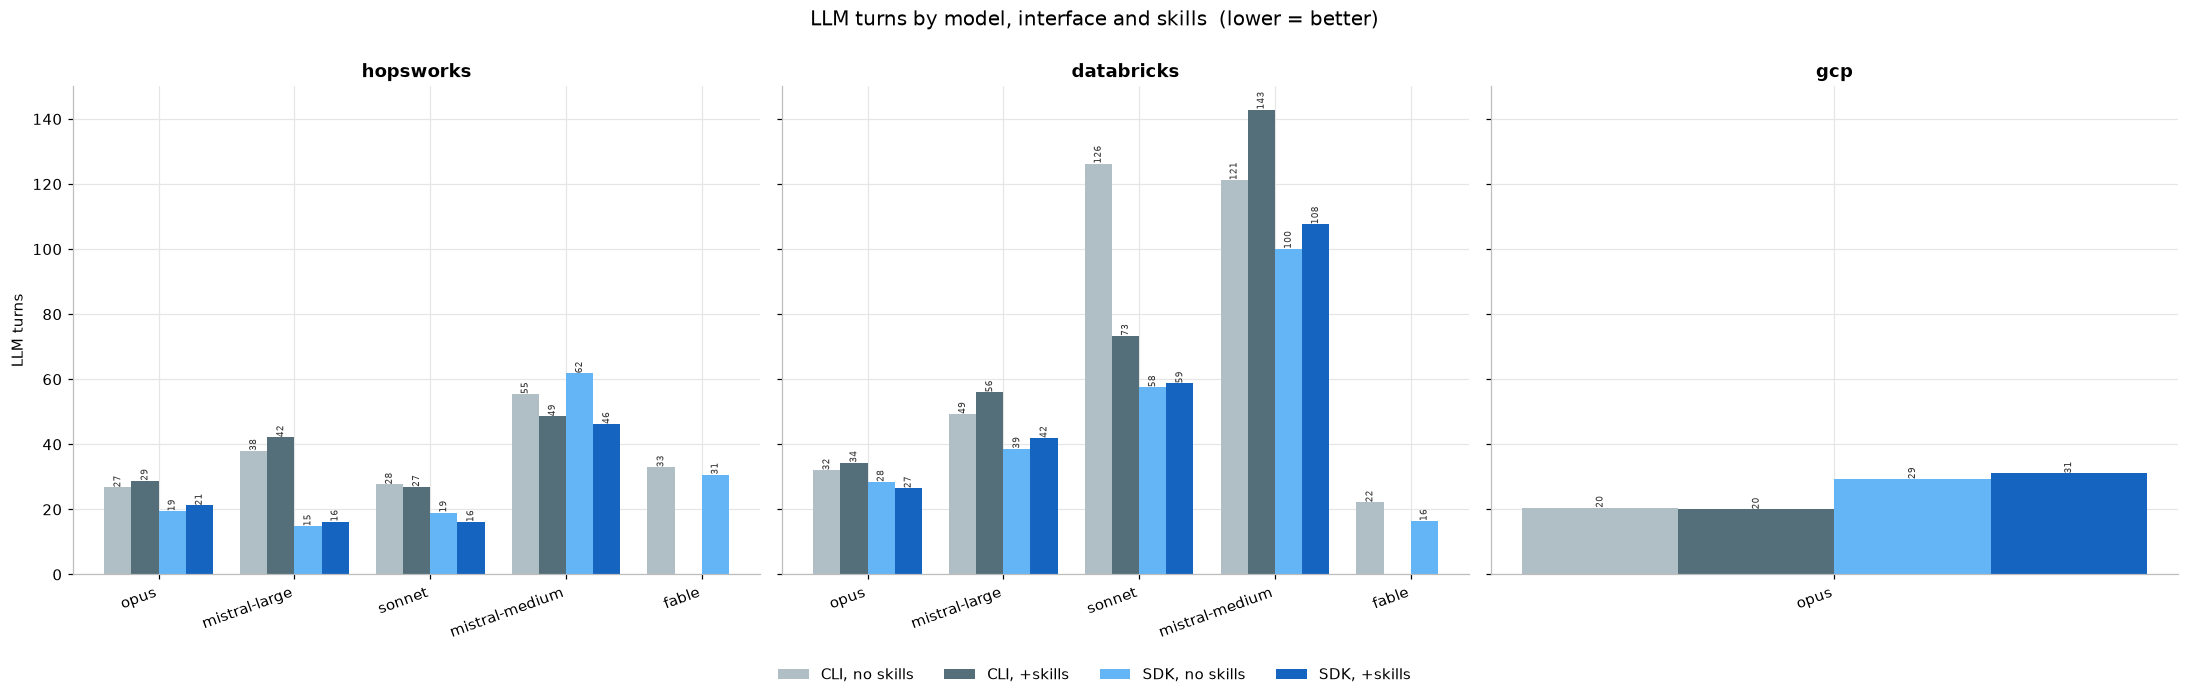

In [4]:
def avg(d, col):
    v = d[d.valid]
    return v[col].mean() if len(v) else np.nan

EFF = [
    ("local_time_s", "local compute time (s)", "{:.0f}"),
    ("cost_usd",     "cost (USD)",             "{:.3f}"),
    ("llm_calls",    "LLM turns",              "{:.0f}"),
]
w = 0.2
for col, title, fmt in EFF:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
    for ax, plat in zip(axes, PLATFORMS):
        models = [m for m in MODEL_ORDER if m in CFG[plat]]
        x = np.arange(len(models))
        for j, (iface, sk) in enumerate(VARIANTS):
            vals = [avg(sel(CFG[plat][m], iface, sk), col) for m in models]
            bars = ax.bar(x + (j - 1.5) * w, vals, w, color=VCOLOR[(iface, sk)])
            for b, h in zip(bars, vals):
                if pd.notna(h):
                    ax.annotate(fmt.format(h),
                                (b.get_x() + b.get_width() / 2, h),
                                ha="center", va="bottom", fontsize=6, rotation=90,
                                color="#333")
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=20, ha="right")
        ax.set_title(plat, fontsize=12, fontweight="bold")
    axes[0].set_ylabel(title)
    fig.legend(handles=legend_handles(), loc="lower center", ncol=4,
               bbox_to_anchor=(0.5, -0.04), frameon=False)
    fig.suptitle(f"{title} by model, interface and skills  (lower = better)",
                 fontsize=13, y=1.0)
    plt.tight_layout(rect=(0, 0.02, 1, 1))
    plt.show()

Mean local time, cost and LLM turns per cell (valid runs):

In [5]:
eff_rows = []
for plat in PLATFORMS:
    for m in [m for m in MODEL_ORDER if m in CFG[plat]]:
        for iface, sk in VARIANTS:
            s = sel(CFG[plat][m], iface, sk)
            if len(s) == 0:
                continue
            eff_rows.append({
                "platform": plat, "model": m, "interface": iface, "skills": sk,
                "local_time_s": avg(s, "local_time_s"),
                "cost_usd": avg(s, "cost_usd"),
                "llm_calls": avg(s, "llm_calls"),
            })
tbl1b = pd.DataFrame(eff_rows).set_index(["platform", "model", "interface", "skills"])
tbl1b.style.format({"local_time_s": "{:.0f}", "cost_usd": "{:.4f}", "llm_calls": "{:.0f}"})

## 2. Pass rate split by task category

The same model x interface x skills bars, now broken out by category (rows) and
platform (columns). This shows where an interface or skill bundle helps: feature
and training work behaves differently from inference and the multi-step capstone
tasks.

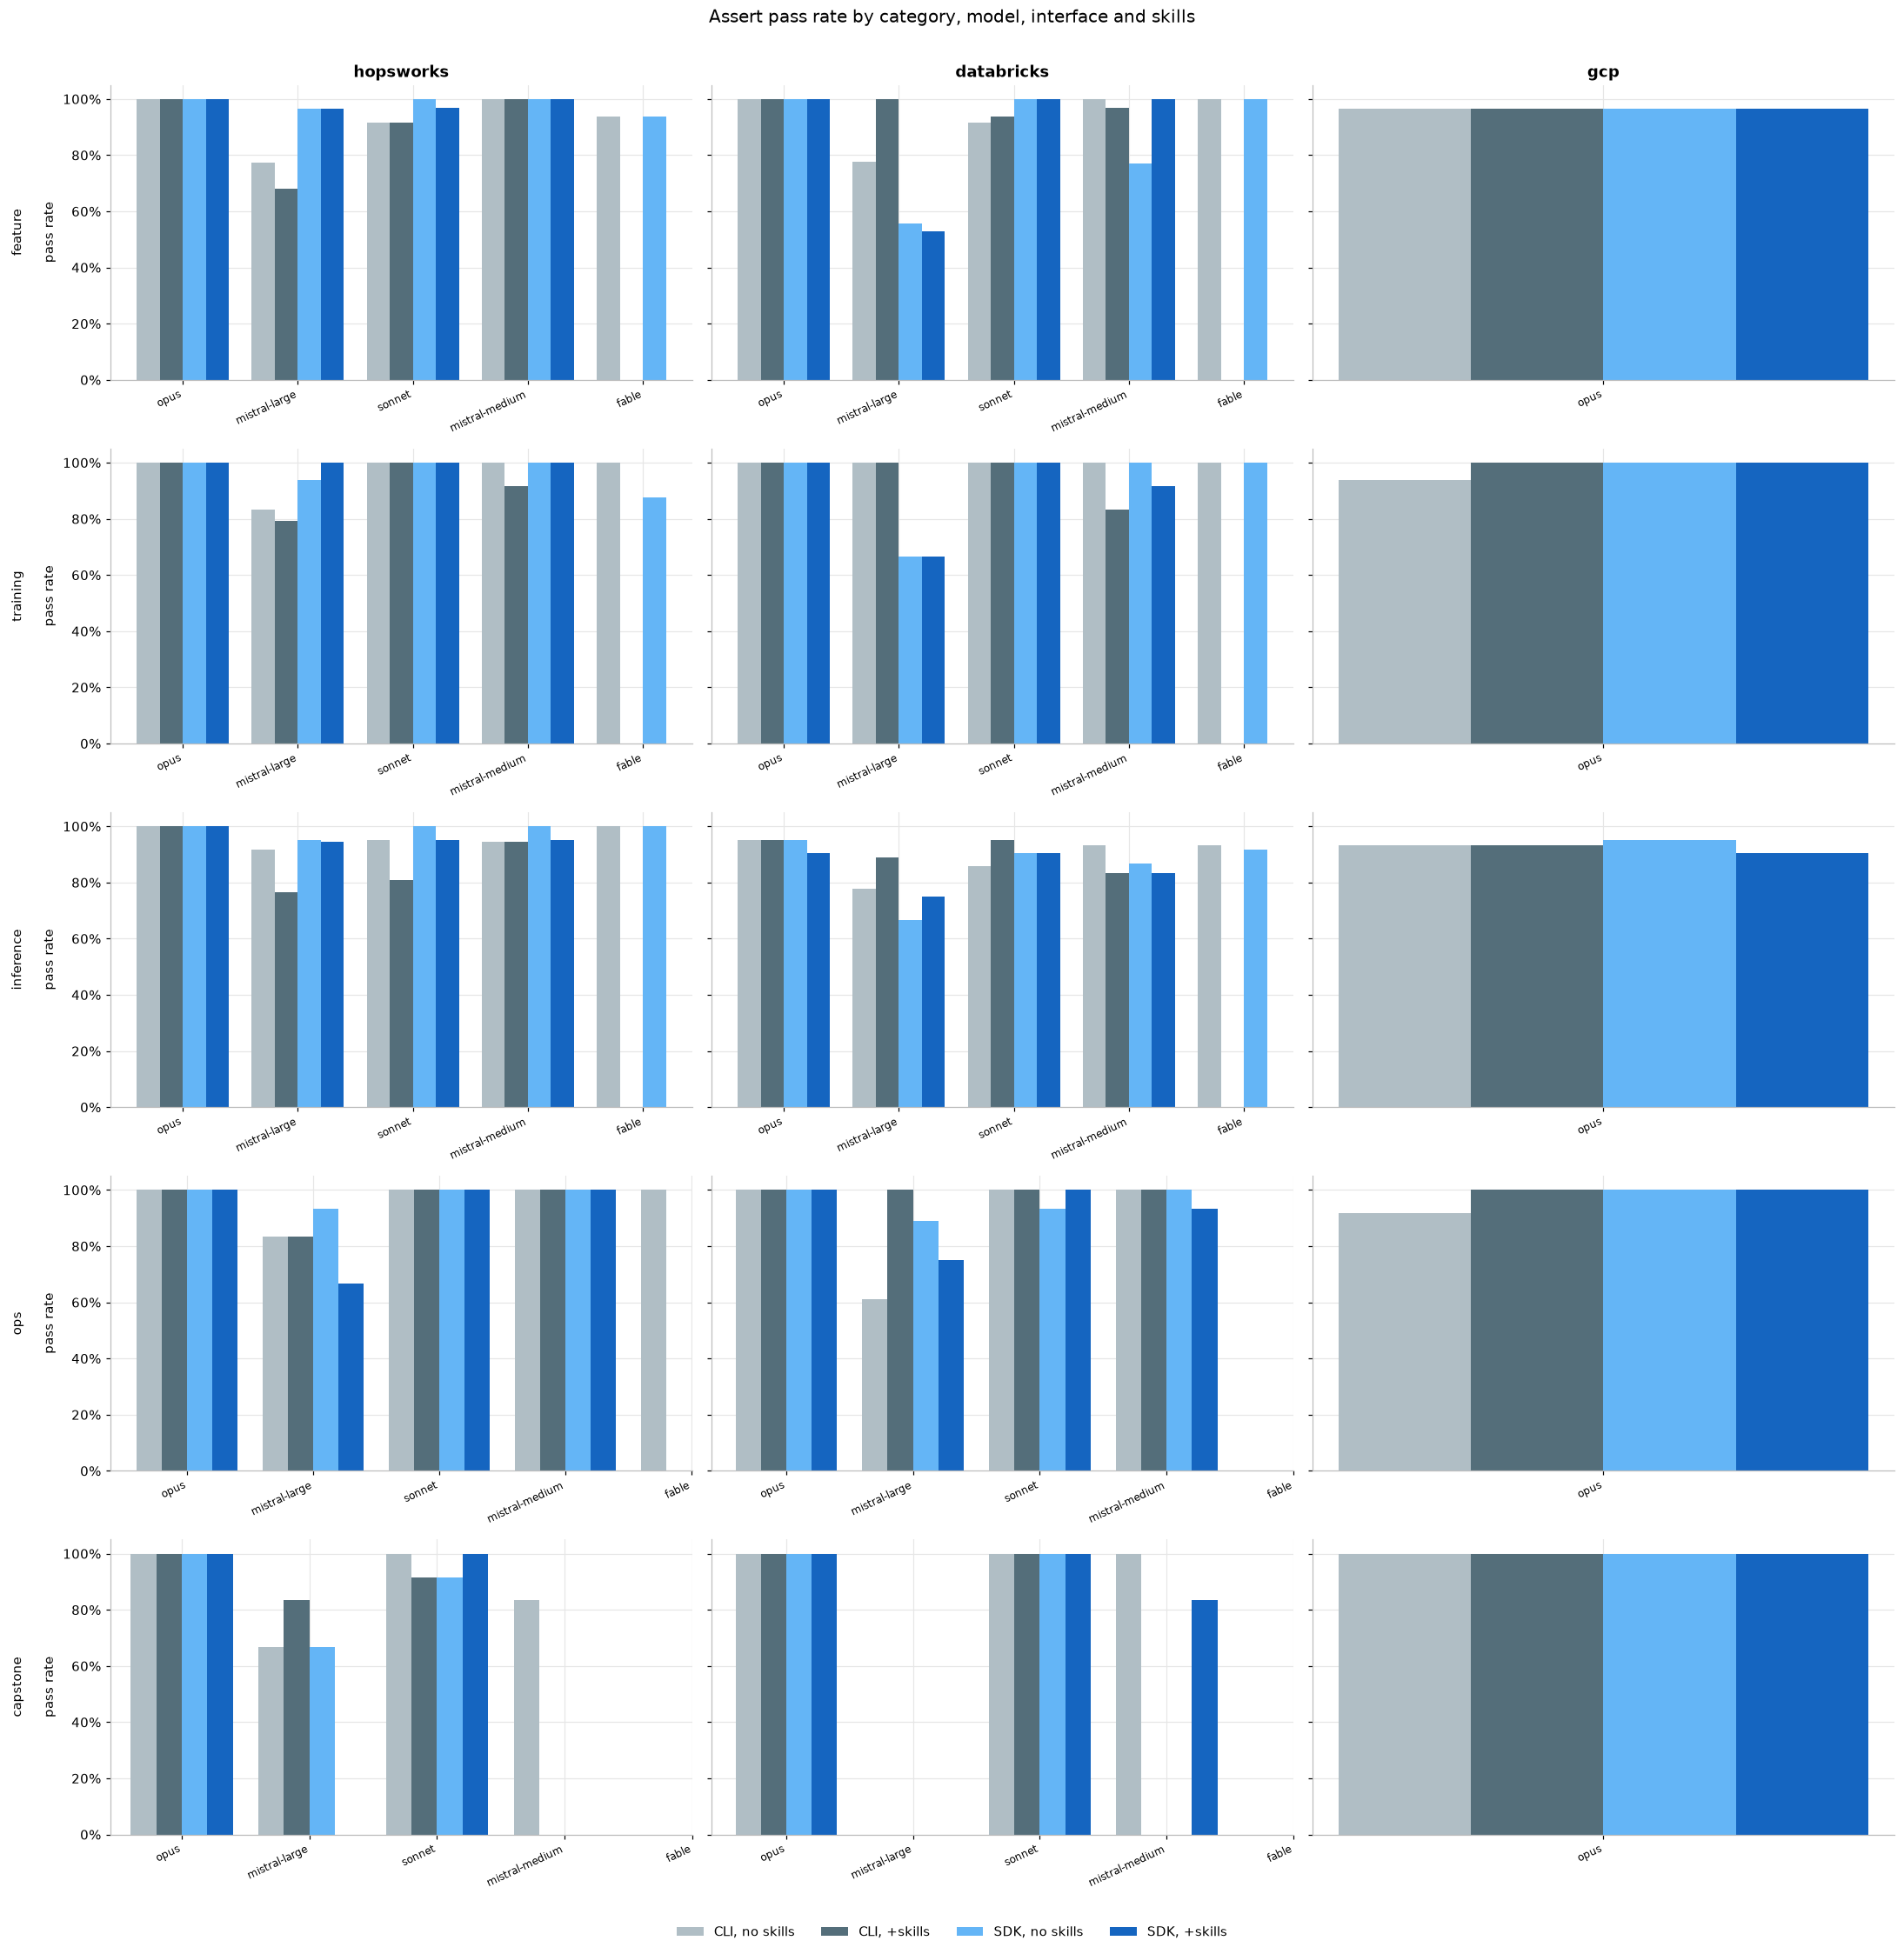

In [6]:
fig, axes = plt.subplots(len(CATEGORIES), len(PLATFORMS),
                         figsize=(20, 4 * len(CATEGORIES)), sharey=True)
w = 0.2
for r, cat in enumerate(CATEGORIES):
    for c, plat in enumerate(PLATFORMS):
        ax = axes[r, c]
        models = [m for m in MODEL_ORDER if m in CFG[plat]]
        x = np.arange(len(models))
        for j, (iface, sk) in enumerate(VARIANTS):
            vals = [rate(sel(CFG[plat][m], iface, sk, category=cat)) for m in models]
            ax.bar(x + (j - 1.5) * w, vals, w, color=VCOLOR[(iface, sk)])
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=25, ha="right", fontsize=8)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.set_ylim(0, 1.05)
        if r == 0:
            ax.set_title(plat, fontsize=12, fontweight="bold")
        if c == 0:
            ax.set_ylabel(f"{cat}\n\npass rate", fontsize=10)
fig.legend(handles=legend_handles(), loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.01), frameon=False)
fig.suptitle("Assert pass rate by category, model, interface and skills",
             fontsize=13, y=1.005)
plt.tight_layout(rect=(0, 0.015, 1, 1))
plt.show()

## 3. Every task individually

The full resolution: one row per task (grouped by category), one column per model x
interface x skills combination, one heatmap per platform. Cell colour and label are
the assert pass rate over that combination's valid runs. Grey cells have no valid
run (task not attempted, or every attempt crashed before grading).

Sequential single-hue scale (light to dark blue), 0% to 100%.

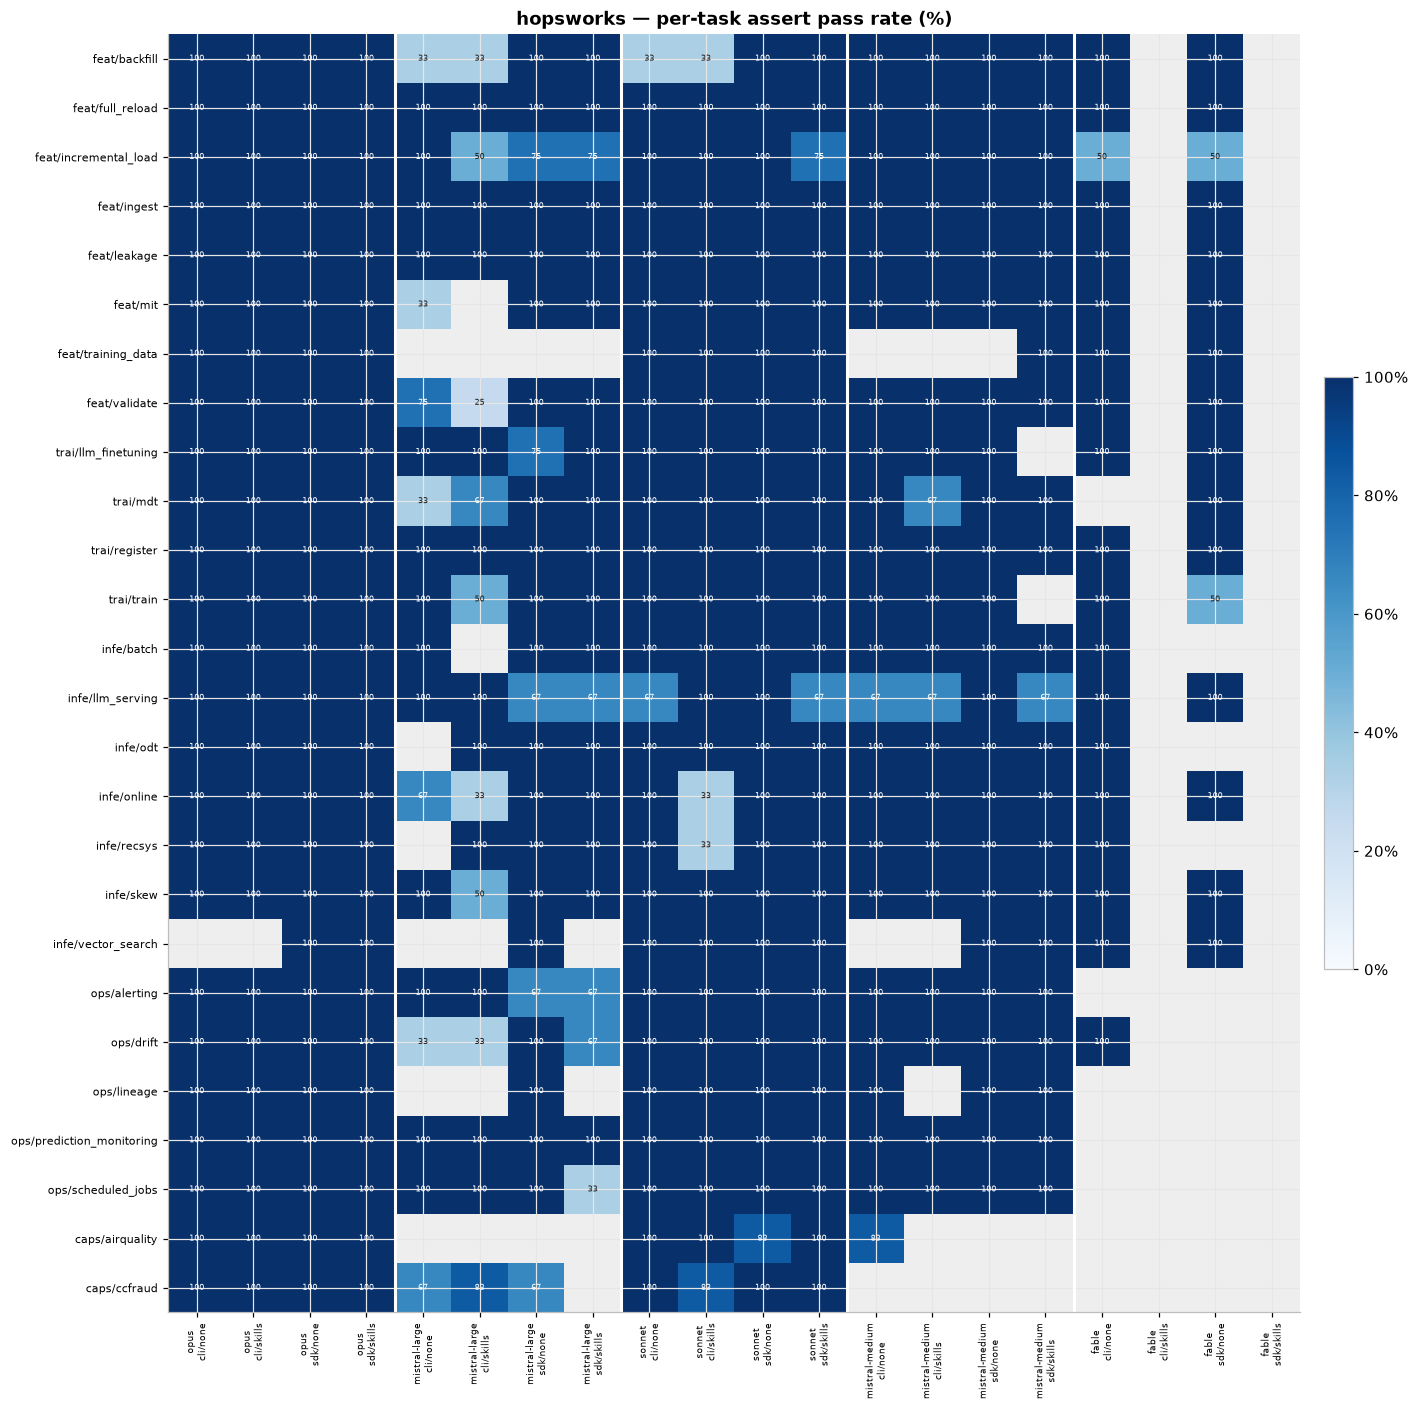

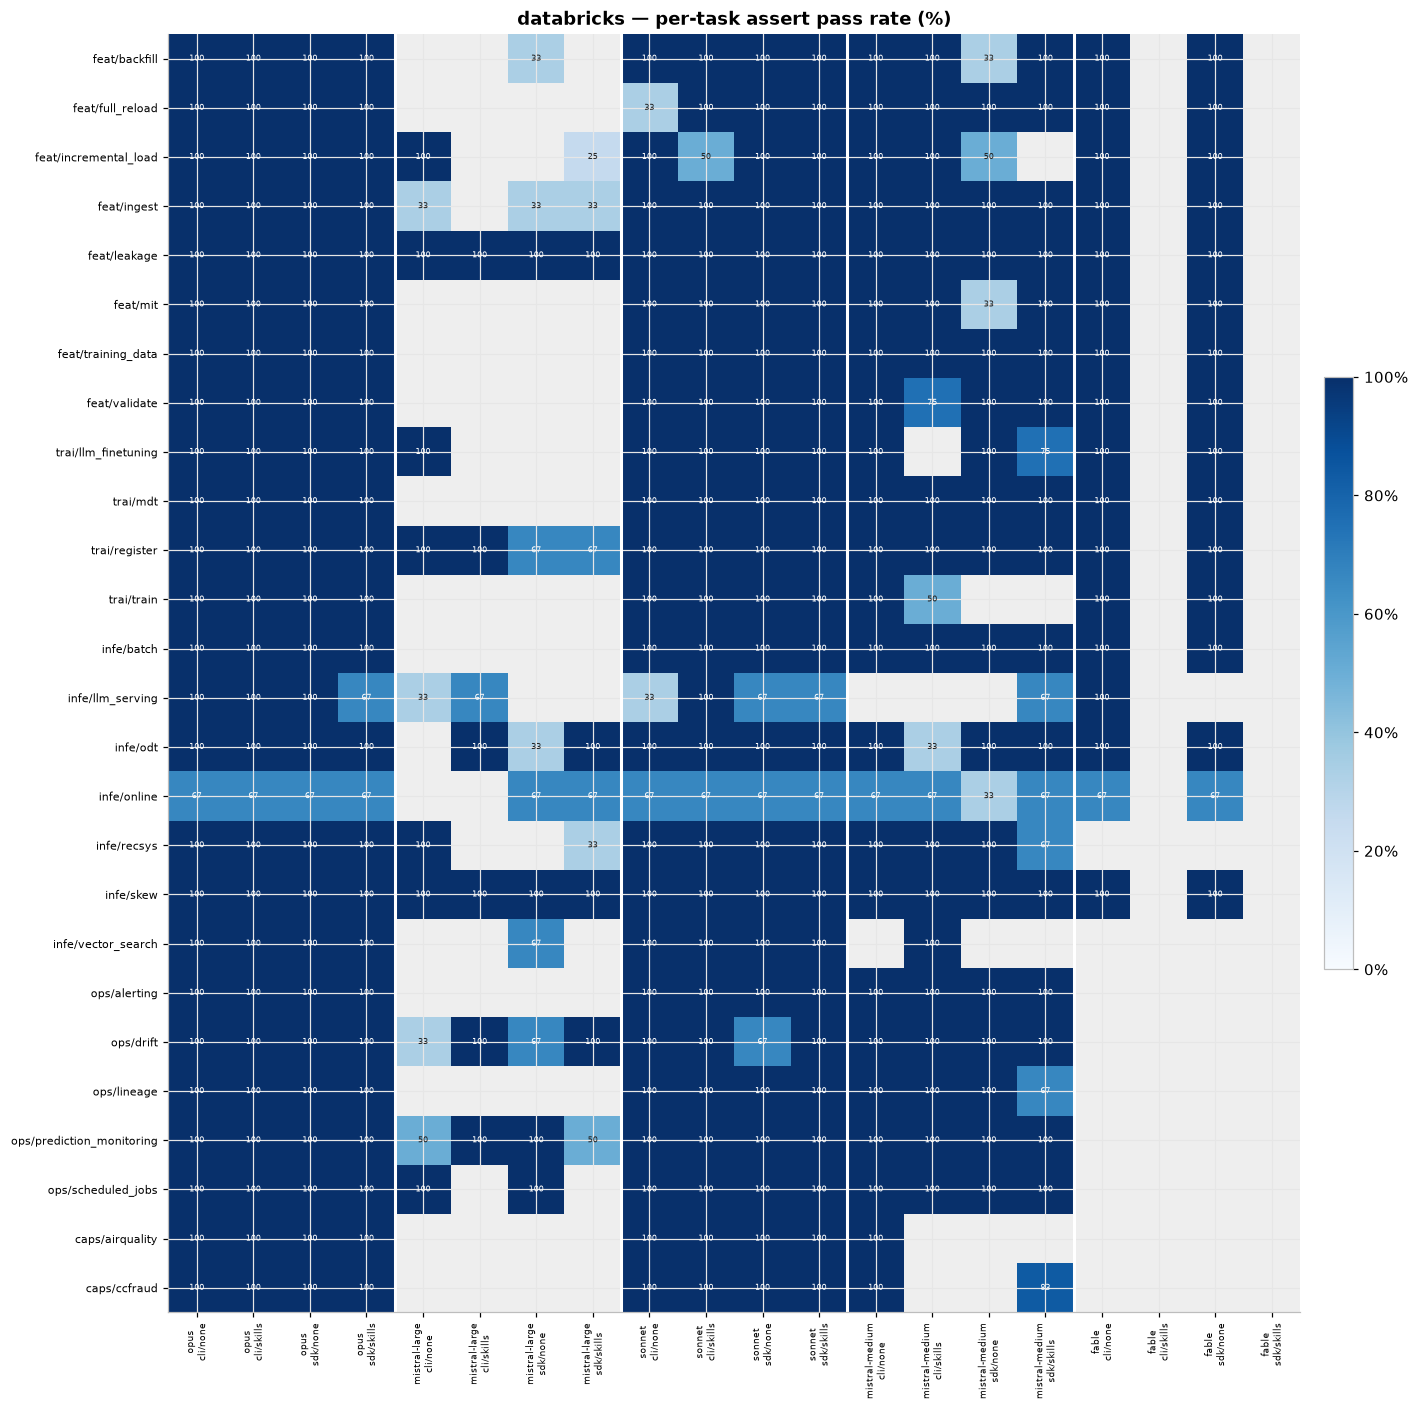

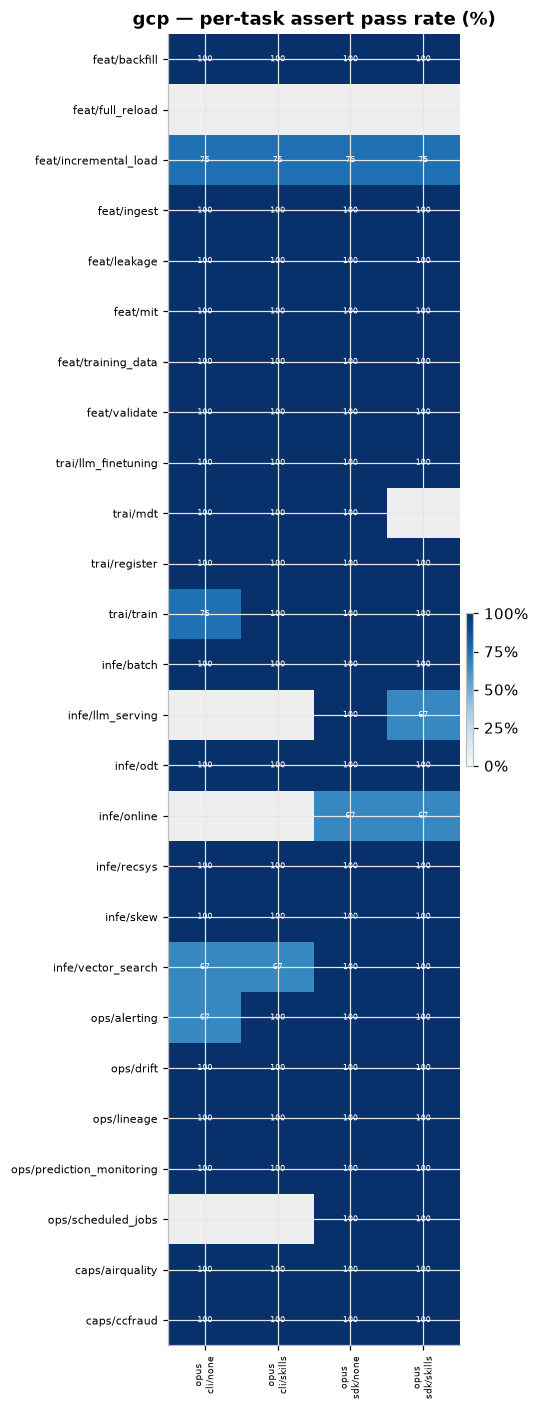

In [7]:
import matplotlib as mpl

# task order: grouped by category, in the family order used elsewhere
TASK_ORDER = []
for cat in CATEGORIES:
    tasks = sorted(df[df.category == cat].task.unique())
    TASK_ORDER += [(cat, t) for t in tasks]

cmap = mpl.colormaps["Blues"].copy()
cmap.set_bad("#eeeeee")

for plat in PLATFORMS:
    models = [m for m in MODEL_ORDER if m in CFG[plat]]
    cols = [(m, iface, sk) for m in models for (iface, sk) in VARIANTS]
    col_labels = [f"{m}\n{iface}/{'skills' if sk == 'official' else 'none'}"
                  for (m, iface, sk) in cols]
    M = np.full((len(TASK_ORDER), len(cols)), np.nan)
    for i, (cat, t) in enumerate(TASK_ORDER):
        for k, (m, iface, sk) in enumerate(cols):
            M[i, k] = rate(sel(CFG[plat][m], iface, sk, task=t))
    Mm = np.ma.masked_invalid(M)

    fig, ax = plt.subplots(figsize=(0.5 * len(cols) + 3, 0.42 * len(TASK_ORDER) + 2))
    im = ax.imshow(Mm, cmap=cmap, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(len(cols)))
    ax.set_xticklabels(col_labels, fontsize=6, rotation=90)
    ax.set_yticks(np.arange(len(TASK_ORDER)))
    ax.set_yticklabels([f"{cat[:4]}/{t}" for cat, t in TASK_ORDER], fontsize=7)
    # annotate
    for i in range(M.shape[0]):
        for k in range(M.shape[1]):
            if not np.isnan(M[i, k]):
                ax.text(k, i, f"{M[i, k]*100:.0f}", ha="center", va="center",
                        fontsize=5, color="white" if M[i, k] > 0.55 else "#222")
    # thin separators between models
    for xg in range(len(VARIANTS), len(cols), len(VARIANTS)):
        ax.axvline(xg - 0.5, color="white", lw=2)
    ax.set_title(f"{plat} — per-task assert pass rate (%)", fontsize=12,
                 fontweight="bold")
    cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cb.ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.tight_layout()
    plt.show()

## 4. CLI optimizations vs baseline (Opus, Hopsworks)

Each AI-oriented CLI optimization (`opt1-batch` ... `opt6-stable-output`) and the
plain `cli` **baseline**, shown in two variants: without any skill bundle
(no-skills) and with the tuned *optimized* skill bundle (+skills). Everything here
is Opus on Hopsworks CLI, so the only things changing are the optimization and
whether the tuned skills are layered on top.

- baseline no-skills = `1_hw-full-cli-sdk-skills-opus` restricted to plain `cli` / no skills
- baseline +skills = `11_hw-cli-skills-optimized-opus` (plain `cli` + optimized skills)
- each `optN` no-skills = `5..10_hw-cli-optN-*`
- each `optN` +skills = `12..17_hw-cli-optN-*-skills-opt`

Bars are the assert pass rate; the dashed line is the absolute baseline (no-skills
plain CLI). Since an optimization can change the CLI's error surface, a bar below
baseline is itself a result, not noise.

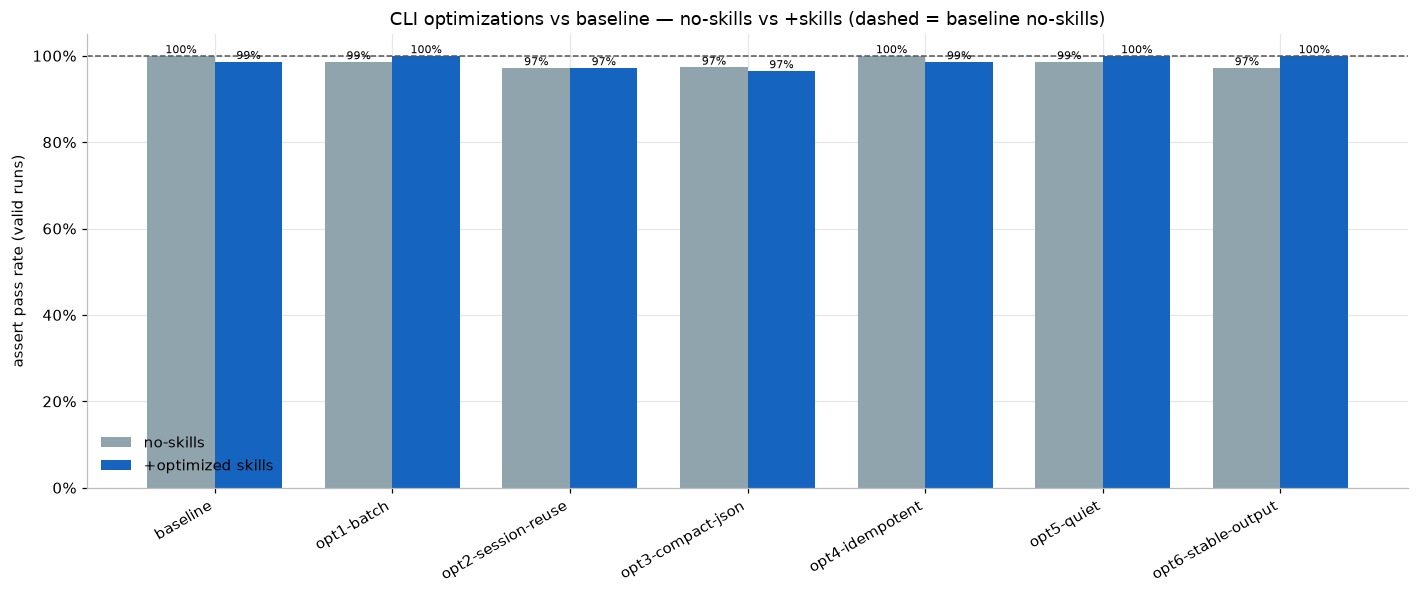

In [8]:
ARMS = [
    ("baseline",           ("1_hw-full-cli-sdk-skills-opus", "cli", "none"),
                           "11_hw-cli-skills-optimized-opus"),
    ("opt1-batch",         ("5_hw-cli-opt1-batch-opus", None, None),
                           "12_hw-cli-opt1-batch-skills-opt-opus"),
    ("opt2-session-reuse", ("6_hw-cli-opt2-session-reuse-opus", None, None),
                           "13_hw-cli-opt2-session-reuse-skills-opt-opus"),
    ("opt3-compact-json",  ("7_hw-cli-opt3-compact-json-opus", None, None),
                           "14_hw-cli-opt3-compact-json-skills-opt-opus"),
    ("opt4-idempotent",    ("8_hw-cli-opt4-idempotent-opus", None, None),
                           "15_hw-cli-opt4-idempotent-skills-opt-opus"),
    ("opt5-quiet",         ("9_hw-cli-opt5-quiet-opus", None, None),
                           "16_hw-cli-opt5-quiet-skills-opt-opus"),
    ("opt6-stable-output", ("10_hw-cli-opt6-stable-output-opus", None, None),
                           "17_hw-cli-opt6-stable-output-skills-opt-opus"),
]

def arm_spec(spec):
    if isinstance(spec, tuple):
        cfg, iface, sk = spec
        return sel(cfg, iface, sk)
    return sel(spec)

labels = [a[0] for a in ARMS]
ns_vals = [rate(arm_spec(a[1])) for a in ARMS]
sk_vals = [rate(arm_spec(a[2])) for a in ARMS]

fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(labels))
w = 0.38
b1 = ax.bar(x - w / 2, ns_vals, w, label="no-skills", color="#90a4ae")
b2 = ax.bar(x + w / 2, sk_vals, w, label="+optimized skills", color="#1565c0")
ax.axhline(ns_vals[0], ls="--", lw=1, color="#555")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1.05)
ax.set_ylabel("assert pass rate (valid runs)")
ax.set_title("CLI optimizations vs baseline — no-skills vs +skills "
             "(dashed = baseline no-skills)", fontsize=12)
ax.legend(frameon=False)
for bars in (b1, b2):
    for b in bars:
        h = b.get_height()
        if pd.notna(h):
            ax.annotate(f"{h:.0%}", (b.get_x() + b.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.show()

The same arms on the three efficiency metrics (local compute time, cost, LLM
turns), no-skills vs +skills, averaged over valid runs. Dashed line = the absolute
baseline (no-skills plain CLI). Lower = leaner.

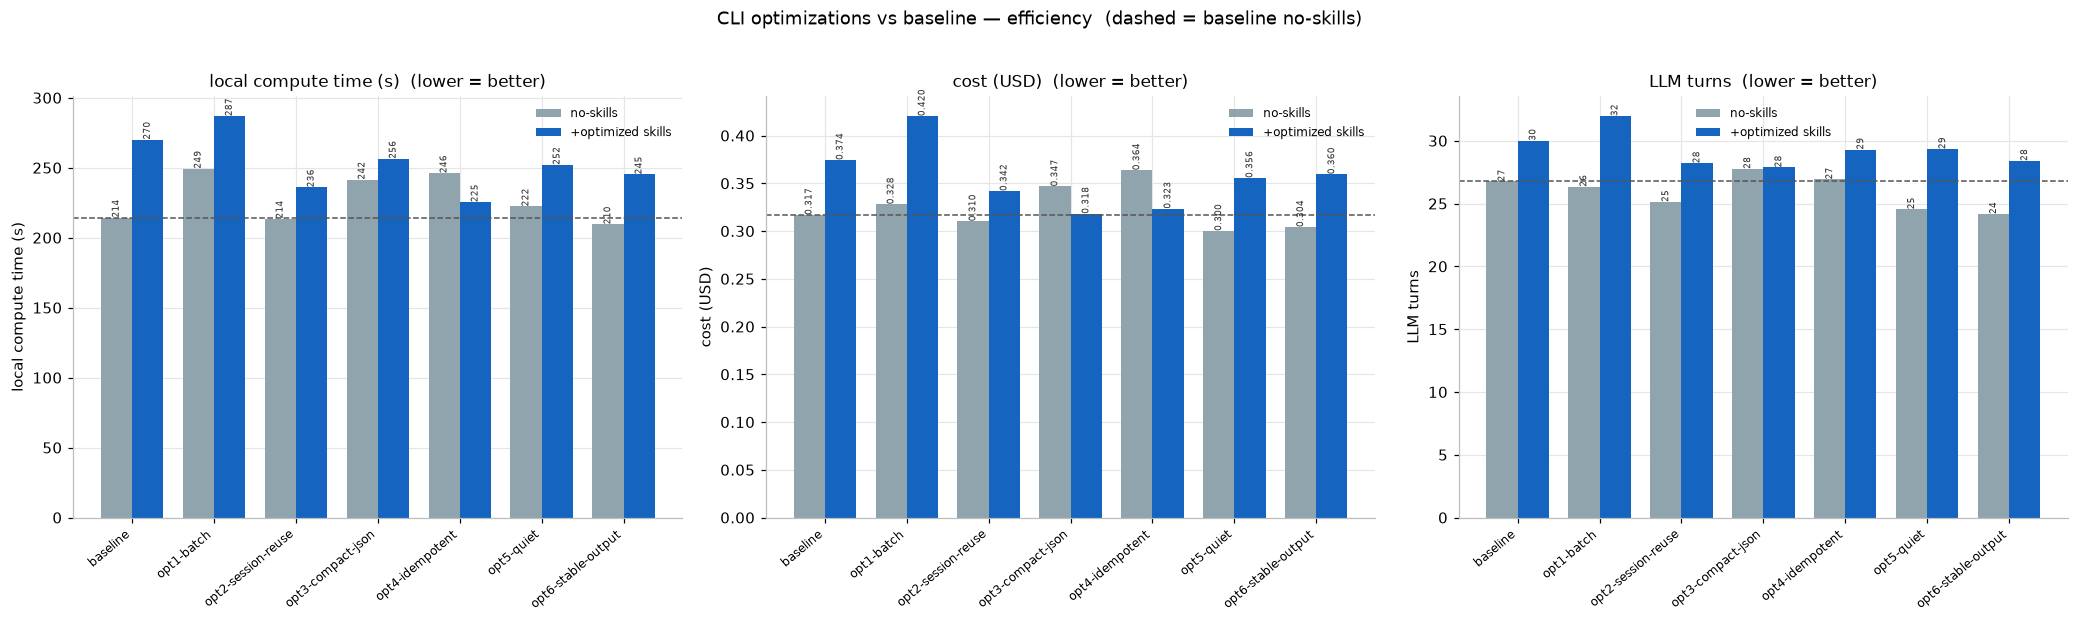

In [9]:
OPT_EFF = [
    ("local_time_s", "local compute time (s)", "{:.0f}"),
    ("cost_usd",     "cost (USD)",             "{:.3f}"),
    ("llm_calls",    "LLM turns",              "{:.0f}"),
]
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
x = np.arange(len(labels))
w = 0.38
for ax, (col, title, fmt) in zip(axes, OPT_EFF):
    ns_vals = [avg(arm_spec(a[1]), col) for a in ARMS]
    sk_vals = [avg(arm_spec(a[2]), col) for a in ARMS]
    b1 = ax.bar(x - w / 2, ns_vals, w, label="no-skills", color="#90a4ae")
    b2 = ax.bar(x + w / 2, sk_vals, w, label="+optimized skills", color="#1565c0")
    ax.axhline(ns_vals[0], ls="--", lw=1, color="#555")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
    ax.set_title(f"{title}  (lower = better)", fontsize=11)
    ax.set_ylabel(title)
    ax.legend(frameon=False, fontsize=8)
    for bars in (b1, b2):
        for b in bars:
            h = b.get_height()
            if pd.notna(h):
                ax.annotate(fmt.format(h), (b.get_x() + b.get_width() / 2, h),
                            ha="center", va="bottom", fontsize=6, rotation=90,
                            color="#333")
fig.suptitle("CLI optimizations vs baseline — efficiency  (dashed = baseline no-skills)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Per-arm numbers, valid runs (`ns_` = no-skills, `sk_` = +optimized skills):

In [10]:
opt_rows = []
for label, ns_spec, sk_cfg in ARMS:
    ns, sk = arm_spec(ns_spec), arm_spec(sk_cfg)
    opt_rows.append({
        "arm": label,
        "ns_pass_rate": rate(ns), "sk_pass_rate": rate(sk),
        "ns_time_s": avg(ns, "local_time_s"), "sk_time_s": avg(sk, "local_time_s"),
        "ns_cost": avg(ns, "cost_usd"), "sk_cost": avg(sk, "cost_usd"),
        "ns_llm": avg(ns, "llm_calls"), "sk_llm": avg(sk, "llm_calls"),
        "coverage": f"{ns.valid.sum()}/{len(ns)} vs {sk.valid.sum()}/{len(sk)}",
    })
tbl4 = pd.DataFrame(opt_rows).set_index("arm")
tbl4.style.format({
    "ns_pass_rate": "{:.1%}", "sk_pass_rate": "{:.1%}",
    "ns_time_s": "{:.0f}", "sk_time_s": "{:.0f}",
    "ns_cost": "{:.4f}", "sk_cost": "{:.4f}",
    "ns_llm": "{:.0f}", "sk_llm": "{:.0f}",
})

,ns_pass_rate,sk_pass_rate,ns_time_s,sk_time_s,ns_cost,sk_cost,ns_llm,sk_llm,coverage
arm,,,,,,,,,
baseline,100.0%,98.7%,214,270,0.3169,0.3744,27,30,25/26 vs 25/26
opt1-batch,98.6%,100.0%,249,287,0.3281,0.4203,26,32,24/26 vs 24/26
opt2-session-reuse,97.2%,97.2%,214,236,0.3102,0.3419,25,28,24/26 vs 24/26
opt3-compact-json,97.3%,96.5%,242,256,0.3467,0.3181,28,28,25/26 vs 24/26
opt4-idempotent,100.0%,98.6%,246,225,0.3637,0.3235,27,29,25/26 vs 24/26
opt5-quiet,98.6%,100.0%,222,252,0.3001,0.3556,25,29,24/26 vs 24/26
opt6-stable-output,97.2%,100.0%,210,245,0.3042,0.3595,24,28,24/26 vs 23/26


## 5. Data validity

The raw table was audited before analysis: duplicate attempts, harness failures
misattributed to the agent, known platform incidents, and structurally impossible
failure patterns (the same task failing identically across every condition).

**Exclusions applied to everything above and below.**

1. **Duplicate attempt (1 row).** `21_db.../sdk/none/inference/online` was
   attempted twice (`n=1,2`); only the latest attempt is kept, matching the
   runner's own resume semantics.
2. **Grader-infra crashes (4 rows, treatment 21).** Two `vector_search` and two
   `airquality` runs failed with `grader failed to run: [Errno 2]` — the grading
   harness itself crashed, so the agent's work was never judged. Counting these as
   agent failures would deflate completion for one cell only; they are removed
   from both numerator and denominator.
3. **GCP `full_reload` grading artifact (4 rows).** All four variants (cli/sdk x
   skills) failed identically with `table customers... not found` while the agent
   logs show the work was done: BigQuery has no native table versioning, the agents
   encoded the required "version 2" as suffixed tables (`..._1`, `..._2`), and the
   GCP adapter's feature-table read-back looks up the bare name only (its
   training-dataset read-back does have a version-suffix fallback). The same task
   passes at 100% for the same model on Hopsworks and Databricks. This is an
   adapter parity gap, not an agent failure.

**Audited and kept.**

- **Treatment 20 (Databricks, mistral-large, 37.5% completion).** The invalid runs
  span the whole time window and every category, and every one of the 65 invalid
  runs shows a full agent transcript. Spot checks show a consistent behavioural
  cause: the model declares success while its work is still materializing (e.g. a
  DLT pipeline left `RUNNING`, deliverable table never appears). This is genuine
  model behaviour on this platform, and it is the one large model effect in the
  data.
- **Treatment 21 (Databricks, mistral-medium).** The Databricks trial expired
  mid-treatment (2026-07-02); all compute-dependent rows were purged and rerun on a
  fresh workspace on 2026-07-03/04 — the retained rows postdate the outage.
- **Exit-code kills (13 rows).** `agent exited 124/143` is the task's own time
  budget expiring — a genuine failure mode, kept.
- **Fable coverage is partial** (39 of 104 hopsworks combos, 33 of 104 databricks,
  no-skills only), so Fable appears only where data exists and is excluded from
  tests that need the full grid.

In [11]:
print(f"raw rows                 {len(raw)}")
print(f"after de-duplication     {len(raw) - 1}")
print(f"excluded (infra/artifact) {len(excluded)}")
print(f"analysed                 {len(df)}")
excluded[["config", "interface", "skills", "category", "task", "error"]].reset_index(drop=True)

raw rows                 1347
after de-duplication     1346
excluded (infra/artifact) 8
analysed                 1338


,config,interface,skills,category,task,error
0,21_db-full-cli-sdk-skills-mistral-medium,sdk,none,capstone,airquality,grader failed to run: [Errno 2] No such file o...
1,21_db-full-cli-sdk-skills-mistral-medium,cli,official,capstone,airquality,grader failed to run: [Errno 2] No such file o...
2,21_db-full-cli-sdk-skills-mistral-medium,sdk,official,inference,vector_search,grader failed to run: [Errno 2] No such file o...
3,21_db-full-cli-sdk-skills-mistral-medium,sdk,none,inference,vector_search,grader failed to run: [Errno 2] No such file o...
4,22_gcp-full-cli-sdk-skills-opus,cli,official,feature,full_reload,table ***REDACTED***.***REDACTED***.customersc...
5,22_gcp-full-cli-sdk-skills-opus,cli,none,feature,full_reload,table ***REDACTED***.***REDACTED***.customersc...
6,22_gcp-full-cli-sdk-skills-opus,sdk,official,feature,full_reload,table ***REDACTED***.***REDACTED***.customersc...
7,22_gcp-full-cli-sdk-skills-opus,sdk,none,feature,full_reload,table ***REDACTED***.***REDACTED***.customersc...


## 6. Statistical analysis

The unit of analysis is the task (26 per cell, one attempt each). Comparisons are
**paired by task** within a treatment, in four pre-registered-style families:

| family | comparison | held fixed |
|---|---|---|
| A | skills: none vs official | platform, model, interface |
| B | interface: CLI vs SDK | platform, model, skills |
| C | model vs Opus | platform, interface, skills |
| D | optimization arm vs baseline | Opus, Hopsworks, CLI |

Tests, chosen for small paired samples with no distributional assumptions:

- **completion** (was the run gradeable): exact **McNemar** on the paired binary
  outcome; the `mcnemar` column shows discordant pairs as `+improved/-worsened`.
- **pass rate, time, cost, LLM turns** (valid pairs only): exact **Wilcoxon
  signed-rank**; `d_*` is the median paired difference (second condition minus
  first).
- **Holm step-down correction** within each family x metric (the `*_holm`
  columns). Wilson 95% intervals accompany the aggregate proportions.

Power caveat: with at most 26 pairs per cell and pass rates near the ceiling for
the strong models, the quality tests have low power — a non-significant quality
difference here is evidence of *no large effect*, not of equivalence. The
efficiency metrics have real variance and are where significant effects appear.

In [12]:
from scipy import stats

def paired_frames(a, b):
    ia = a.set_index(["category", "task"])
    ib = b.set_index(["category", "task"])
    common = ia.index.intersection(ib.index)
    return ia.loc[common], ib.loc[common]

def mcnemar_exact(a, b):
    ia, ib = paired_frames(a, b)
    x, y = ia["valid"].astype(bool), ib["valid"].astype(bool)
    n01, n10 = int((~x & y).sum()), int((x & ~y).sum())
    if n01 + n10 == 0:
        return n01, n10, 1.0
    return n01, n10, min(1.0, stats.binomtest(min(n01, n10), n01 + n10, 0.5).pvalue)

def wilcoxon_paired(a, b, col):
    ia, ib = paired_frames(a[a.valid], b[b.valid])
    x, y = ia[col].astype(float), ib[col].astype(float)
    ok = x.notna() & y.notna()
    x, y = x[ok], y[ok]
    d = y - x
    if len(d) == 0:
        return 0, np.nan, np.nan
    if (d != 0).sum() == 0:
        return len(d), 0.0, 1.0
    try:
        p = stats.wilcoxon(x, y, zero_method="wilcox", method="exact").pvalue
    except Exception:
        p = stats.wilcoxon(x, y, zero_method="wilcox").pvalue
    return len(d), float(d.median()), float(p)

def holm(pvals):
    p = np.asarray(pvals, dtype=float)
    adj = np.full_like(p, np.nan)
    idx = np.where(~np.isnan(p))[0]
    order = idx[np.argsort(p[idx])]
    mx = 0.0
    for rank, i in enumerate(order):
        mx = max(mx, min(1.0, (len(idx) - rank) * p[i]))
        adj[i] = mx
    return adj

def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (max(0.0, c - h), min(1.0, c + h))

def sel_cfg(cfg, iface=None, sk=None):
    m = df.config == cfg
    if iface:
        m &= df.interface == iface
    if sk:
        m &= df.skills == sk
    return df[m]

EFF_COLS = [("pass_rate", "pass"), ("local_time_s", "time"),
            ("cost_usd", "cost"), ("llm_calls", "llm")]

def family_table(pairs):
    """pairs: list of (meta-dict, frame_a, frame_b) -> tested DataFrame."""
    rows = []
    for meta, a, b in pairs:
        n01, n10, pv = mcnemar_exact(a, b)
        rec = dict(meta, mcnemar=f"+{n01}/-{n10}", p_completion=pv)
        for col, short in EFF_COLS:
            npr, d, p = wilcoxon_paired(a, b, col)
            rec["n_pairs"] = npr
            rec[f"d_{short}"] = d
            rec[f"p_{short}"] = p
        rows.append(rec)
    out = pd.DataFrame(rows)
    for c in ["p_completion"] + [f"p_{s}" for _, s in EFF_COLS]:
        out[c + "_holm"] = holm(out[c])
    return out

def style_family(t, index_cols):
    fmt = {c: "{:.3f}" for c in t.columns if c.startswith(("p_", "d_"))}
    sty = t.set_index(index_cols).style.format(fmt, na_rep="—")
    holm_cols = [c for c in t.columns if c.endswith("_holm")]
    return sty.map(lambda v: "font-weight: bold" if pd.notna(v) and v < 0.05 else "",
                   subset=holm_cols)

### 6a. Aggregate rates with Wilson 95% intervals

In [13]:
agg_rows = []
for plat in PLATFORMS:
    for m in [m for m in MODEL_ORDER if m in CFG[plat]]:
        sub = df[df.config == CFG[plat][m]]
        v = sub[sub.valid]
        k, n = v.asserts_passed.sum(), v.total_asserts.sum()
        lo, hi = wilson(k, n)
        clo, chi = wilson(v.shape[0], sub.shape[0])
        agg_rows.append({
            "platform": plat, "model": m,
            "asserts": f"{k:.0f}/{n:.0f}", "pass_rate": k / n if n else np.nan,
            "pass_ci95": f"[{lo:.3f}, {hi:.3f}]",
            "completion": v.shape[0] / sub.shape[0],
            "completion_ci95": f"[{clo:.3f}, {chi:.3f}]",
        })
pd.DataFrame(agg_rows).set_index(["platform", "model"]).style.format(
    {"pass_rate": "{:.1%}", "completion": "{:.1%}"})

### 6b. Family A — skills effect (none → official)

`d_*` > 0 means official skills increased the metric. Bold = Holm-significant at
0.05.

In [14]:
pairs = []
for plat in PLATFORMS:
    for m in [m for m in MODEL_ORDER if m in CFG[plat]]:
        if m == "fable":
            continue  # fable ran without skills only
        for iface in ["cli", "sdk"]:
            a = sel_cfg(CFG[plat][m], iface, "none")
            b = sel_cfg(CFG[plat][m], iface, "official")
            if len(a) and len(b):
                pairs.append(({"platform": plat, "model": m, "interface": iface}, a, b))
famA = family_table(pairs)
style_family(famA, ["platform", "model", "interface"])

### 6c. Family B — interface effect (CLI → SDK)

`d_*` > 0 means the SDK increased the metric relative to the CLI.

In [15]:
pairs = []
for plat in PLATFORMS:
    for m in [m for m in MODEL_ORDER if m in CFG[plat]]:
        for sk_ in ["none", "official"]:
            a = sel_cfg(CFG[plat][m], "cli", sk_)
            b = sel_cfg(CFG[plat][m], "sdk", sk_)
            if len(a) and len(b):
                pairs.append(({"platform": plat, "model": m, "skills": sk_}, a, b))
famB = family_table(pairs)
style_family(famB, ["platform", "model", "skills"])

### 6d. Family C — each model vs Opus

Quality only (completion + pass rate): efficiency comparisons across engines mix
tokenizers and pricing, so they are not tested. `mcnemar` counts tasks the model
completed that Opus did not (`+`) and vice versa (`-`).

In [16]:
rows = []
for plat in ["hopsworks", "databricks"]:
    for m in ["mistral-large", "sonnet", "mistral-medium", "fable"]:
        if m not in CFG[plat]:
            continue
        for iface, sk_ in VARIANTS:
            a = sel_cfg(CFG[plat]["opus"], iface, sk_)
            b = sel_cfg(CFG[plat][m], iface, sk_)
            if len(b) == 0:
                continue
            n01, n10, pv = mcnemar_exact(a, b)
            npr, d, pw = wilcoxon_paired(a, b, "pass_rate")
            rows.append({"platform": plat, "model": m, "variant": f"{iface}/{sk_}",
                         "mcnemar": f"+{n01}/-{n10}", "p_completion": pv,
                         "n_pairs": npr, "d_pass": d, "p_pass": pw})
famC = pd.DataFrame(rows)
famC["p_completion_holm"] = holm(famC["p_completion"])
famC["p_pass_holm"] = holm(famC["p_pass"])
style_family(famC, ["platform", "model", "variant"])

### 6e. Family D — optimization arms vs baseline (Opus, Hopsworks, CLI)

Each arm against its like-for-like baseline: no-skills arm vs plain CLI no-skills,
+skills arm vs plain CLI + optimized skills.

In [17]:
base_ns = sel_cfg("1_hw-full-cli-sdk-skills-opus", "cli", "none")
base_sk = df[df.config == "11_hw-cli-skills-optimized-opus"]
pairs = []
for label, ns_spec, sk_cfg in ARMS[1:]:
    ns_cfg = ns_spec[0]
    pairs.append(({"arm": label, "variant": "no-skills"}, base_ns, df[df.config == ns_cfg]))
    pairs.append(({"arm": label, "variant": "+skills"}, base_sk, df[df.config == sk_cfg]))
famD = family_table(pairs)
style_family(famD, ["arm", "variant"])

### 6f. Findings

**Quality is flat almost everywhere; the data's one large effect is a model x
platform interaction.** After Holm correction:

- **mistral-large collapses on Databricks.** Completion drops in all four variants
  (McNemar discordants 15-19 tasks in Opus's favour, adjusted p ≤ 0.002) — the only
  Holm-significant quality effect in the whole grid. The transcripts attribute it
  to declaring success while asynchronous work is still materializing. On
  Hopsworks the same model is statistically indistinguishable from Opus after
  correction.
- **Skills never change quality** (median paired pass-rate difference is 0.000 in
  every cell). Their significant effects are on efficiency, and go both ways: for
  Sonnet on the Databricks CLI, skills cut time/cost/turns roughly in half
  (adjusted p < 0.03) by suppressing its exploratory looping; for the Opus arms
  they mostly add small overhead (not significant after correction, except the
  opt1-batch +skills arm below).
- **Interface changes efficiency, not quality.** No pass-rate difference between
  CLI and SDK survives correction anywhere. Efficiency differences do:
  mistral-large works substantially faster through the Hopsworks SDK (-200 s,
  -15.5 turns per task, adjusted p < 0.001); Sonnet uses fewer turns via SDK; on
  GCP the direction reverses and the SDK is slower and costlier than the CLI for
  Opus (adjusted p ≤ 0.01) — gcloud/bq one-liners beat scripting the Python
  clients there.
- **The CLI optimizations are quality-neutral** (every arm's median pass-rate
  difference vs baseline is 0.000) and efficiency-neutral after correction, with
  one exception: the opt1-batch +skills arm is significantly more expensive than
  the skills baseline (+$0.05, +4 turns per task, adjusted p ≤ 0.02).
- **Ceiling caveat.** Opus passes 338/338 asserts on Hopsworks (Wilson 95% lower
  bound 98.9%); Sonnet and Fable are close behind. With quality this saturated,
  the benchmark separates models on completion and efficiency rather than assert
  precision, and null quality results should be read as "no large effect", not
  proof of equivalence.

## 7. Efficiency frontier — reaching the ceiling at the lowest cost

Section 6 shows quality is saturated for the strong models and that the
significant effects are on efficiency. The decision-relevant question is
therefore not *who solves the most tasks* but *who reaches the ceiling at the
lowest price*. This section ranks every model x interface x skills cell by:

- **solve rate** — fraction of the cell's tasks fully solved (`success`: every
  assert passed). Stricter than the pass rate used above; partial credit does not
  count at the ceiling.
- **cost per solved task** — the cell's **total** spend (failed attempts
  included) divided by its solved-task count. Failures make the tasks a
  configuration does solve more expensive, so cheap failure is not rewarded.
  Turns and local time per solve are defined the same way.

In the scatter, up = better quality, left = cheaper; the grey staircase is the
Pareto frontier (cells no other cell beats on both axes) with its members
labelled. Colour = model, marker = interface (circle CLI, triangle SDK), open =
no skills, filled = official skills.

Caveats: per-solve prices are measured at this benchmark's calibrated task
difficulty and could reorder on harder tasks; cross-engine cost comparisons
inherit each vendor's pricing; Fable's cells cover fewer tasks (partial grid),
and cost is not comparable across platforms (task mixes gradeable per platform
differ slightly).

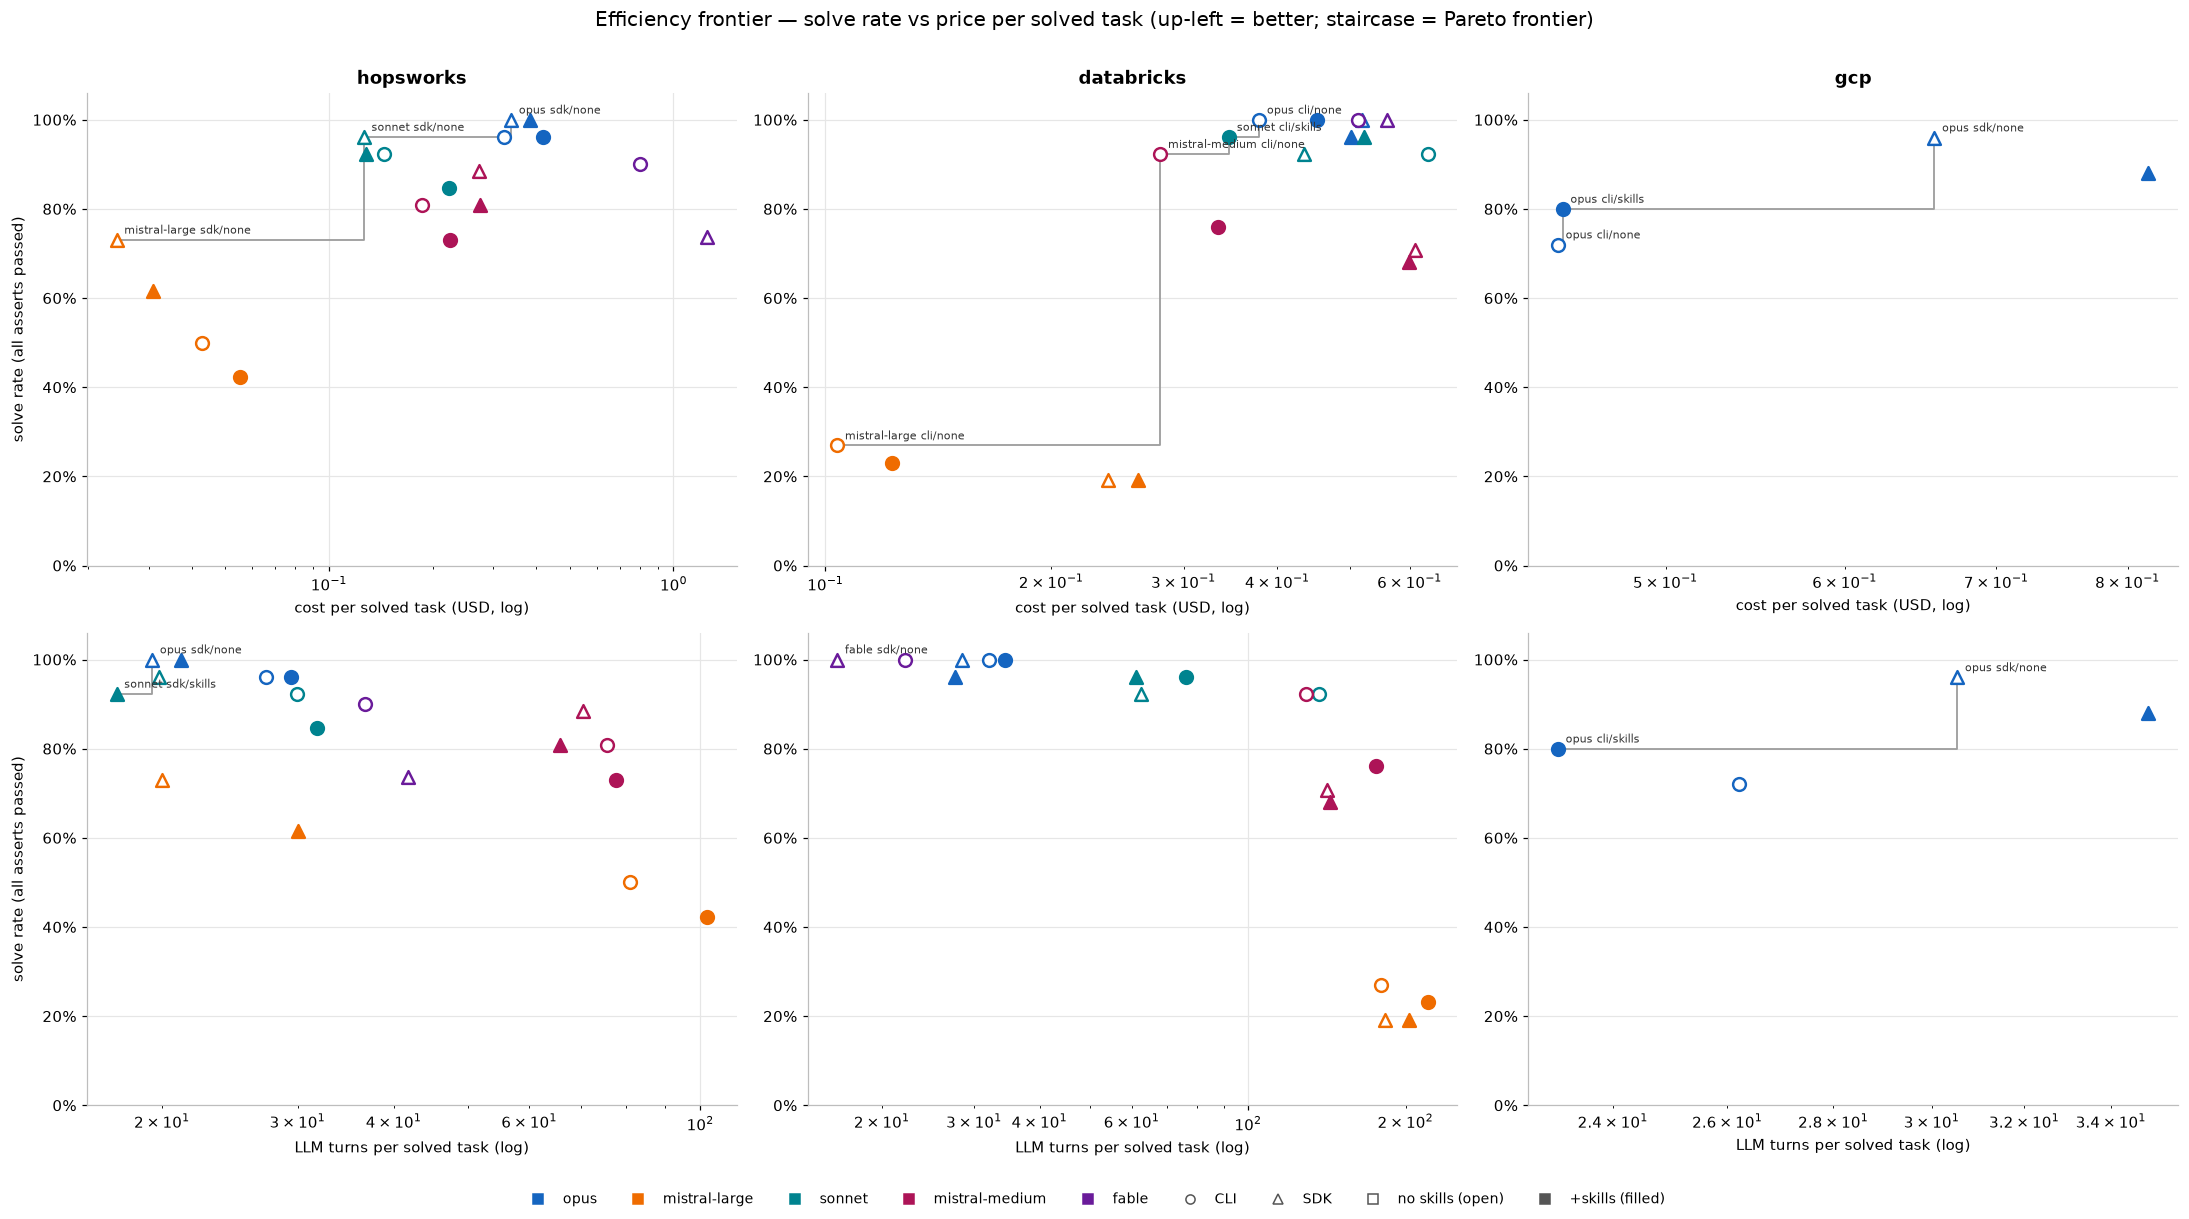

In [18]:
MCOLOR = {"opus": "#1565c0", "sonnet": "#00838f", "fable": "#6a1b9a",
          "mistral-large": "#ef6c00", "mistral-medium": "#ad1457"}
MMARK = {"cli": "o", "sdk": "^"}

fr_rows = []
for plat in PLATFORMS:
    for m in [m for m in MODEL_ORDER if m in CFG[plat]]:
        for iface, sk in VARIANTS:
            s = sel(CFG[plat][m], iface, sk)
            if len(s) == 0:
                continue
            solved = int(s.success.sum())
            fr_rows.append({
                "platform": plat, "model": m, "interface": iface, "skills": sk,
                "tasks": len(s), "solved": solved,
                "solve_rate": solved / len(s),
                "total_cost": s.cost_usd.sum(),
                "cost_per_solve": s.cost_usd.sum() / solved if solved else np.nan,
                "turns_per_solve": s.llm_calls.sum() / solved if solved else np.nan,
                "time_per_solve": s.local_time_s.sum() / solved if solved else np.nan,
            })
frontier = pd.DataFrame(fr_rows)

def pareto(sub, xcol):
    """Non-dominated cells: no other cell has higher solve_rate AND lower x."""
    keep = []
    for i, r in sub.iterrows():
        if pd.isna(r[xcol]):
            continue
        dominated = ((sub.solve_rate >= r.solve_rate) & (sub[xcol] < r[xcol]) &
                     ((sub.solve_rate > r.solve_rate) | (sub[xcol] < r[xcol]))).any()
        if not dominated:
            keep.append(i)
    return sub.loc[keep].sort_values(xcol)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
for row, (xcol, xlabel) in enumerate([("cost_per_solve", "cost per solved task (USD, log)"),
                                      ("turns_per_solve", "LLM turns per solved task (log)")]):
    for col, plat in enumerate(PLATFORMS):
        ax = axes[row, col]
        sub = frontier[frontier.platform == plat]
        for _, r in sub.iterrows():
            if pd.isna(r[xcol]):
                continue
            filled = r.skills == "official"
            ax.scatter(r[xcol], r.solve_rate, s=70, marker=MMARK[r.interface],
                       facecolor=MCOLOR[r.model] if filled else "white",
                       edgecolor=MCOLOR[r.model], linewidth=1.6, zorder=3)
        par = pareto(sub, xcol)
        ax.step(par[xcol], par.solve_rate, where="post", color="#9e9e9e",
                lw=1.2, zorder=2)
        for _, r in par.iterrows():
            ax.annotate(f"{r.model} {r.interface}/{'skills' if r.skills == 'official' else 'none'}",
                        (r[xcol], r.solve_rate), textcoords="offset points",
                        xytext=(5, 4), fontsize=7, color="#333")
        ax.set_xscale("log")
        ax.set_ylim(0, 1.06)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        if row == 0:
            ax.set_title(plat, fontsize=12, fontweight="bold")
        ax.set_xlabel(xlabel)
        if col == 0:
            ax.set_ylabel("solve rate (all asserts passed)")

from matplotlib.lines import Line2D
handles = [Line2D([], [], ls="", marker="s", color=MCOLOR[m], label=m) for m in MODEL_ORDER] + [
    Line2D([], [], ls="", marker="o", mfc="white", mec="#555", label="CLI"),
    Line2D([], [], ls="", marker="^", mfc="white", mec="#555", label="SDK"),
    Line2D([], [], ls="", marker="s", mfc="white", mec="#555", label="no skills (open)"),
    Line2D([], [], ls="", marker="s", mfc="#555", mec="#555", label="+skills (filled)"),
]
fig.legend(handles=handles, loc="lower center", ncol=9, frameon=False, fontsize=9)
fig.suptitle("Efficiency frontier — solve rate vs price per solved task "
             "(up-left = better; staircase = Pareto frontier)", fontsize=13, y=0.995)
plt.tight_layout(rect=(0, 0.035, 1, 0.99))
plt.show()

Per-cell numbers, sorted by cost per solve within each platform:

In [19]:
ft = frontier.sort_values(["platform", "cost_per_solve"]).set_index(
    ["platform", "model", "interface", "skills"])
ft[["tasks", "solved", "solve_rate", "total_cost",
    "cost_per_solve", "turns_per_solve", "time_per_solve"]].style.format({
    "solve_rate": "{:.0%}", "total_cost": "{:.2f}", "cost_per_solve": "{:.3f}",
    "turns_per_solve": "{:.0f}", "time_per_solve": "{:.0f}"}, na_rep="—")

## 8. Thesis figures

The print-ready thesis figures and every statistic reported in the thesis are
generated by the authoritative analysis scripts, not by this notebook:

| script | output |
|---|---|
| `../docs/thesis/img/market/make_charts.py` | market assessment charts (RQ1) |
| `../docs/thesis/img/benchmark/make_charts.py` | benchmark charts + `stats_report.txt` (RQ2) |
| `../docs/thesis/img/optimizations/make_charts.py` | optimization charts + `stats_report.txt` (RQ3) |

Each script reads its inputs directly (`results/results.csv` or the market
assessment CSV), applies the pre-stated cleaning and testing rules
(Wilcoxon with the normal approximation, McNemar on success, Holm within
family, paired t as sensitivity), and writes PDFs for the thesis plus PNGs.
The cells below regenerate everything and display the generated figures
inline, grouped per folder.

In [20]:
import subprocess, sys
from pathlib import Path

for script in ["../docs/thesis/img/market/make_charts.py",
               "../docs/thesis/img/benchmark/make_charts.py",
               "../docs/thesis/img/optimizations/make_charts.py"]:
    r = subprocess.run([sys.executable, script], capture_output=True, text=True)
    print(Path(script).parent.name, "—", (r.stdout.strip().splitlines() or ["?"])[-1])
    if r.returncode != 0:
        print(r.stderr[-2000:])

market — all charts generated


benchmark — stats chart generated


optimizations — all charts generated


### market

**coverage_by_interface.png**

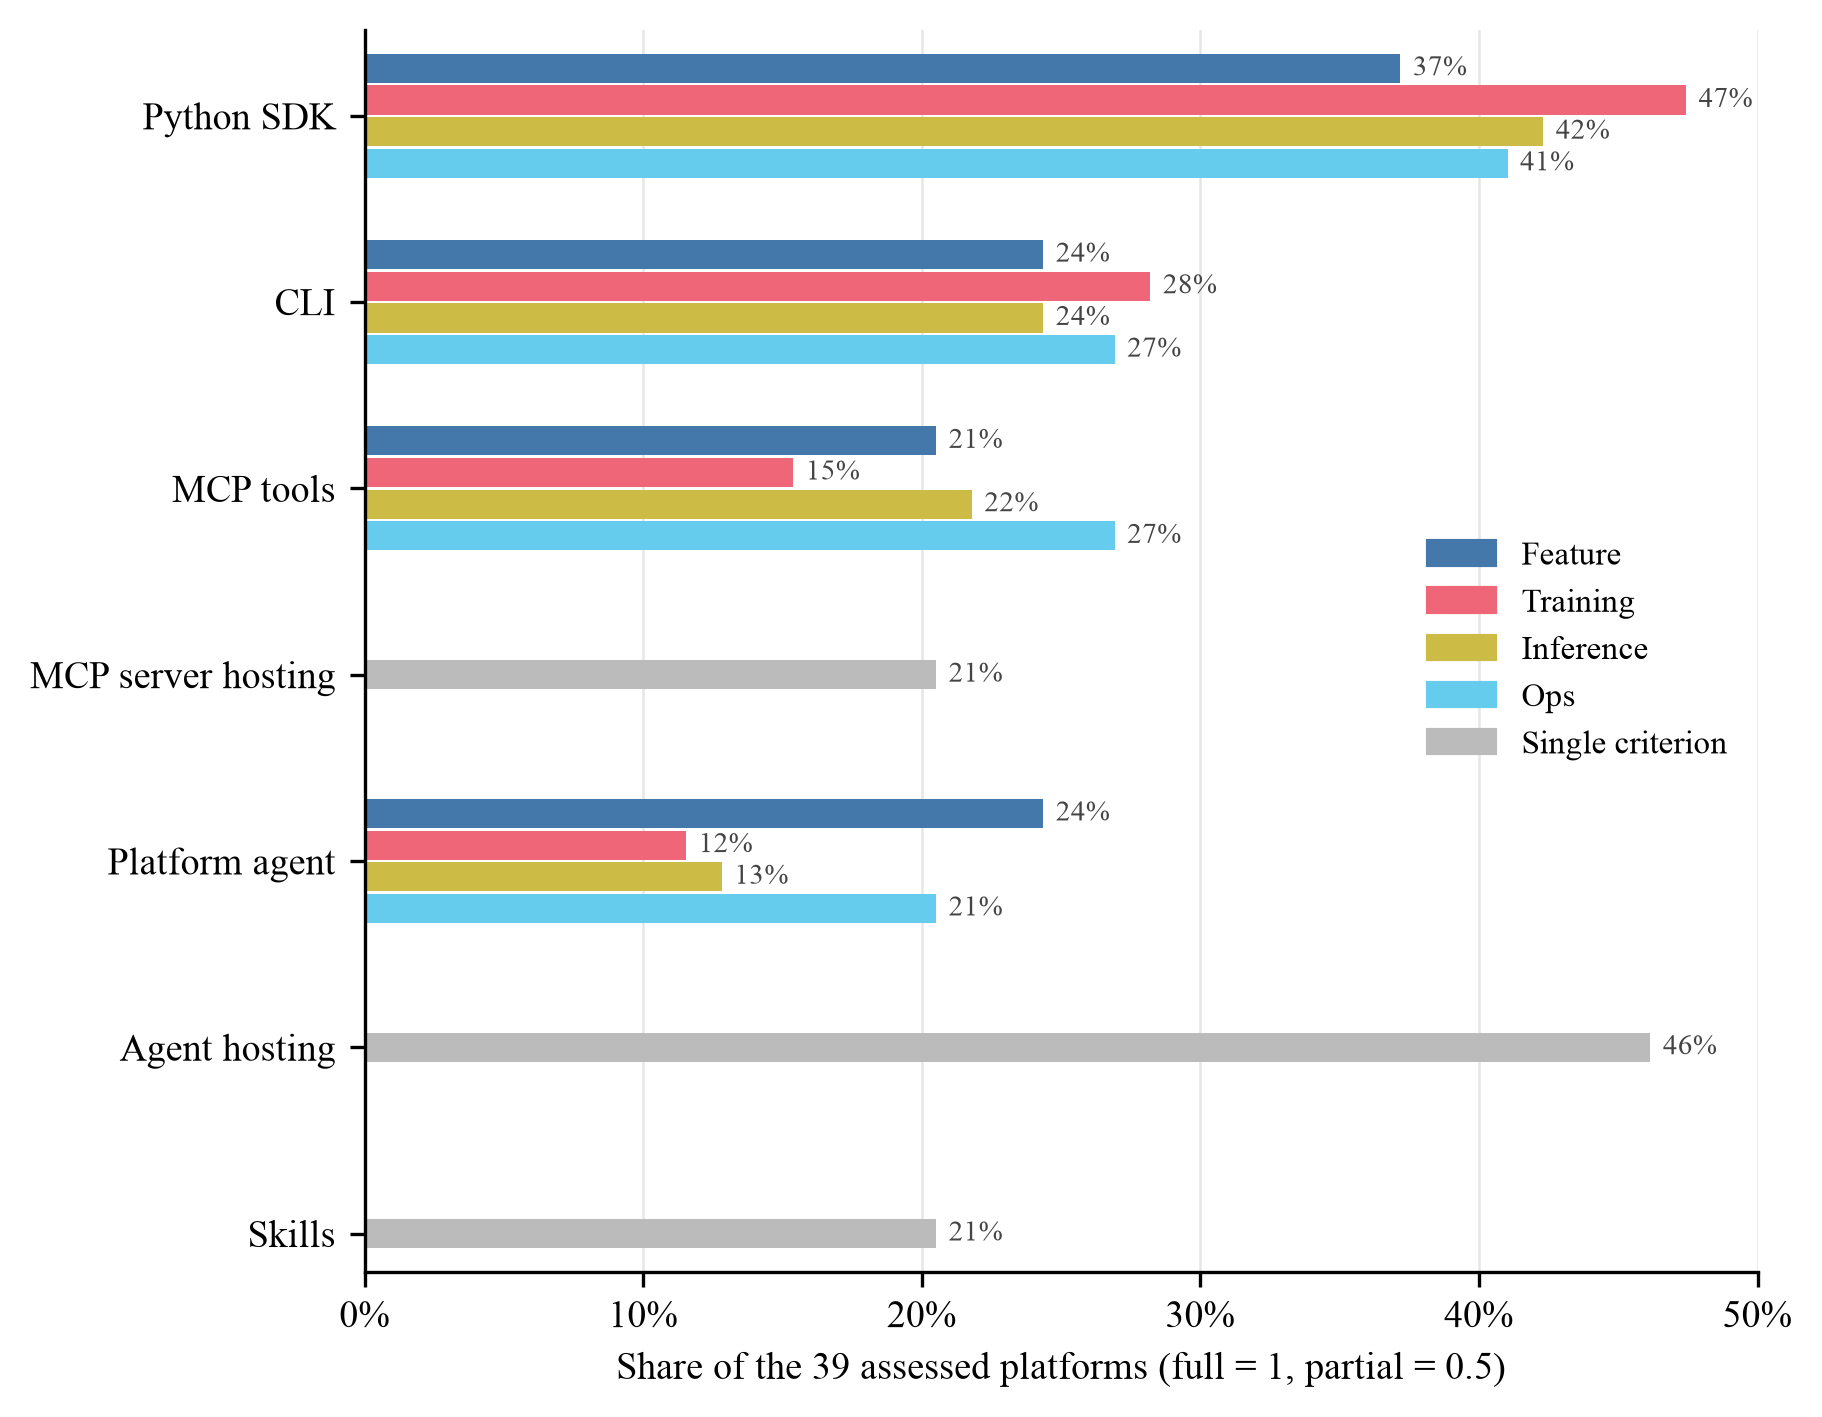

**coverage_rest.png**

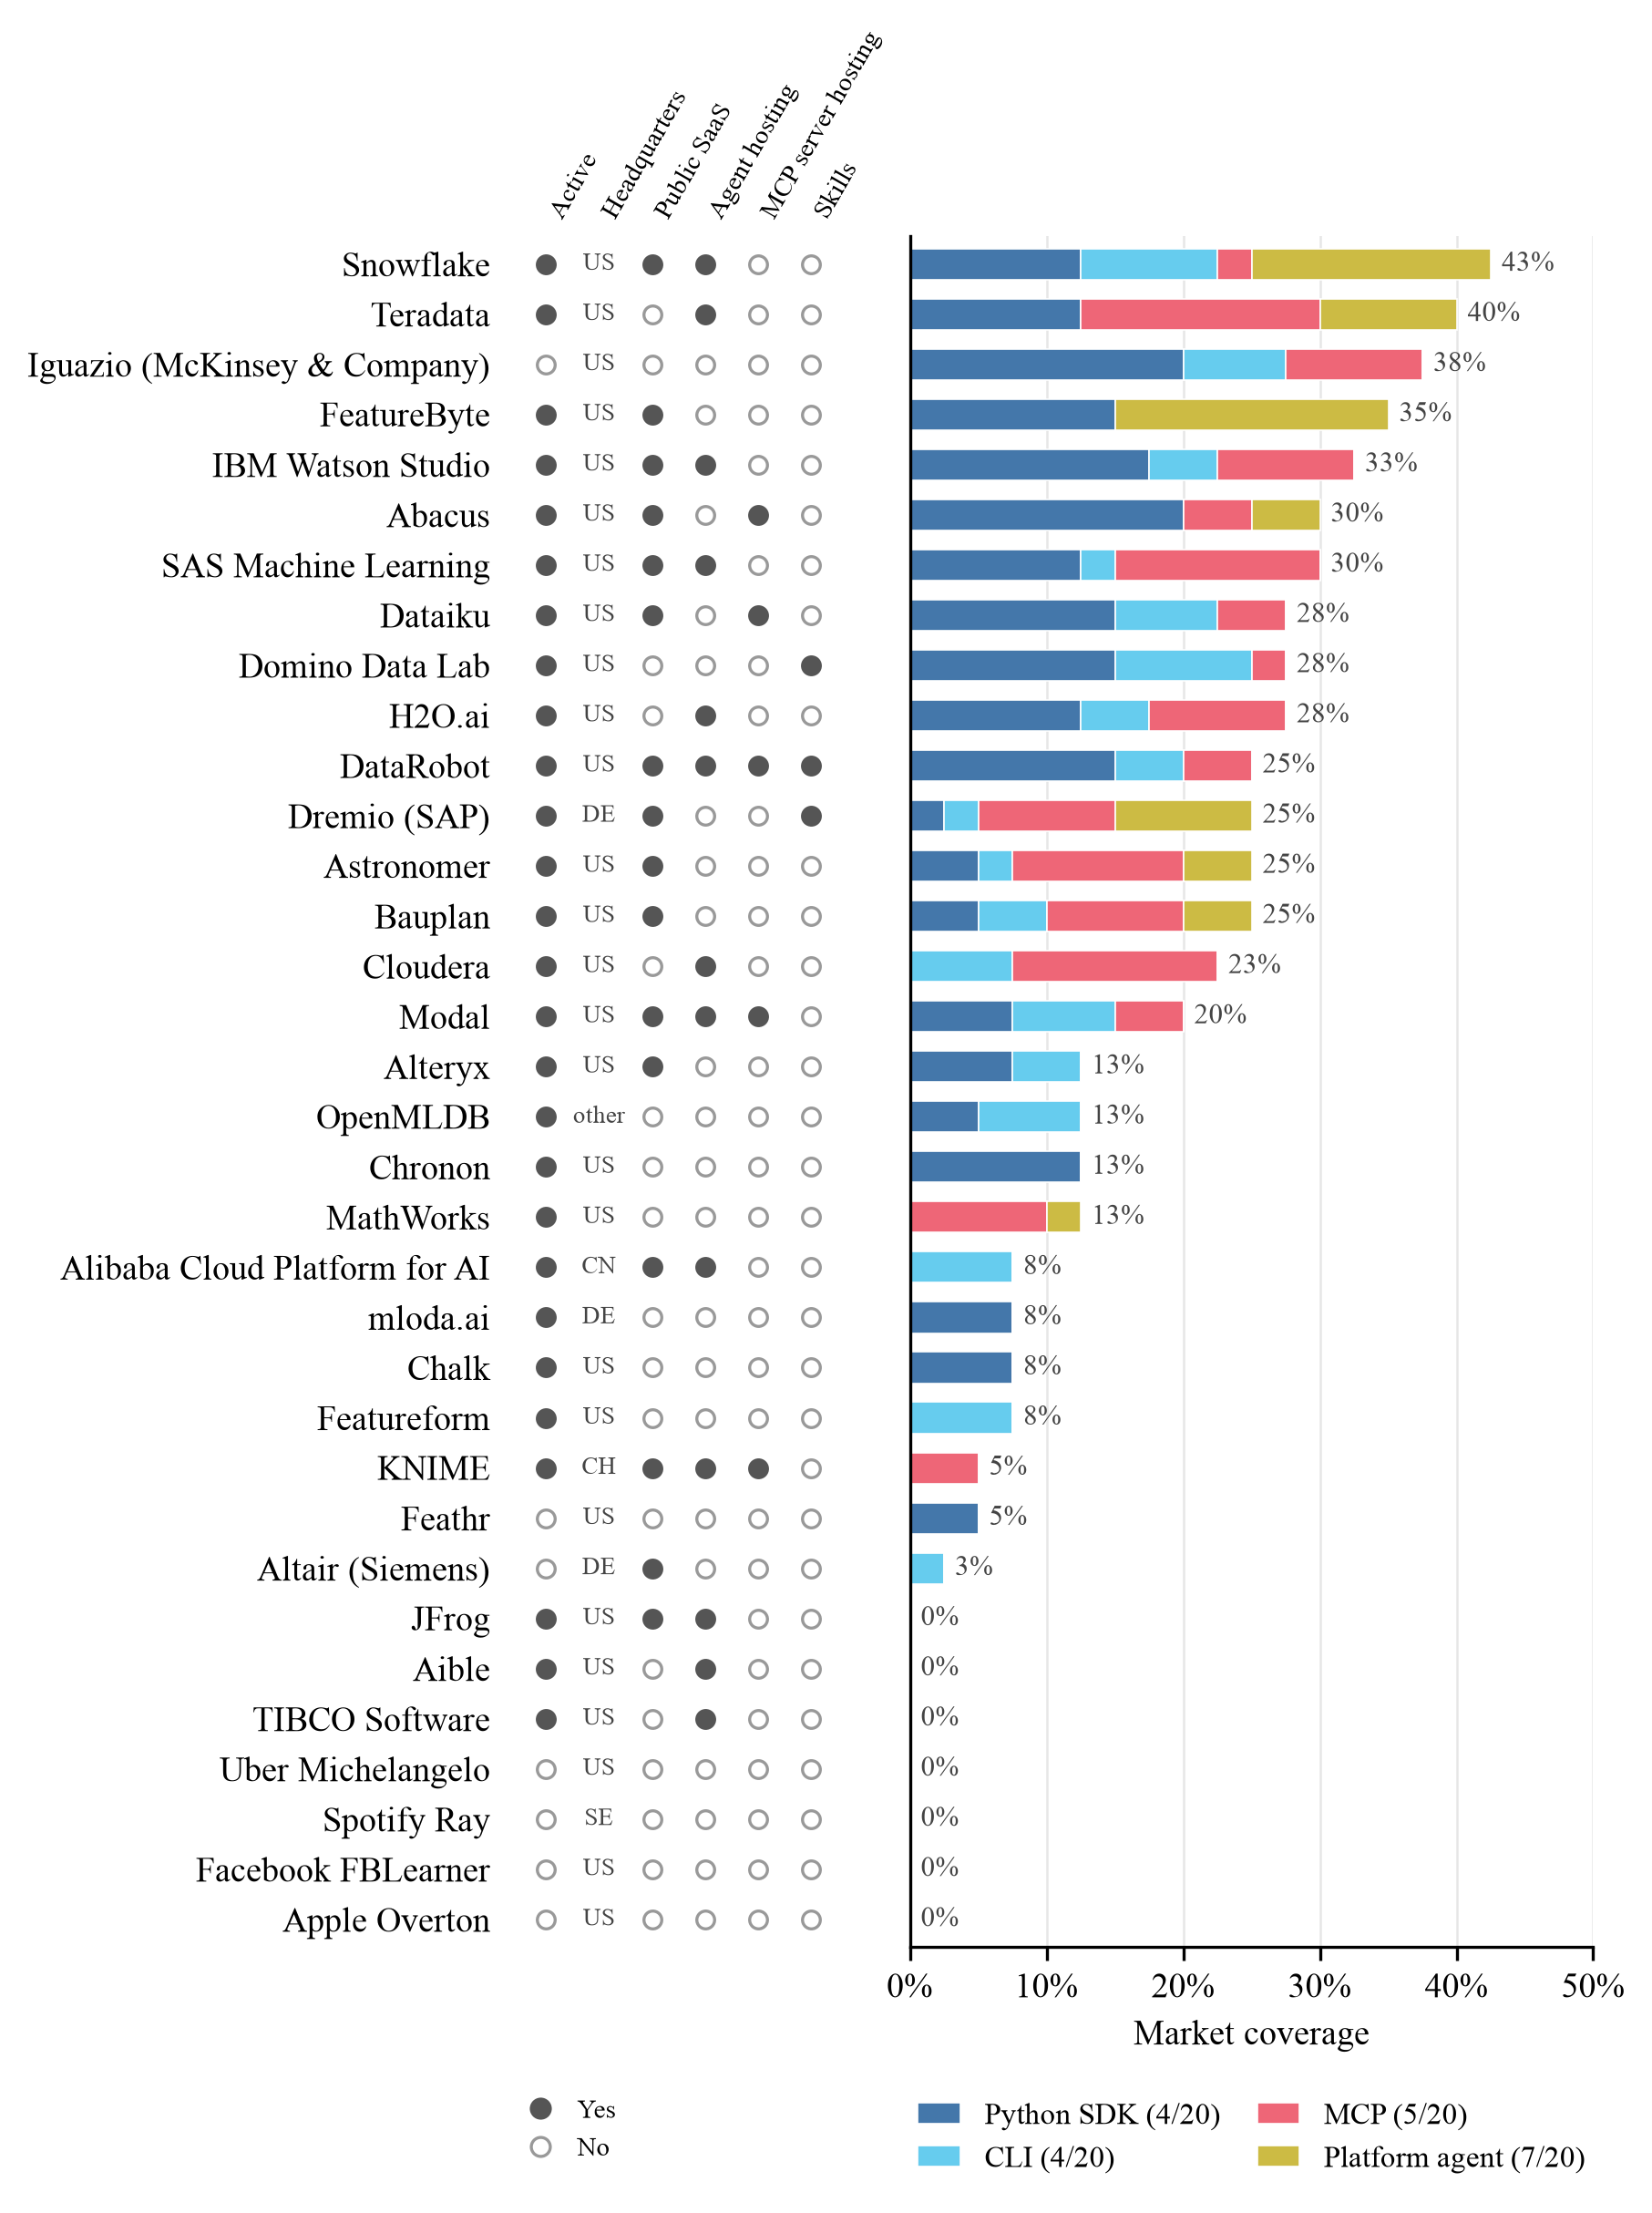

**coverage_top5.png**

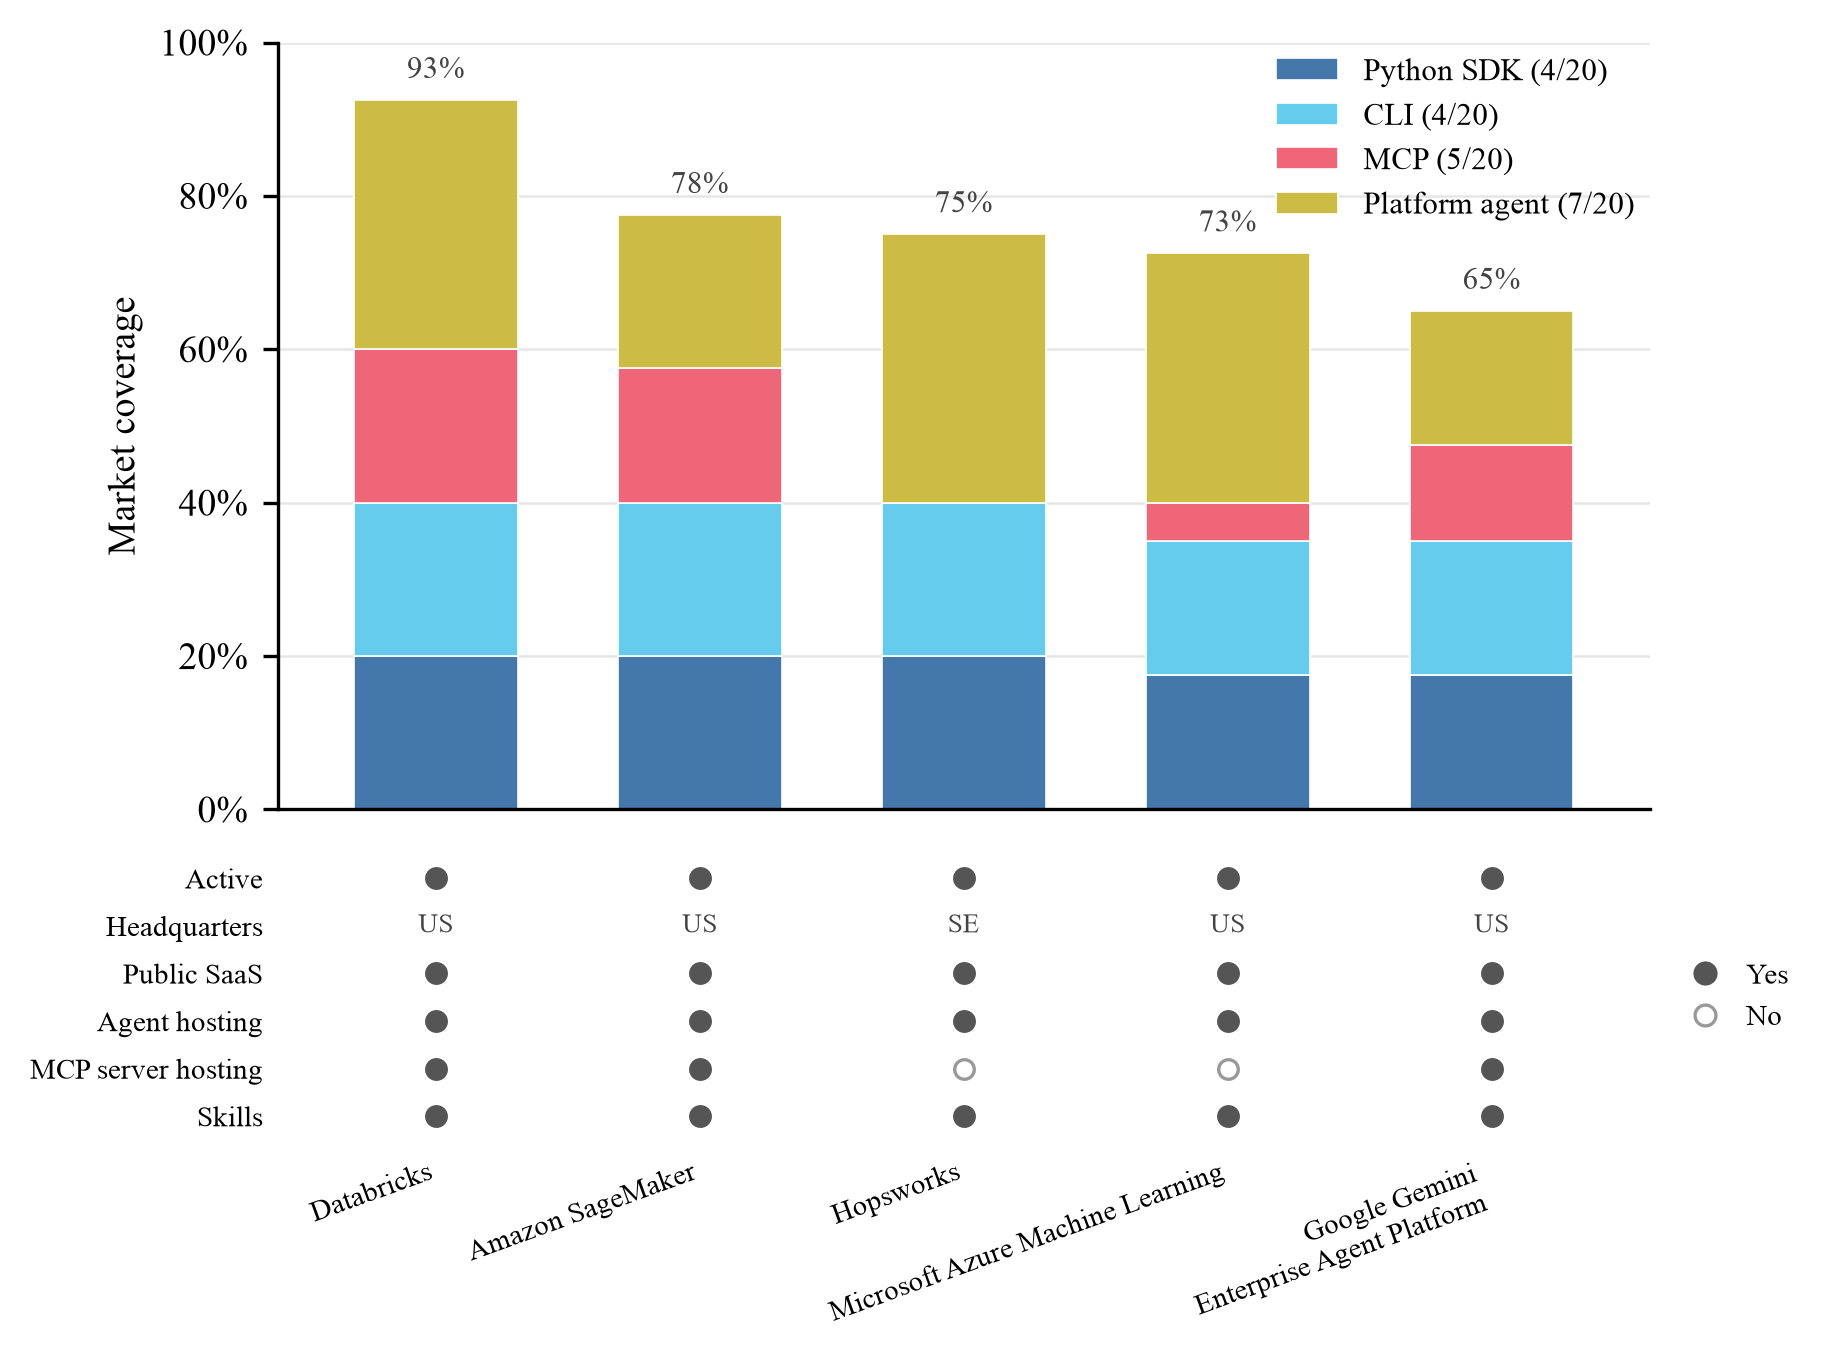

### benchmark

**benchmark_category_capstone.png**

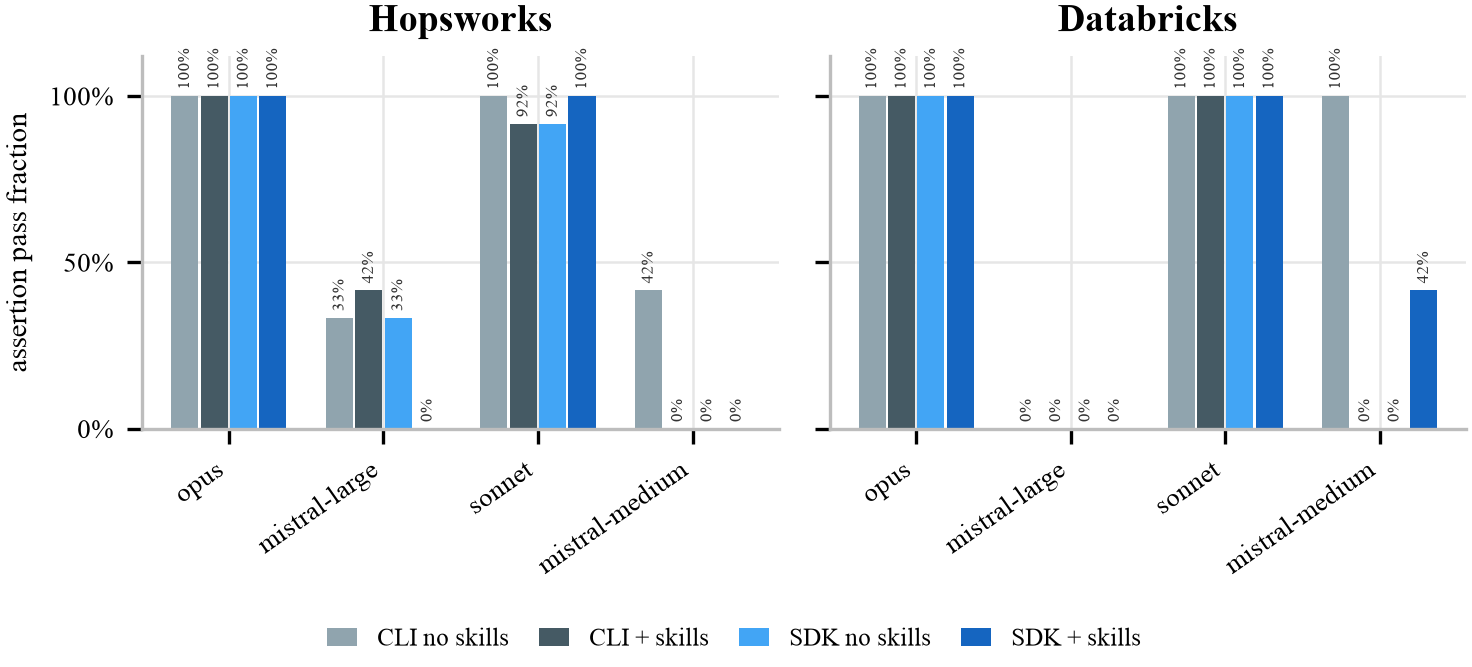

**benchmark_category_feature.png**

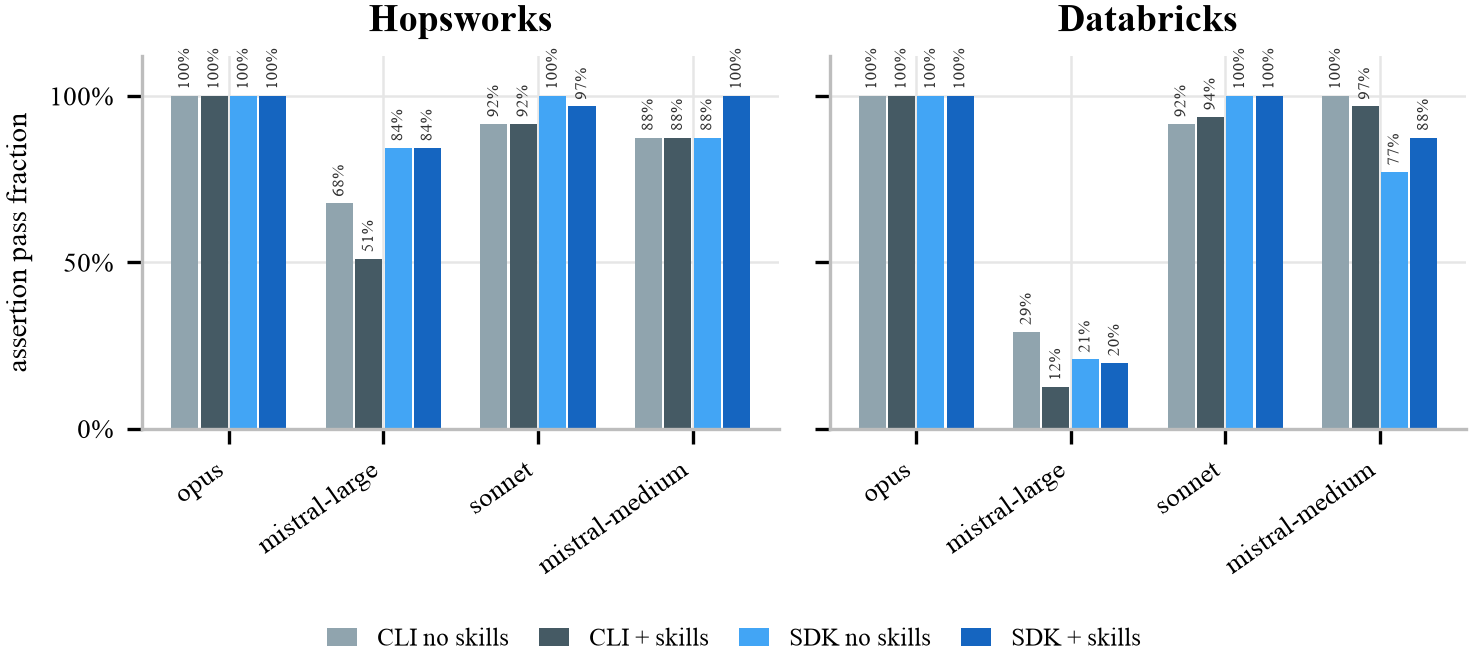

**benchmark_category_inference.png**

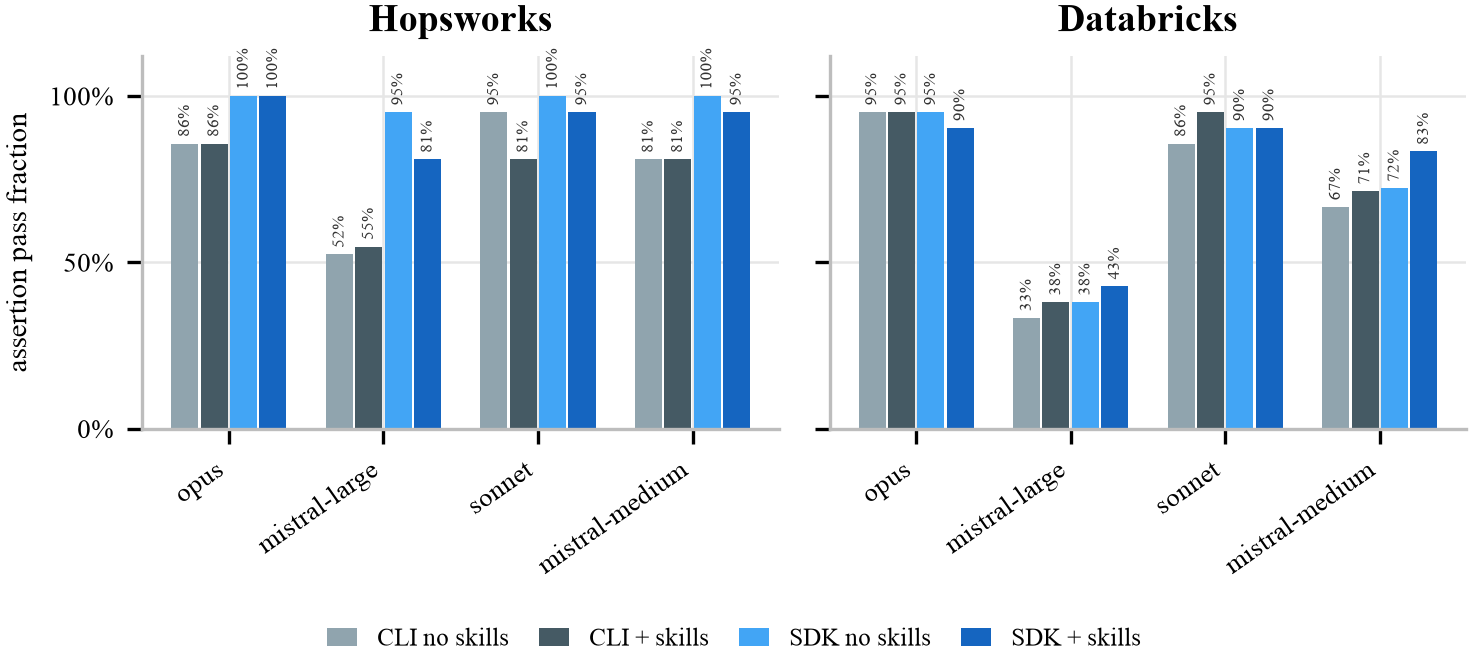

**benchmark_category_ops.png**

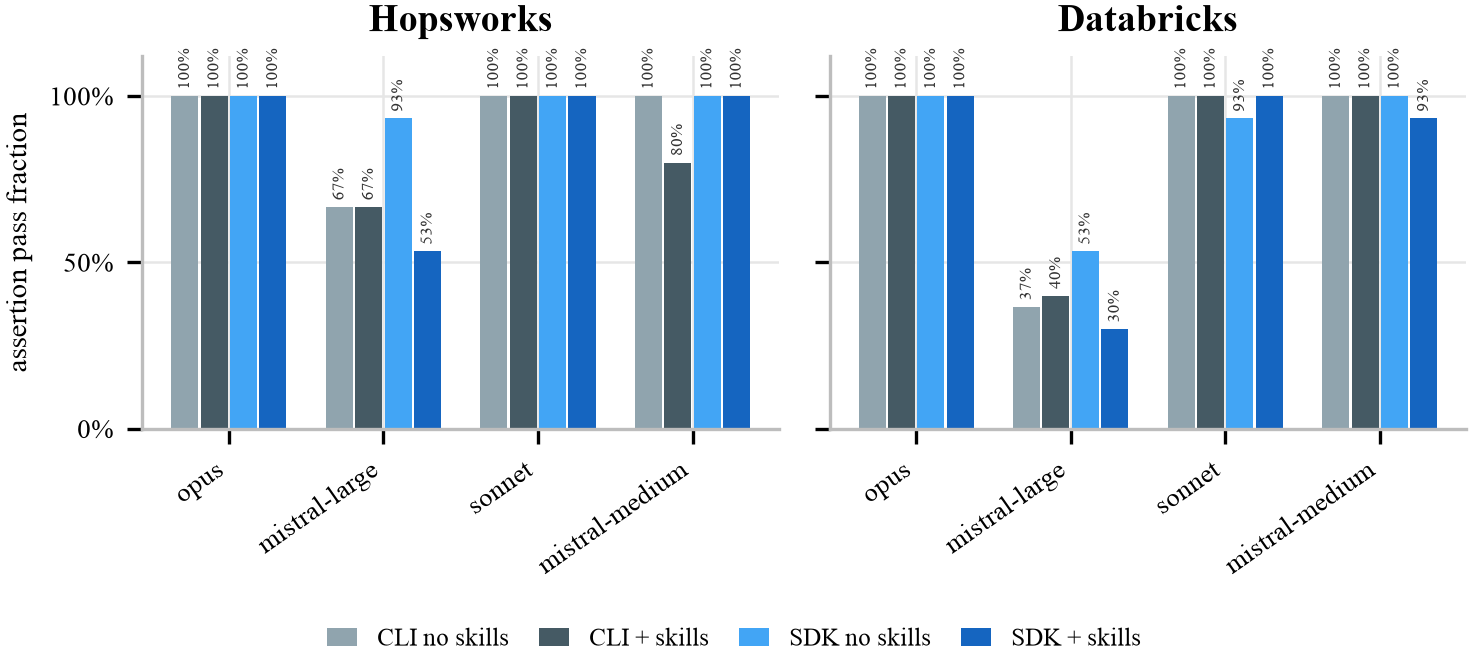

**benchmark_category_training.png**

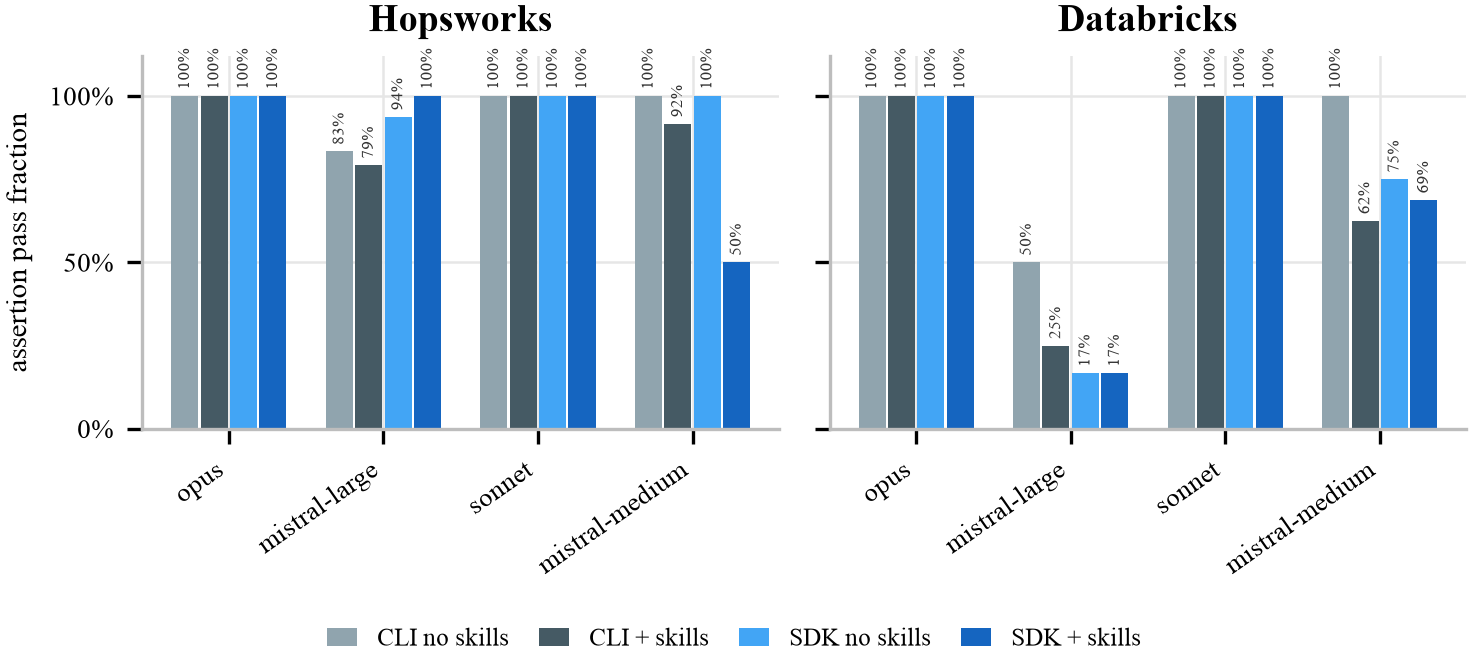

**benchmark_frontier_cost.png**

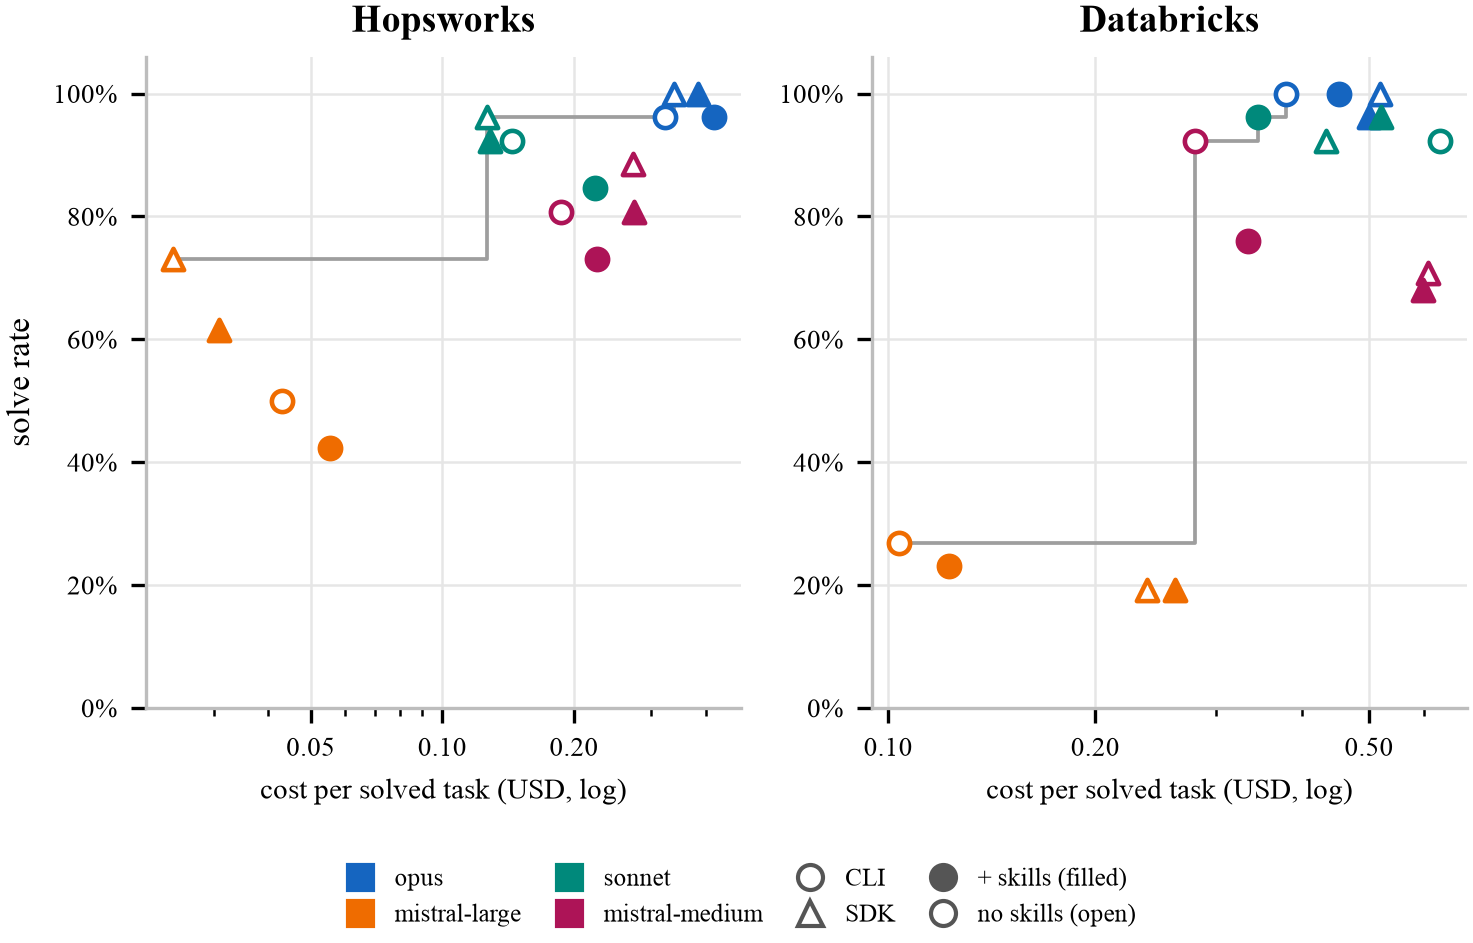

**benchmark_frontier_turns.png**

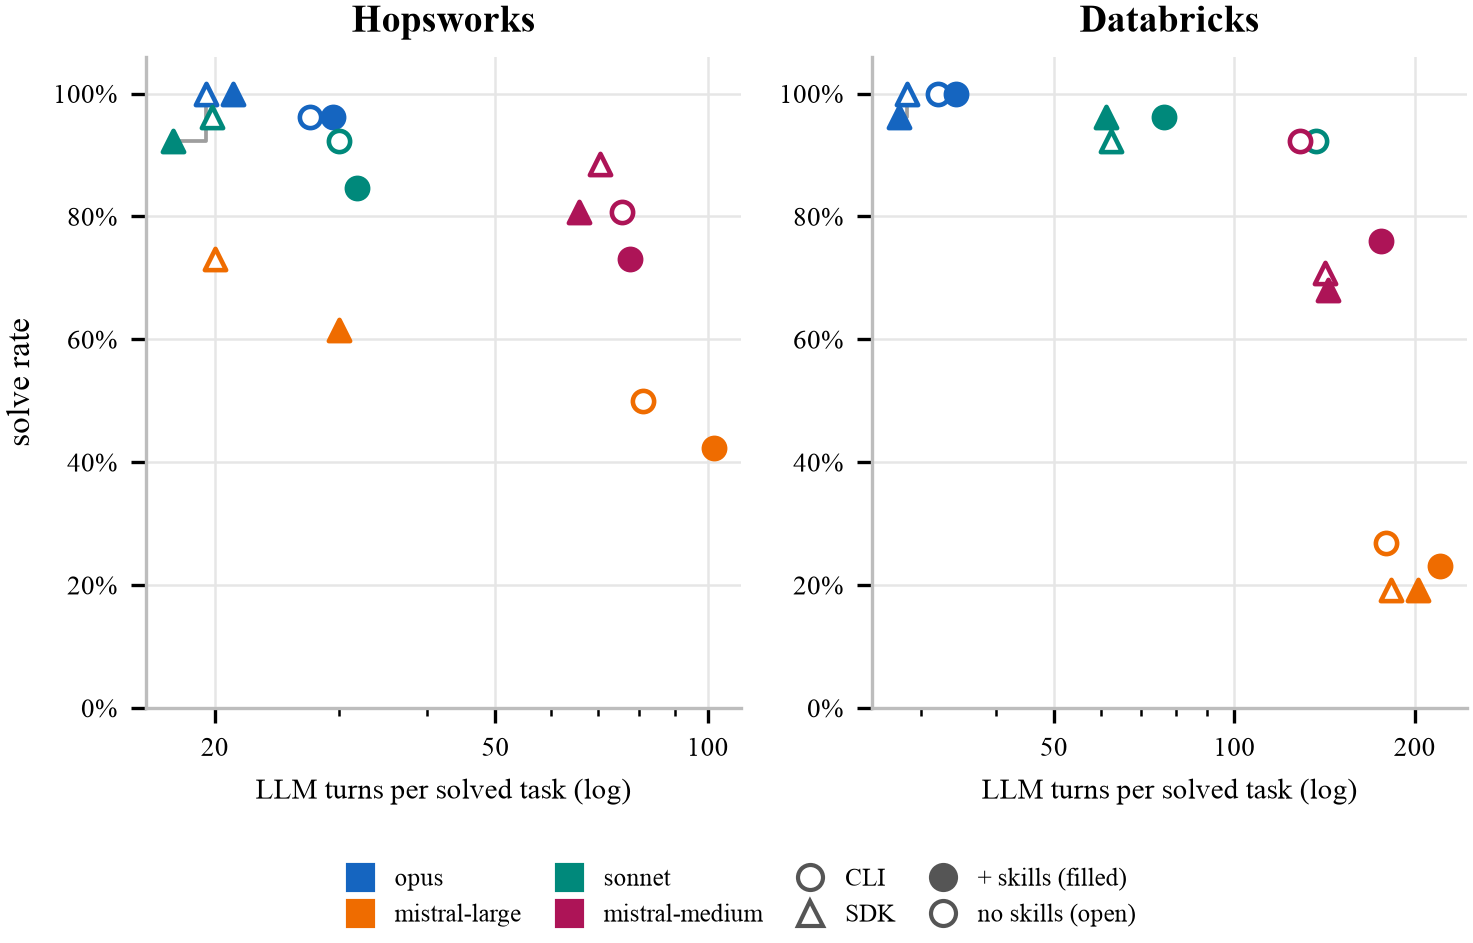

**benchmark_overview_databricks.png**

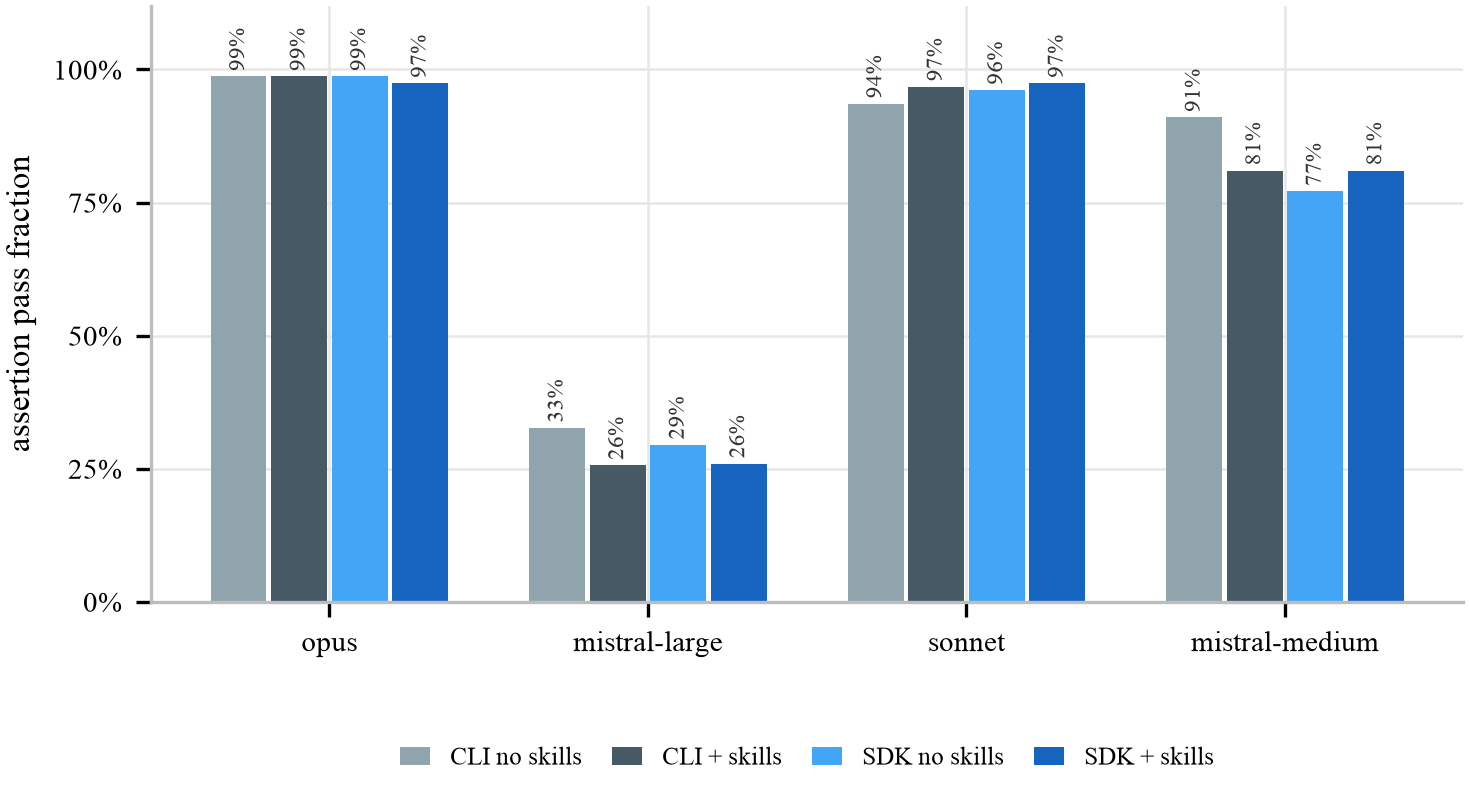

**benchmark_overview_hopsworks.png**

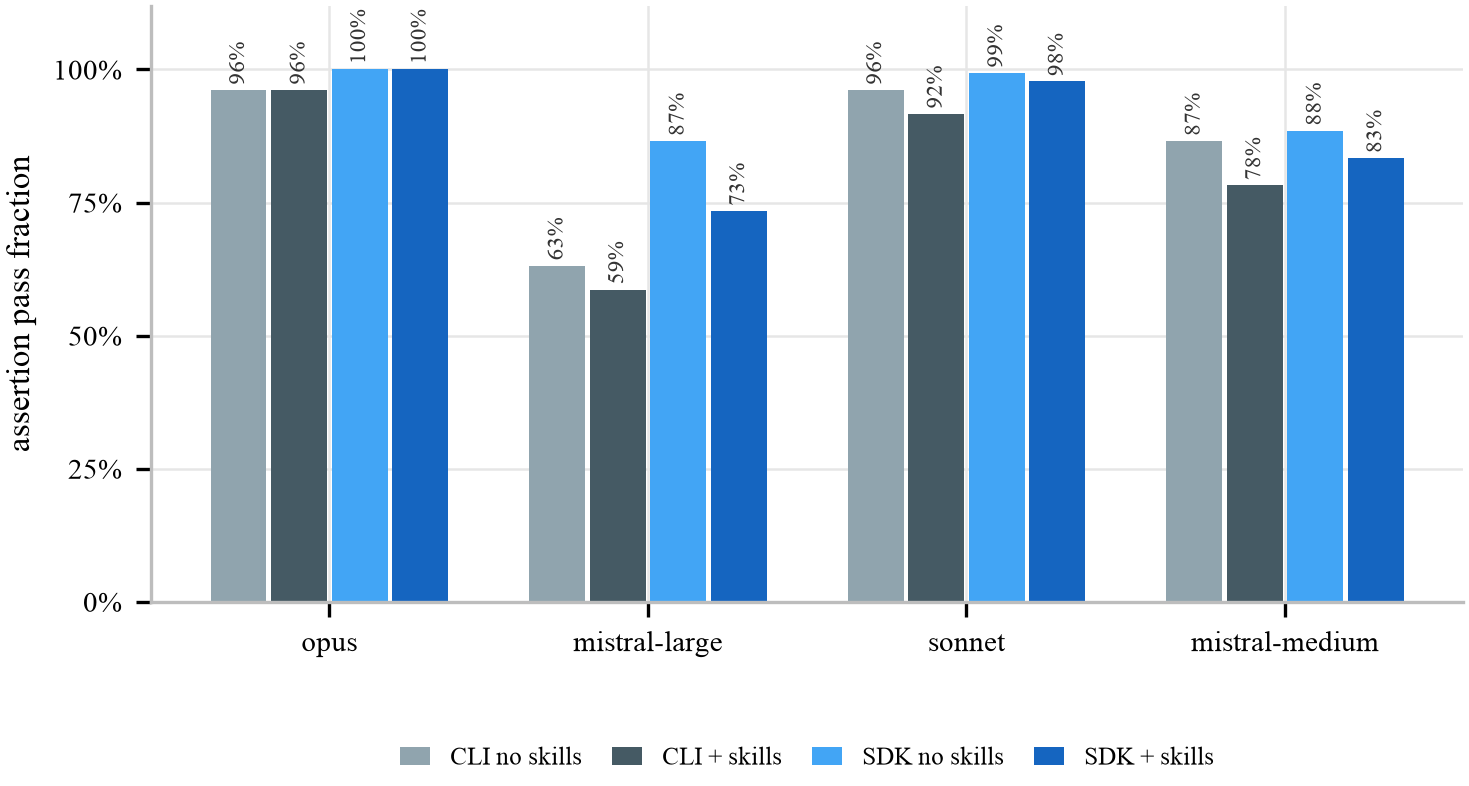

**benchmark_stats_interface.png**

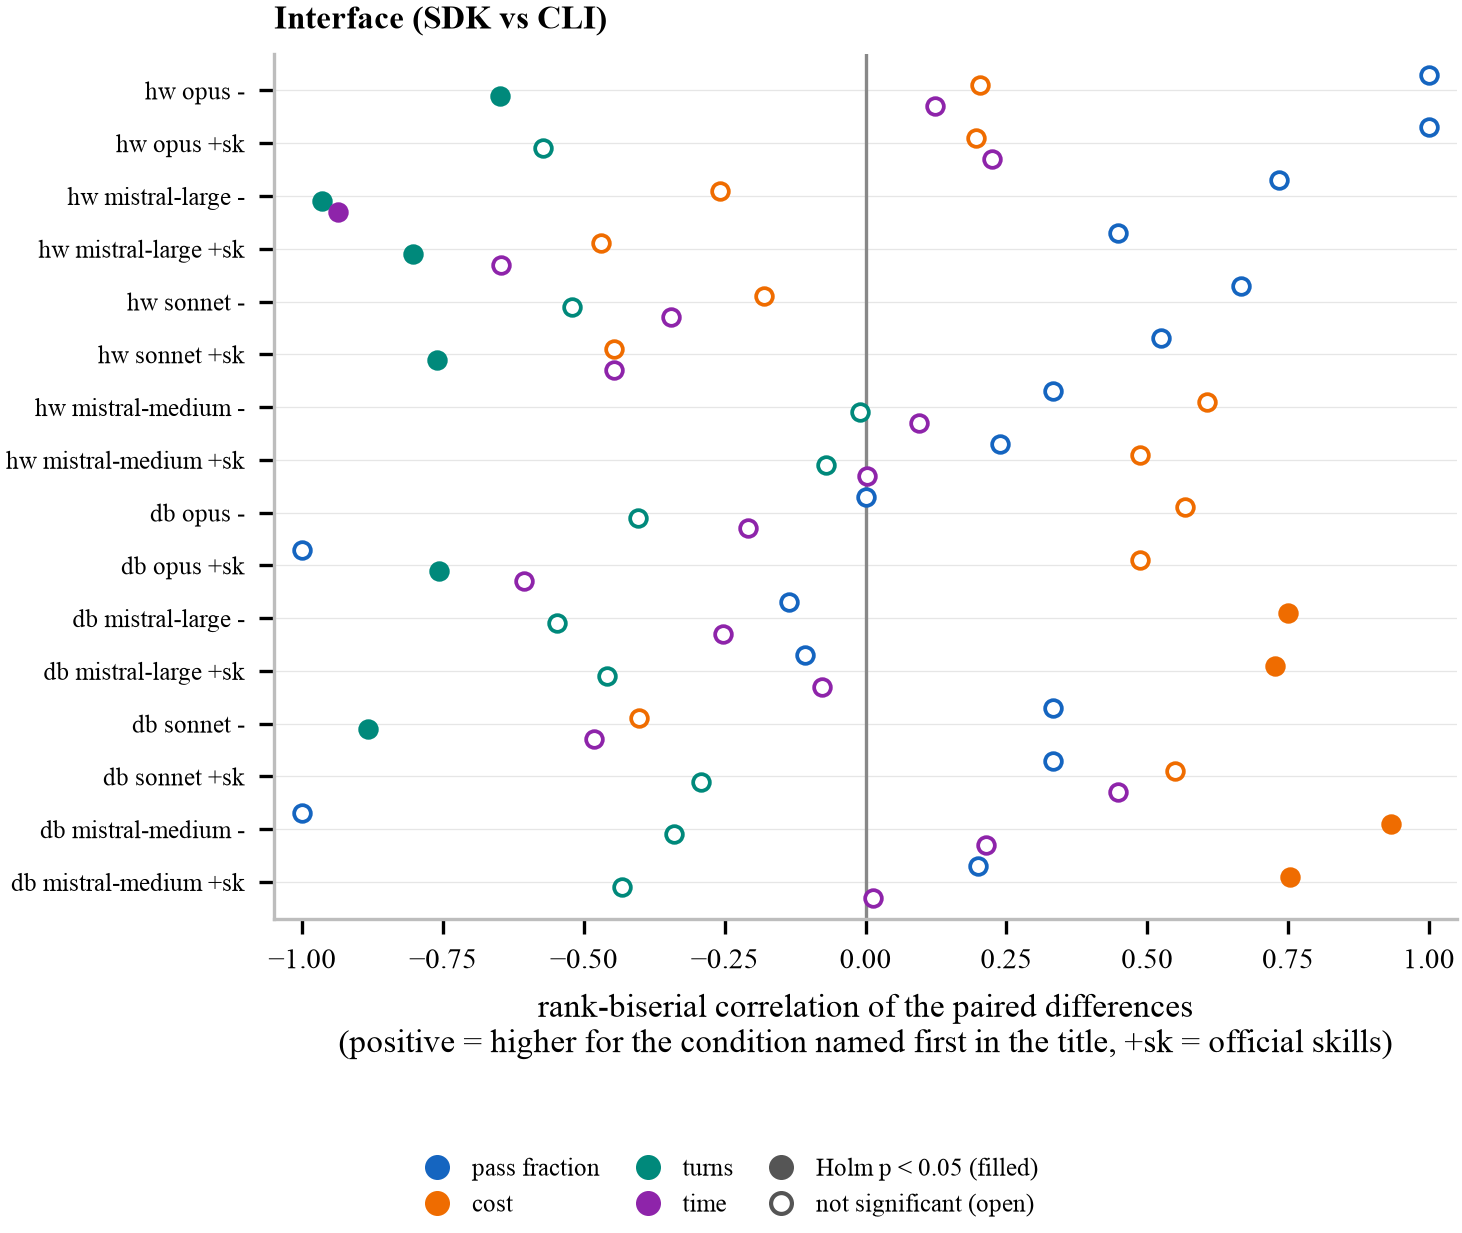

**benchmark_stats_models.png**

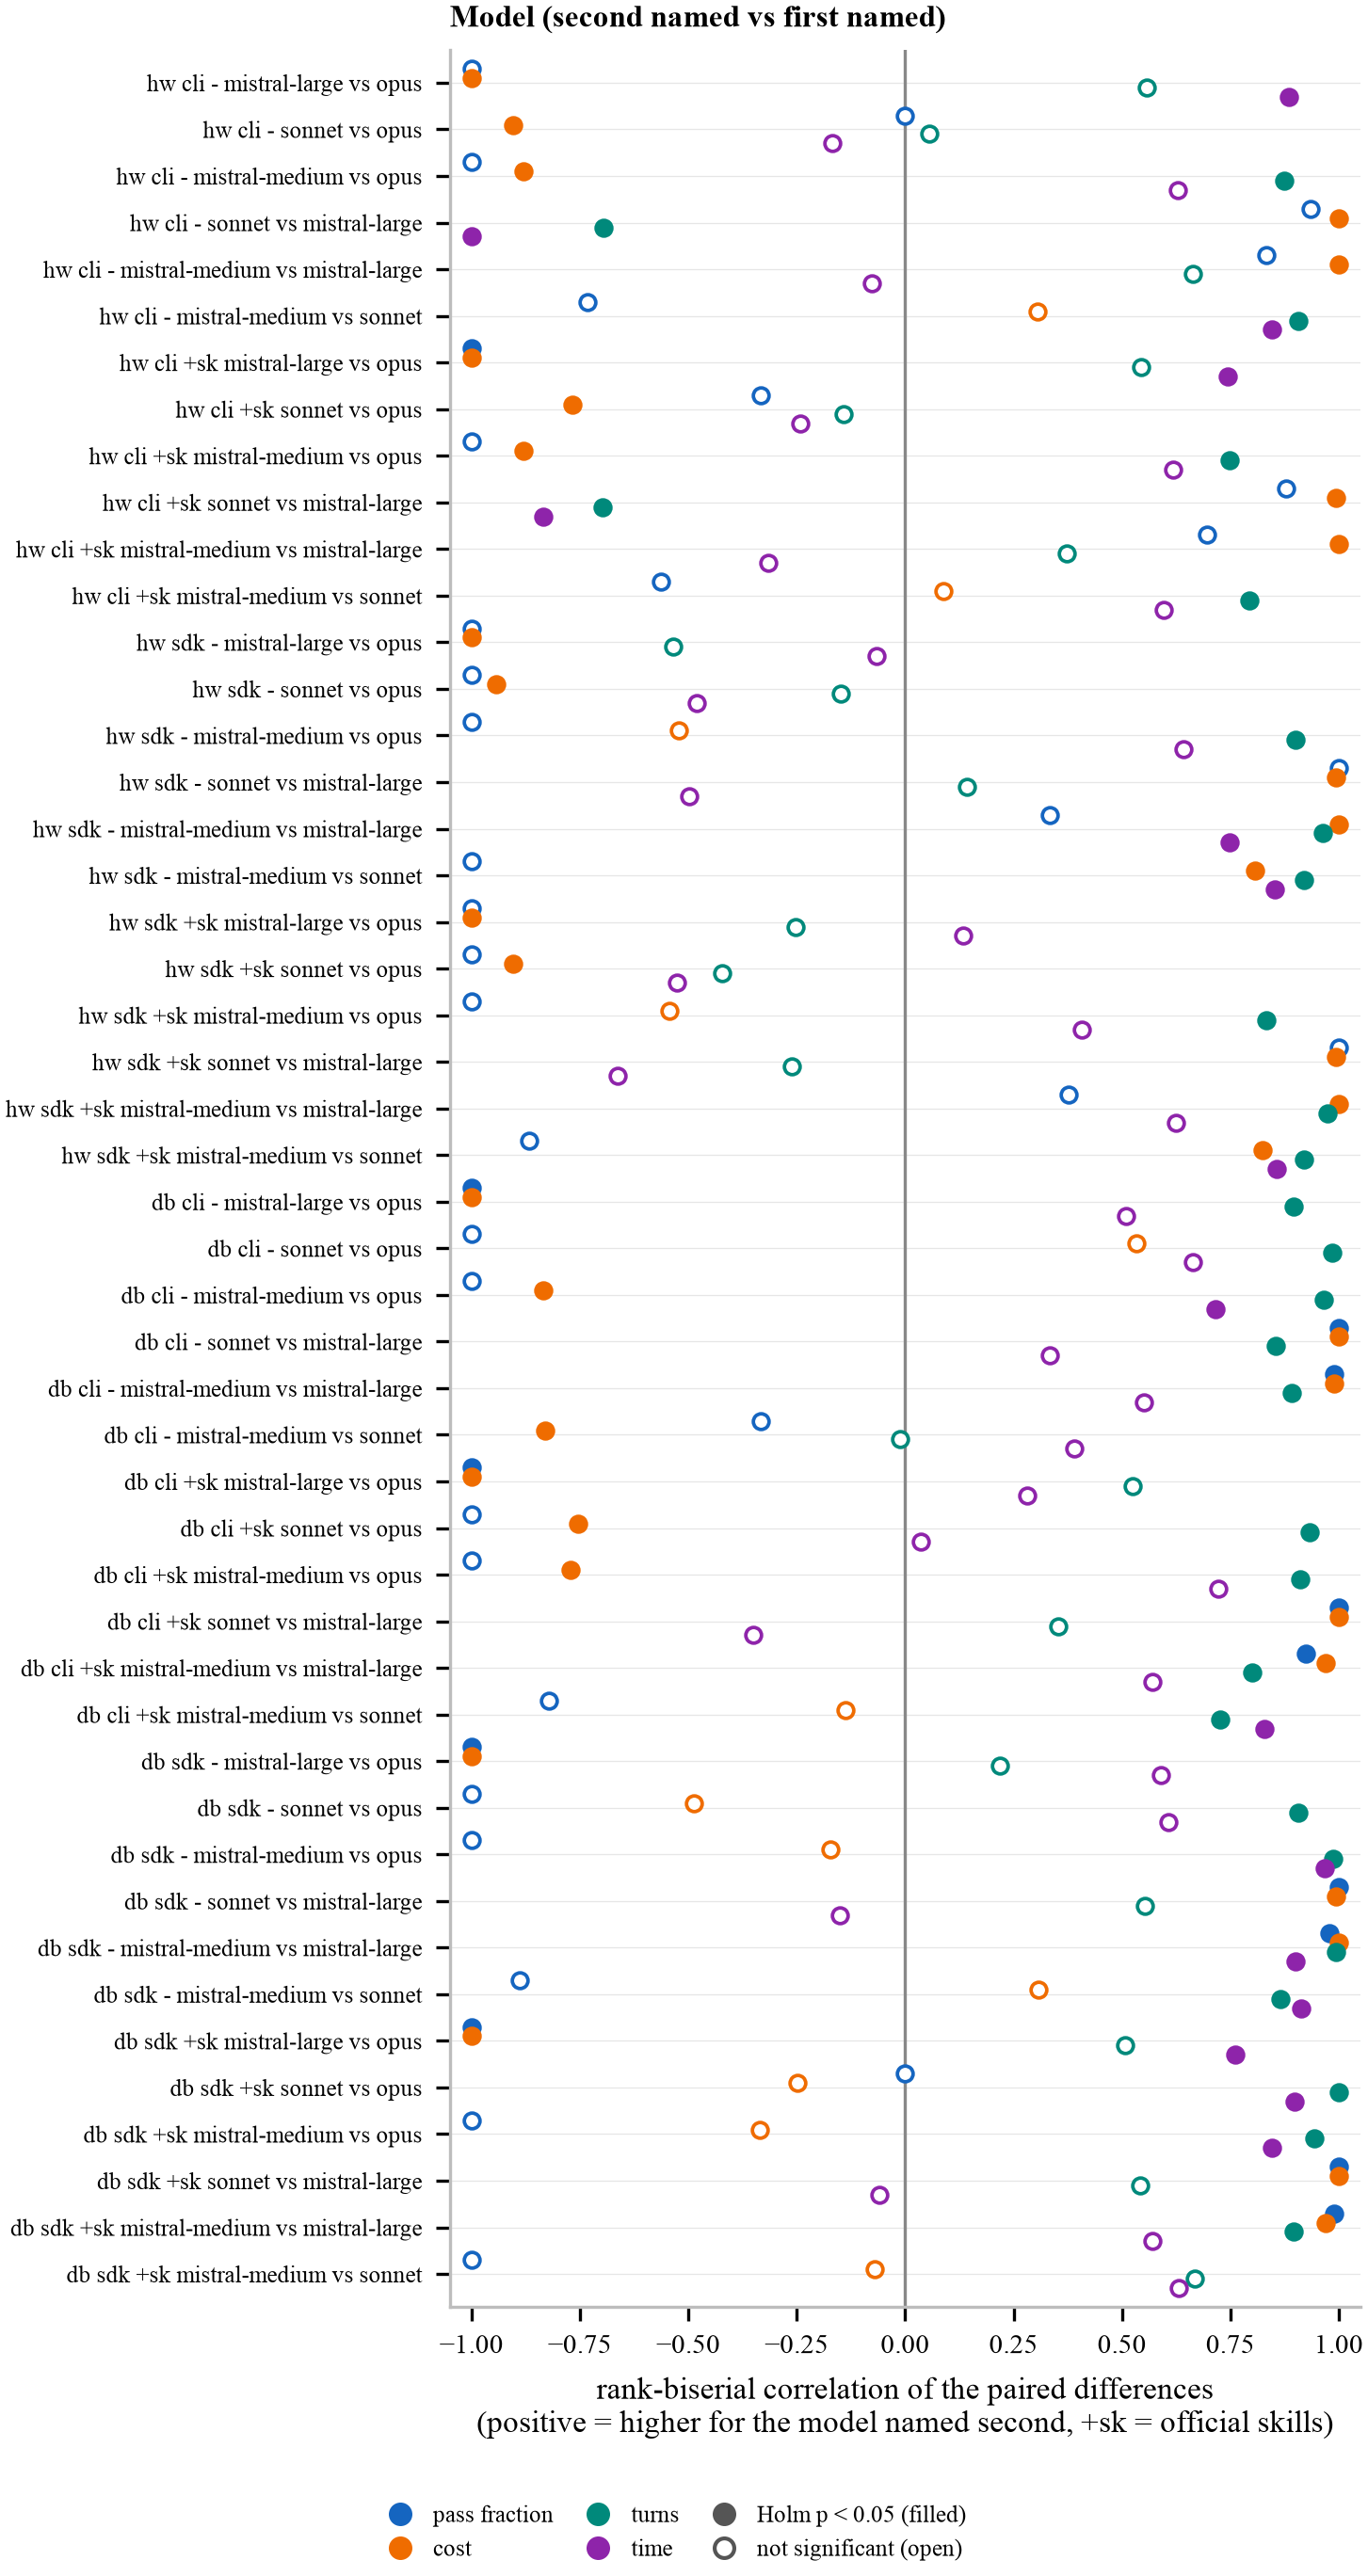

**benchmark_stats_platform.png**

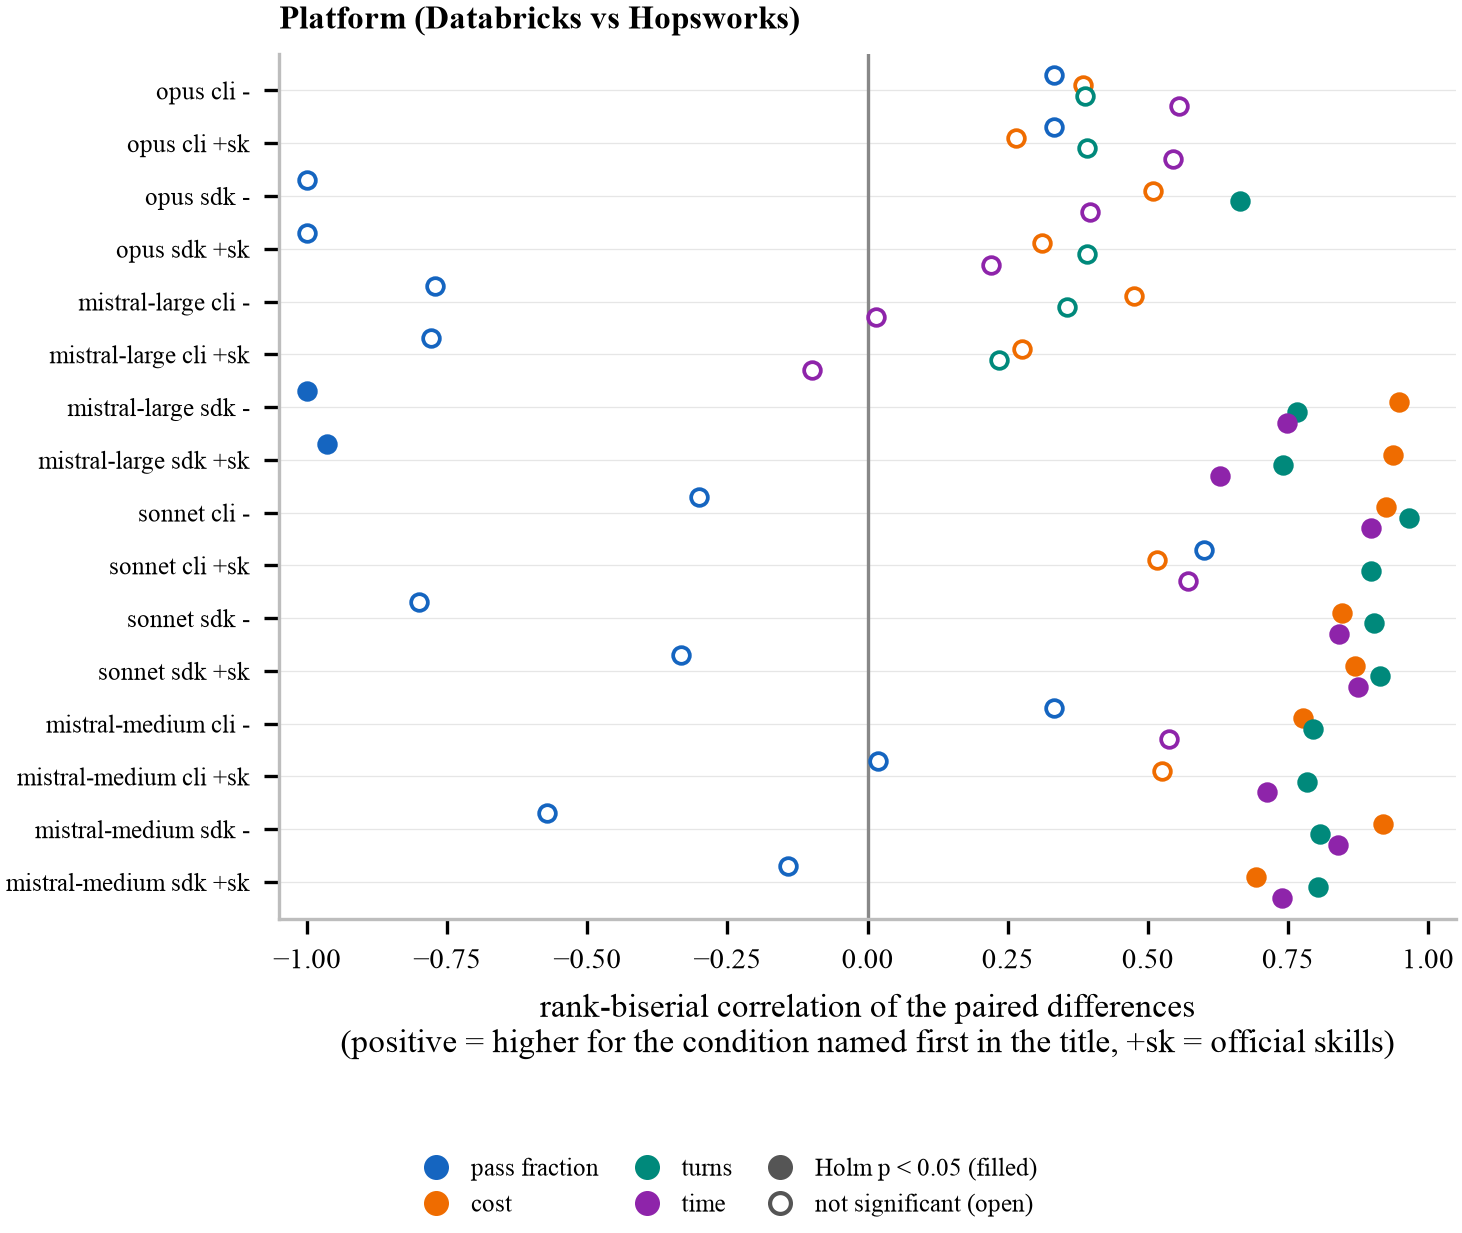

**benchmark_stats_skills.png**

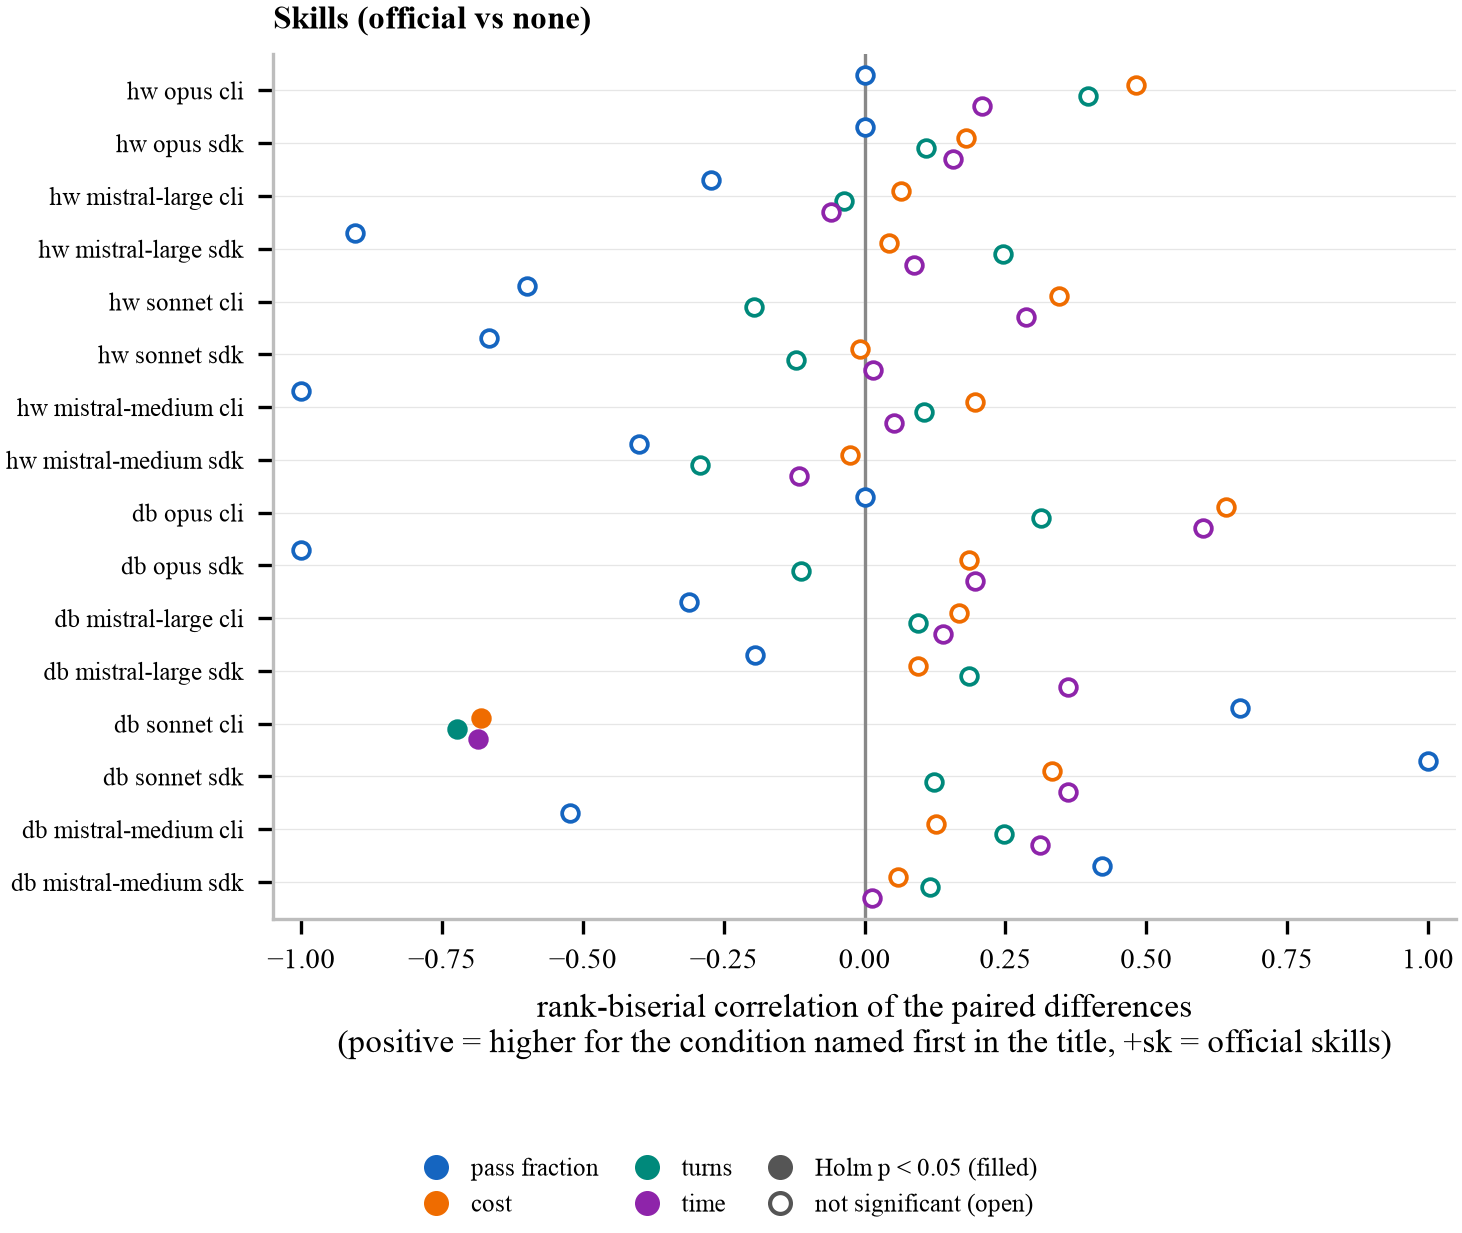

**benchmark_tasks_databricks_cli.png**

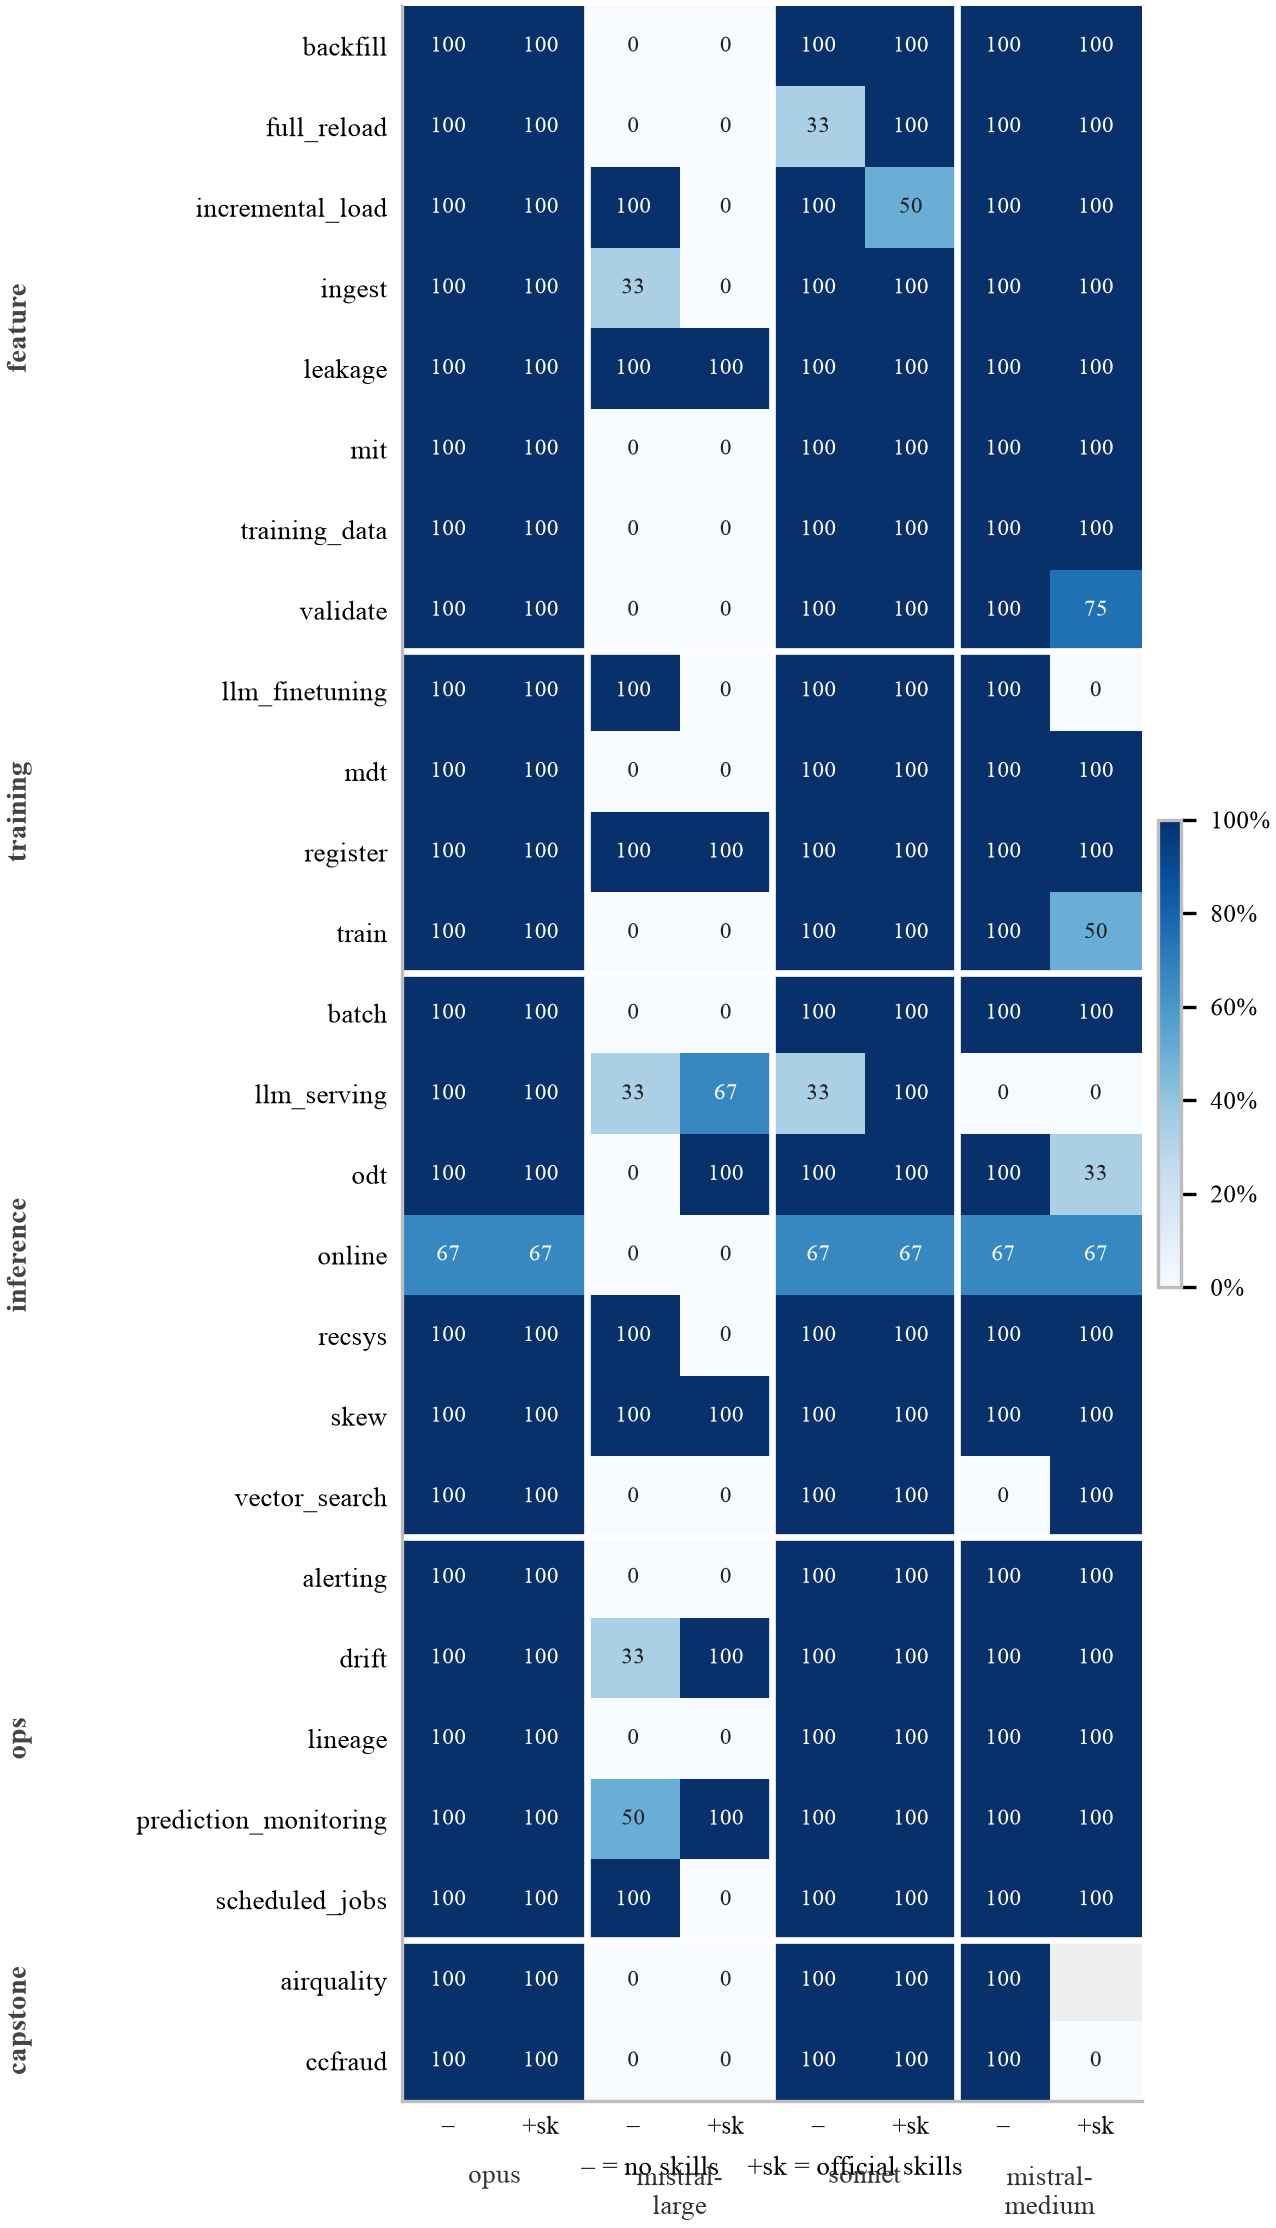

**benchmark_tasks_databricks_sdk.png**

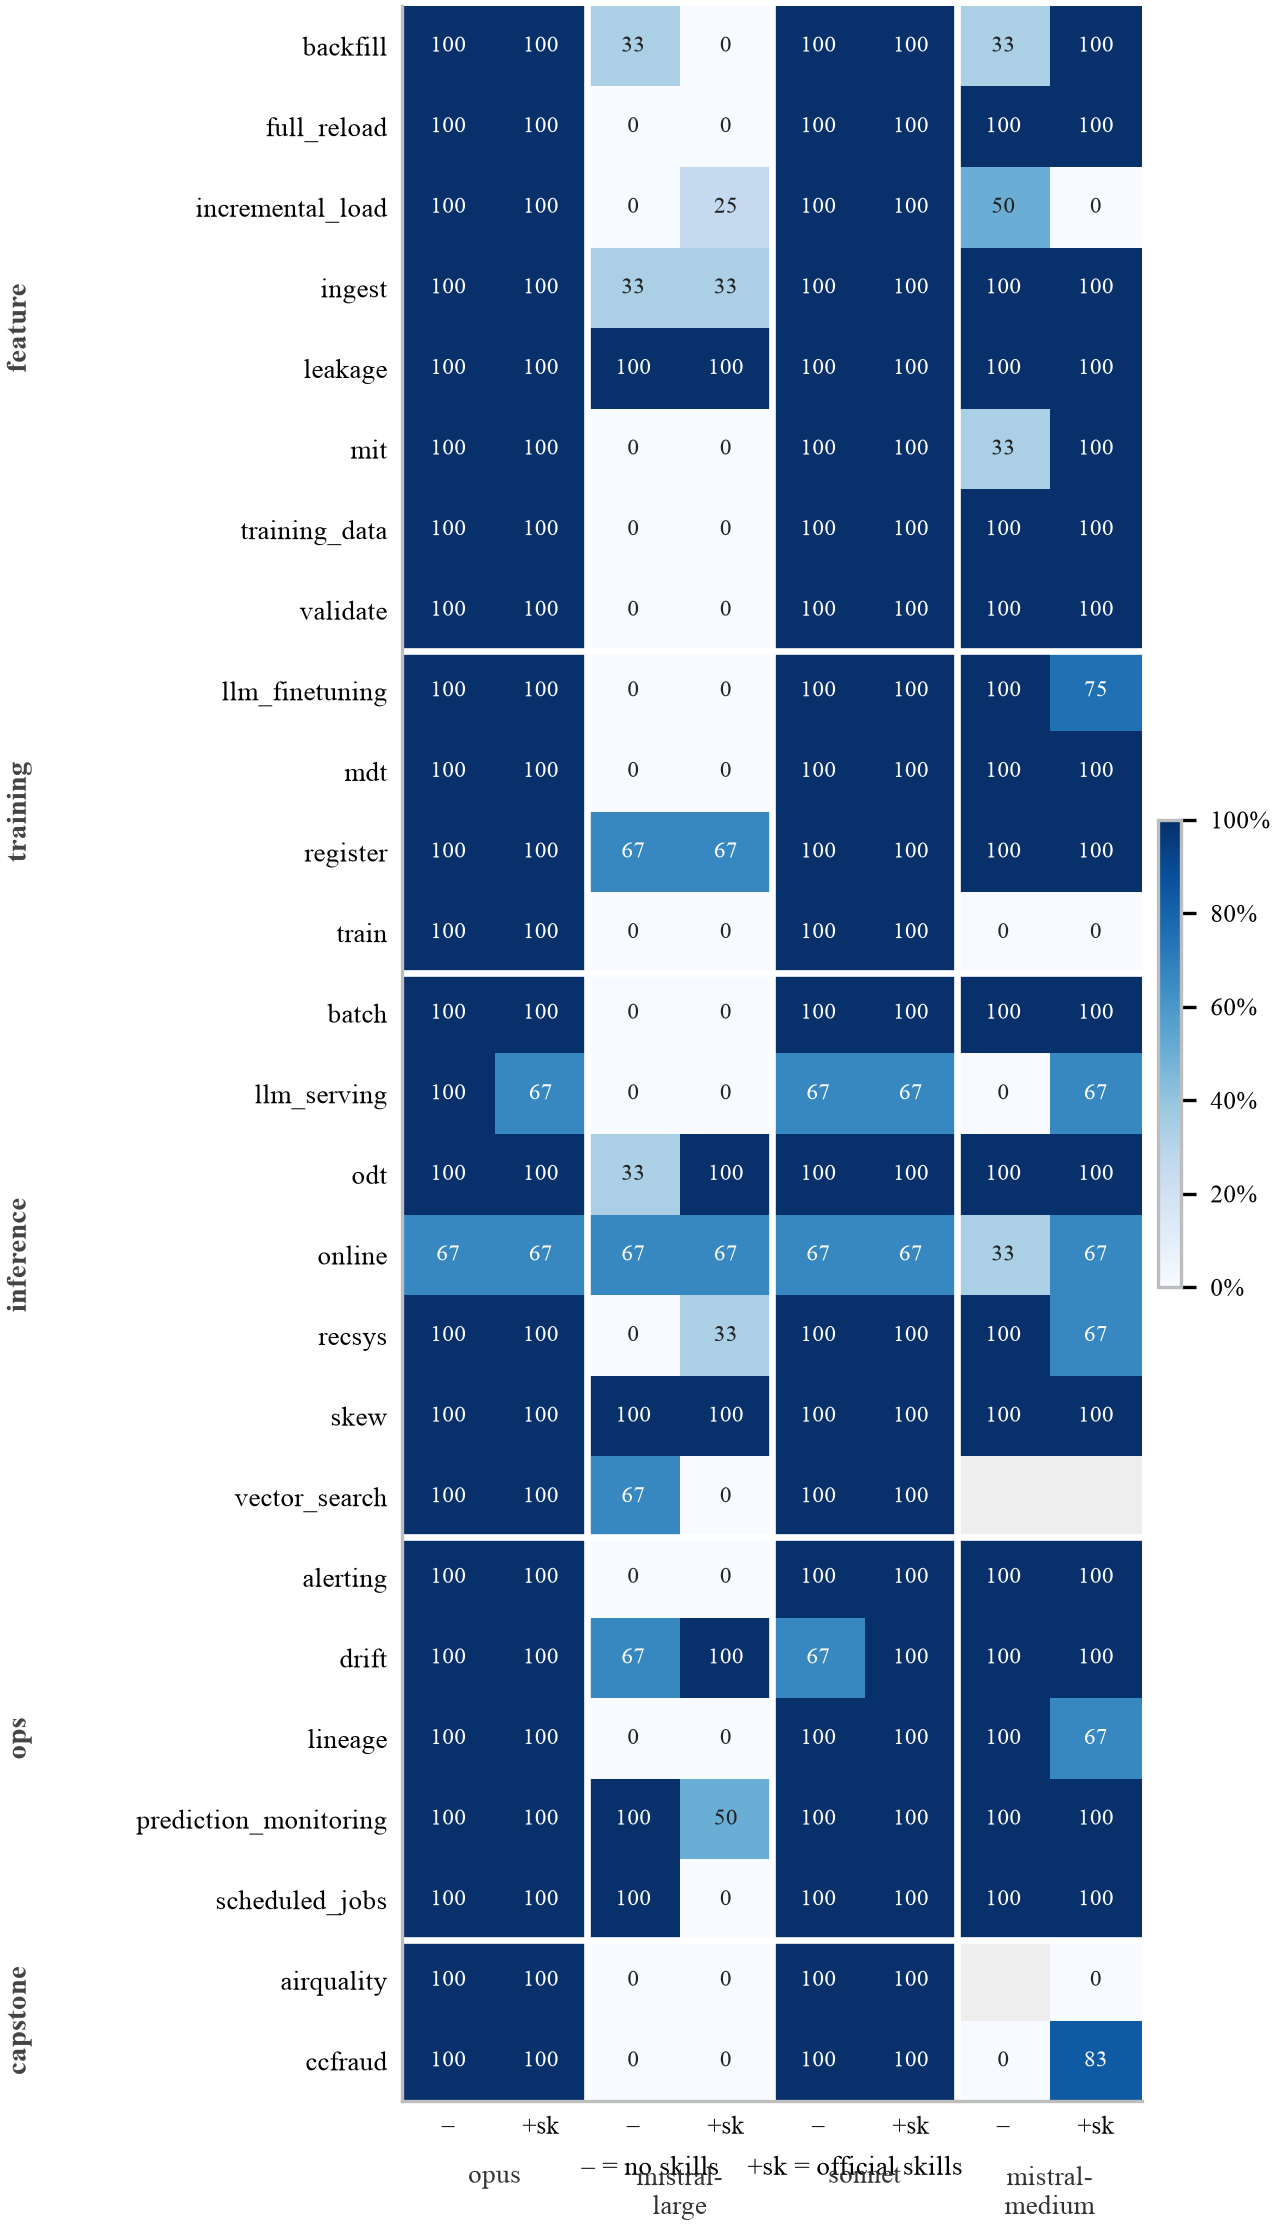

**benchmark_tasks_hopsworks_cli.png**

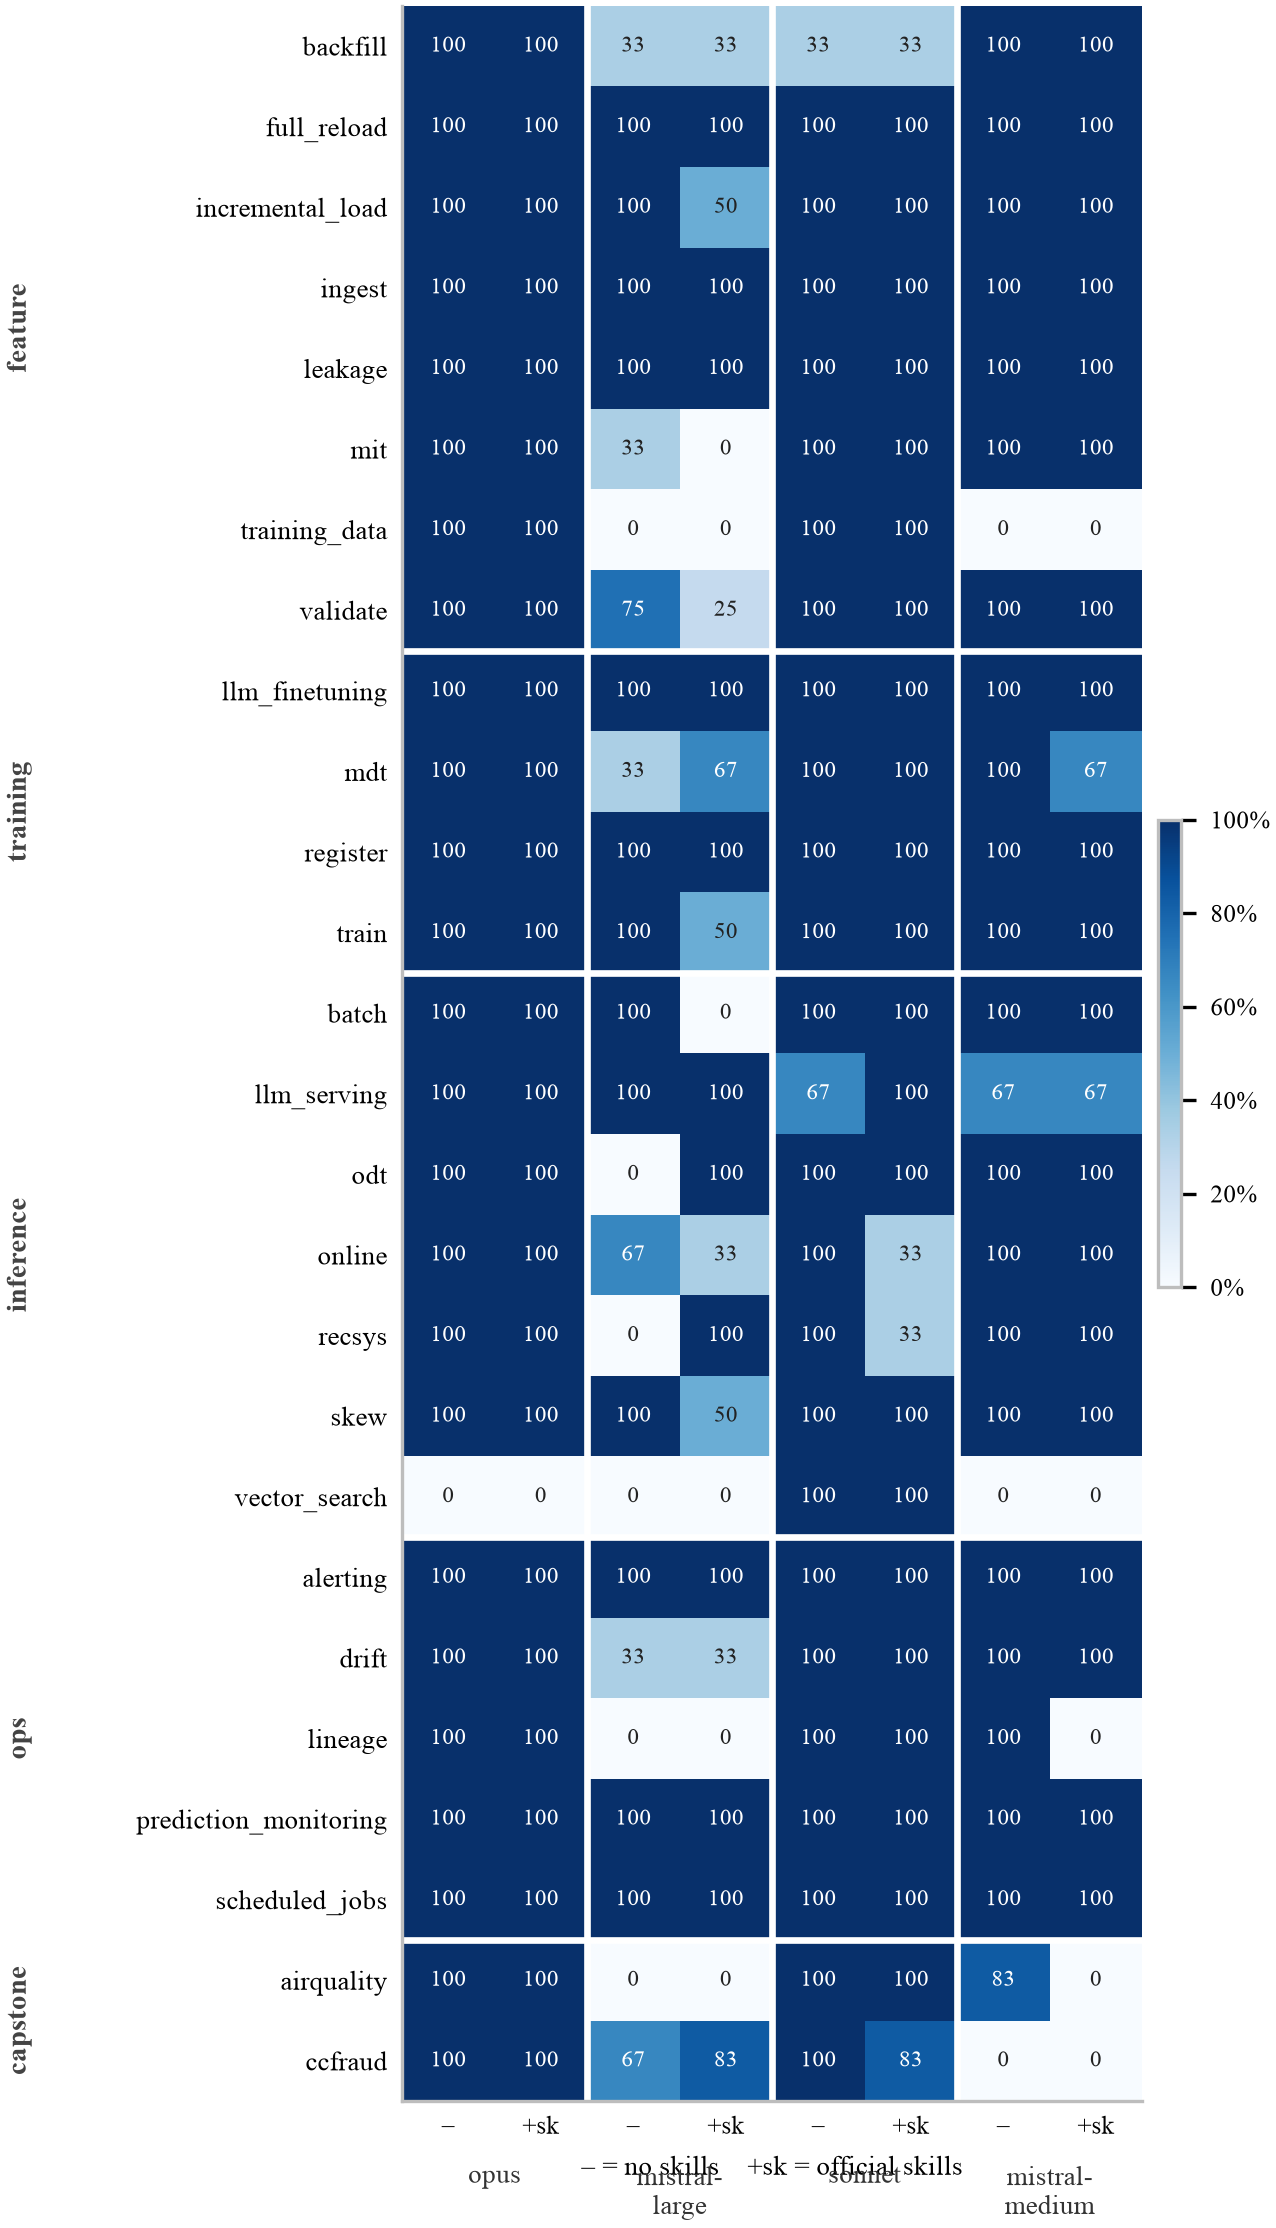

**benchmark_tasks_hopsworks_sdk.png**

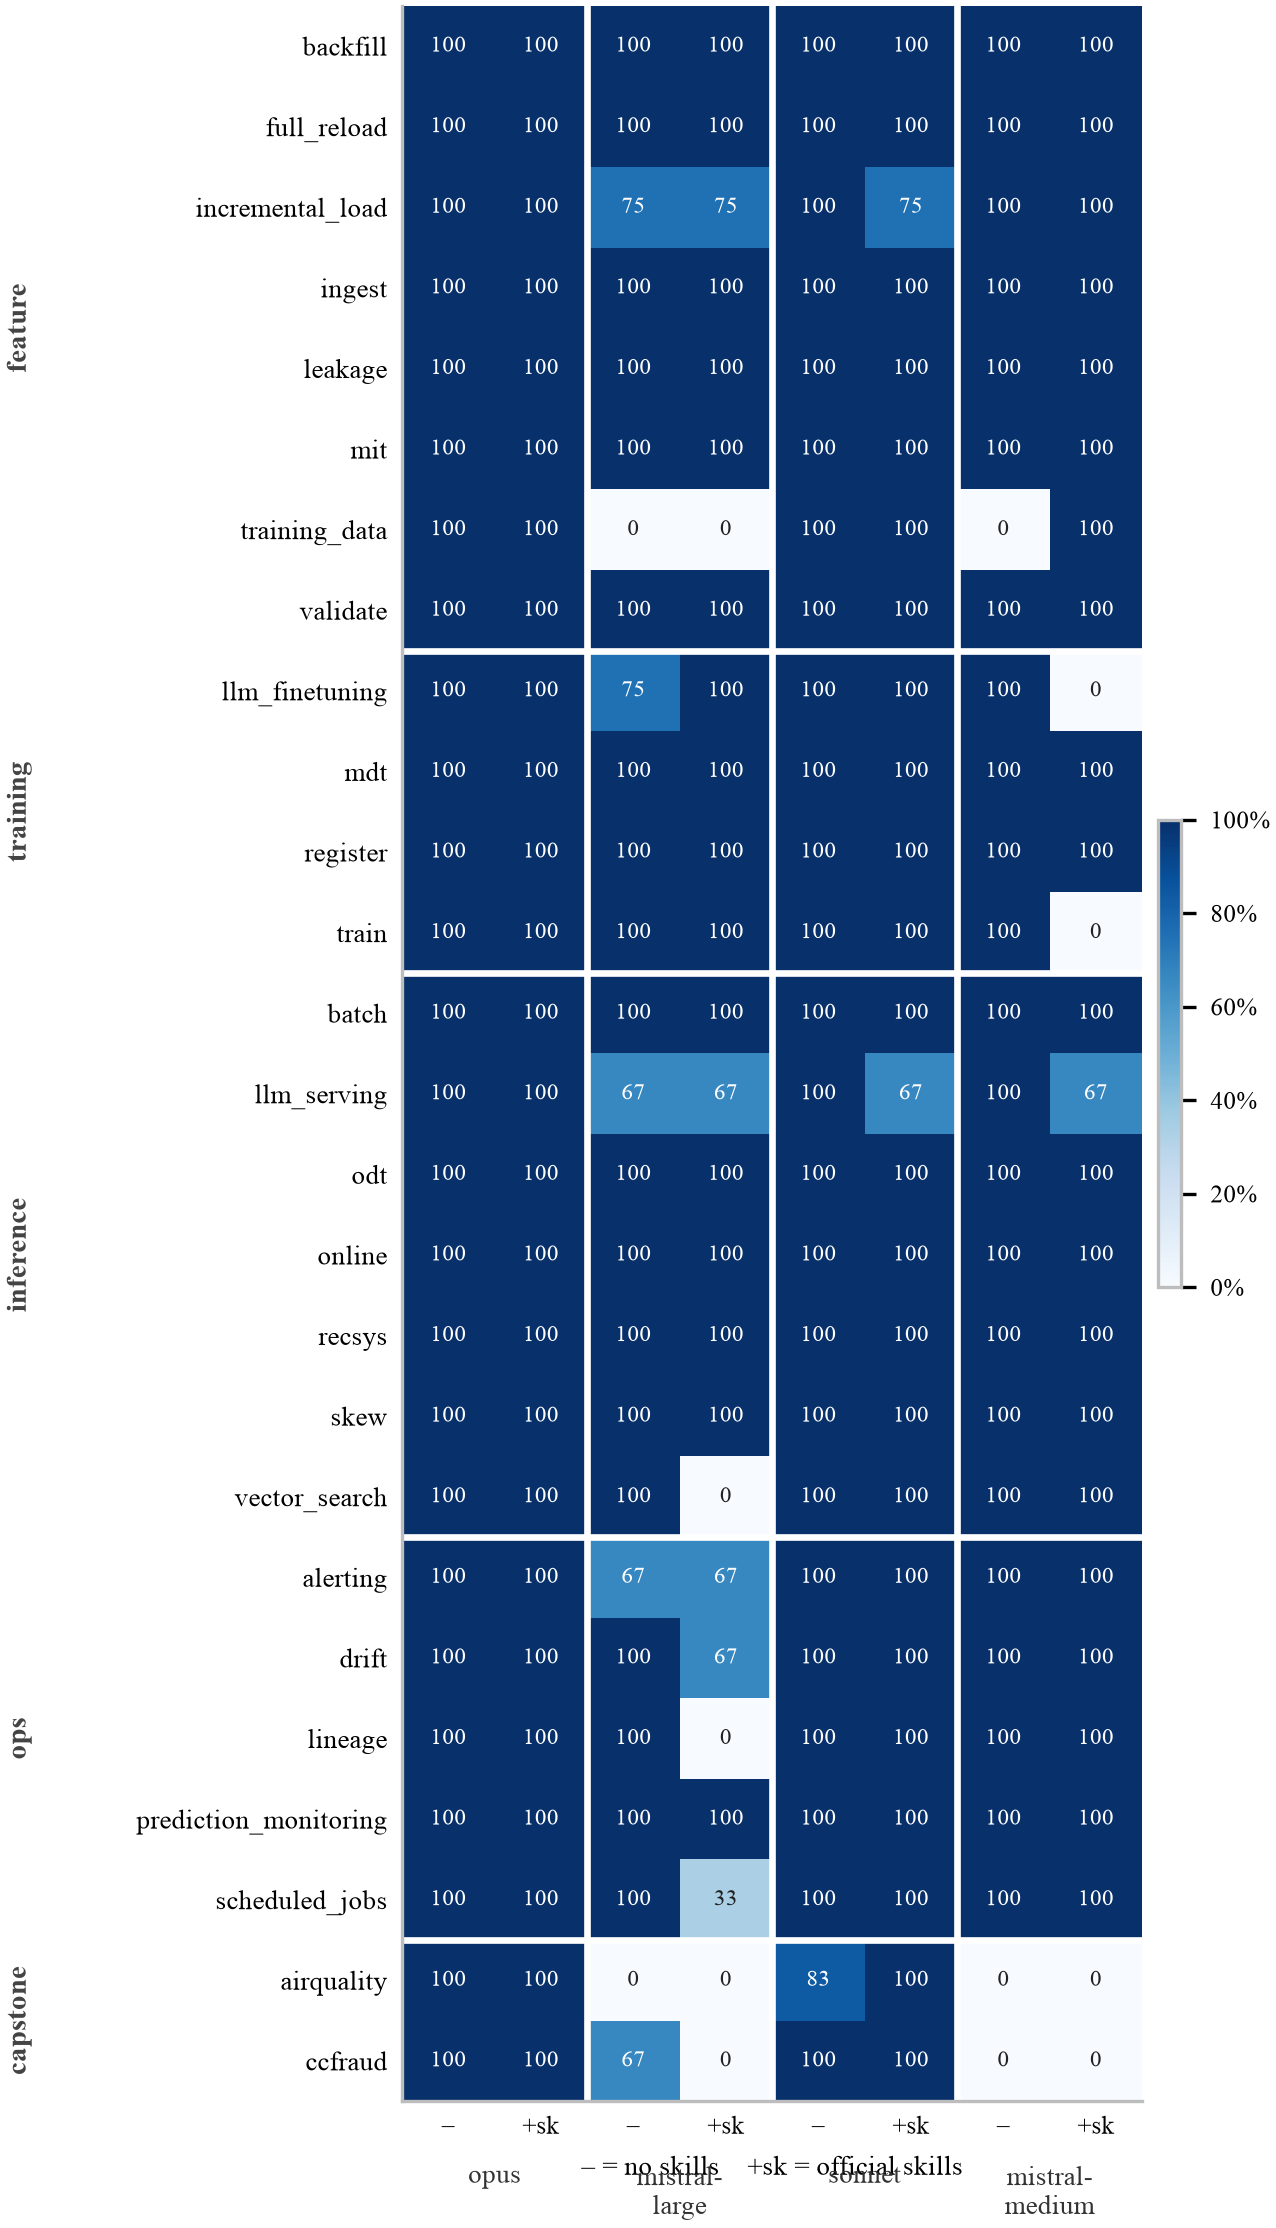

### optimizations

**optimizations_efficiency_cost.png**

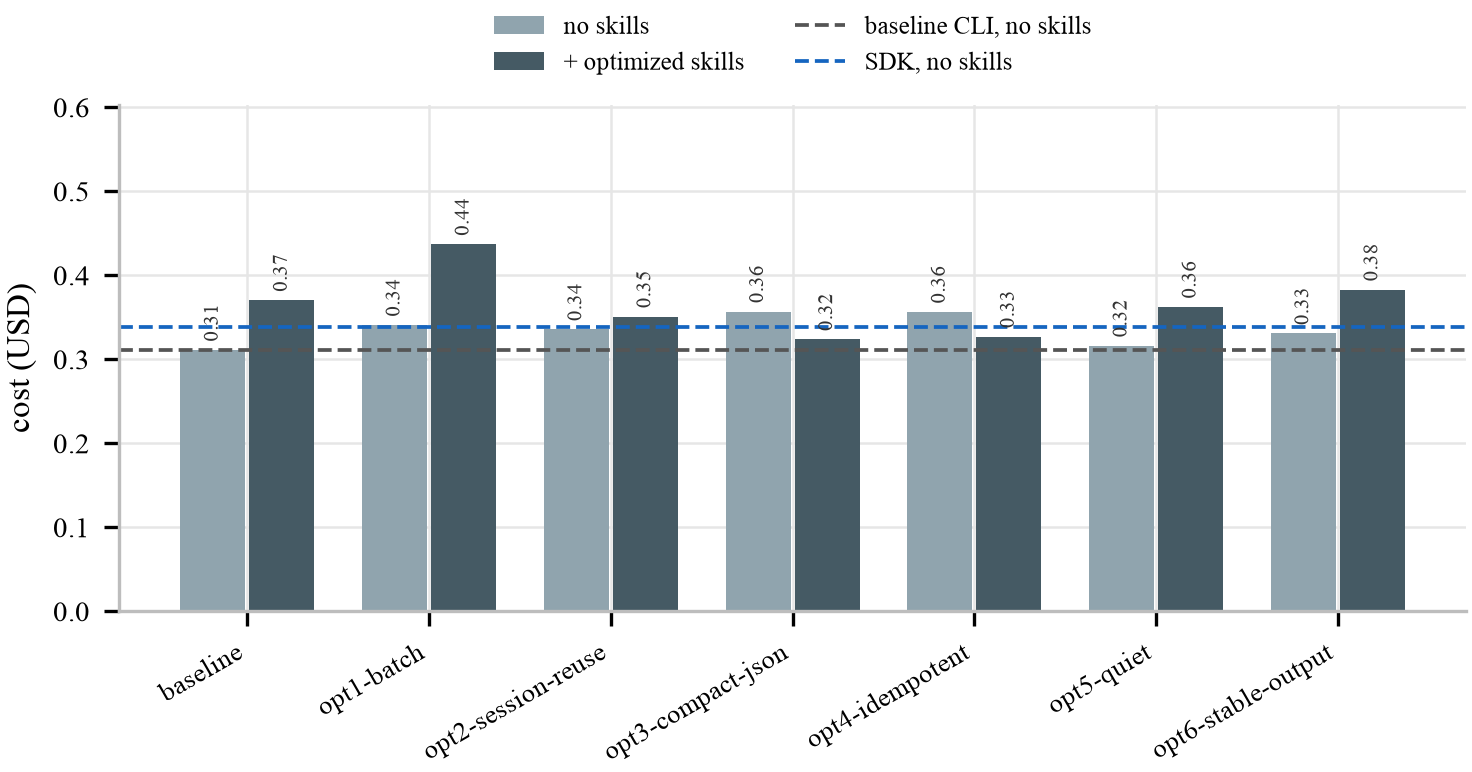

**optimizations_efficiency_time.png**

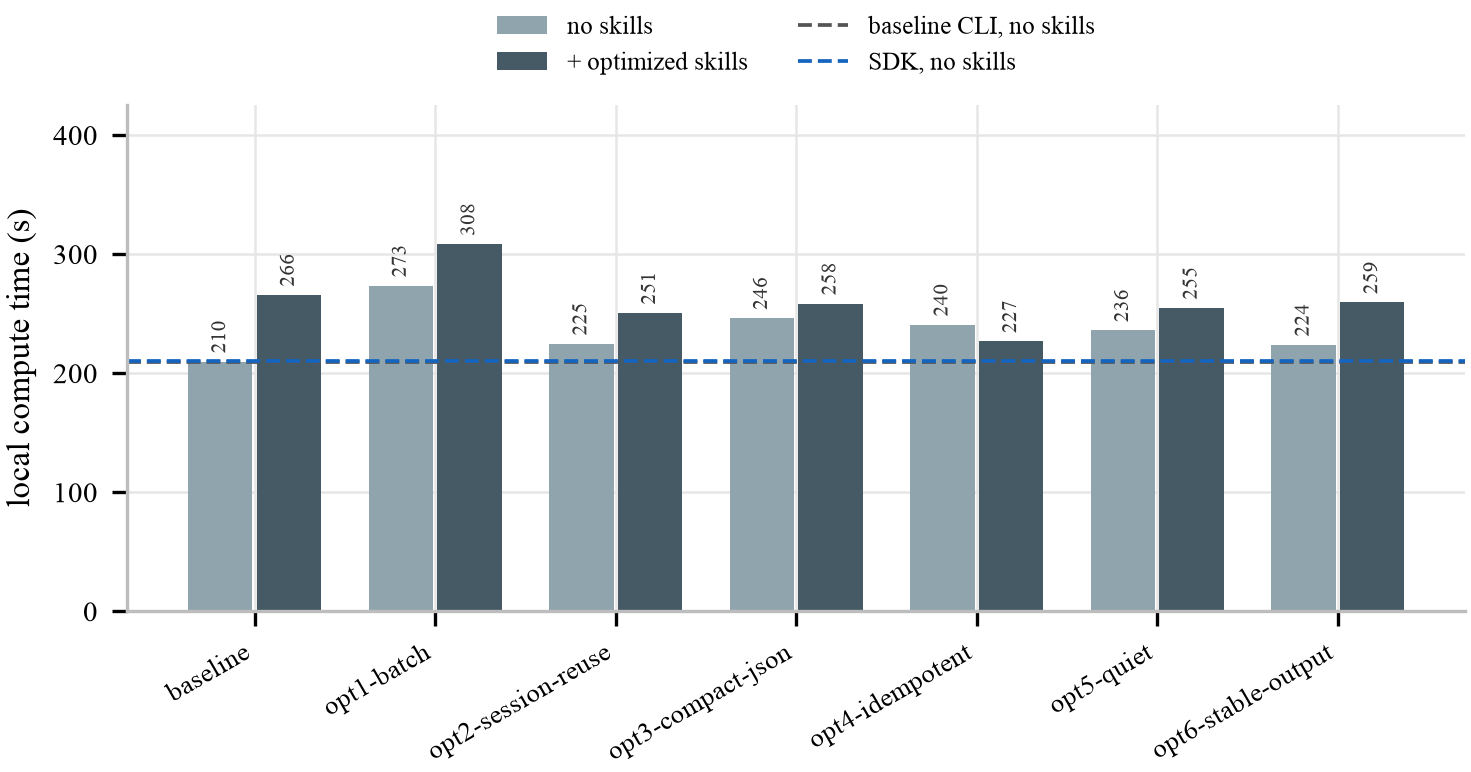

**optimizations_efficiency_turns.png**

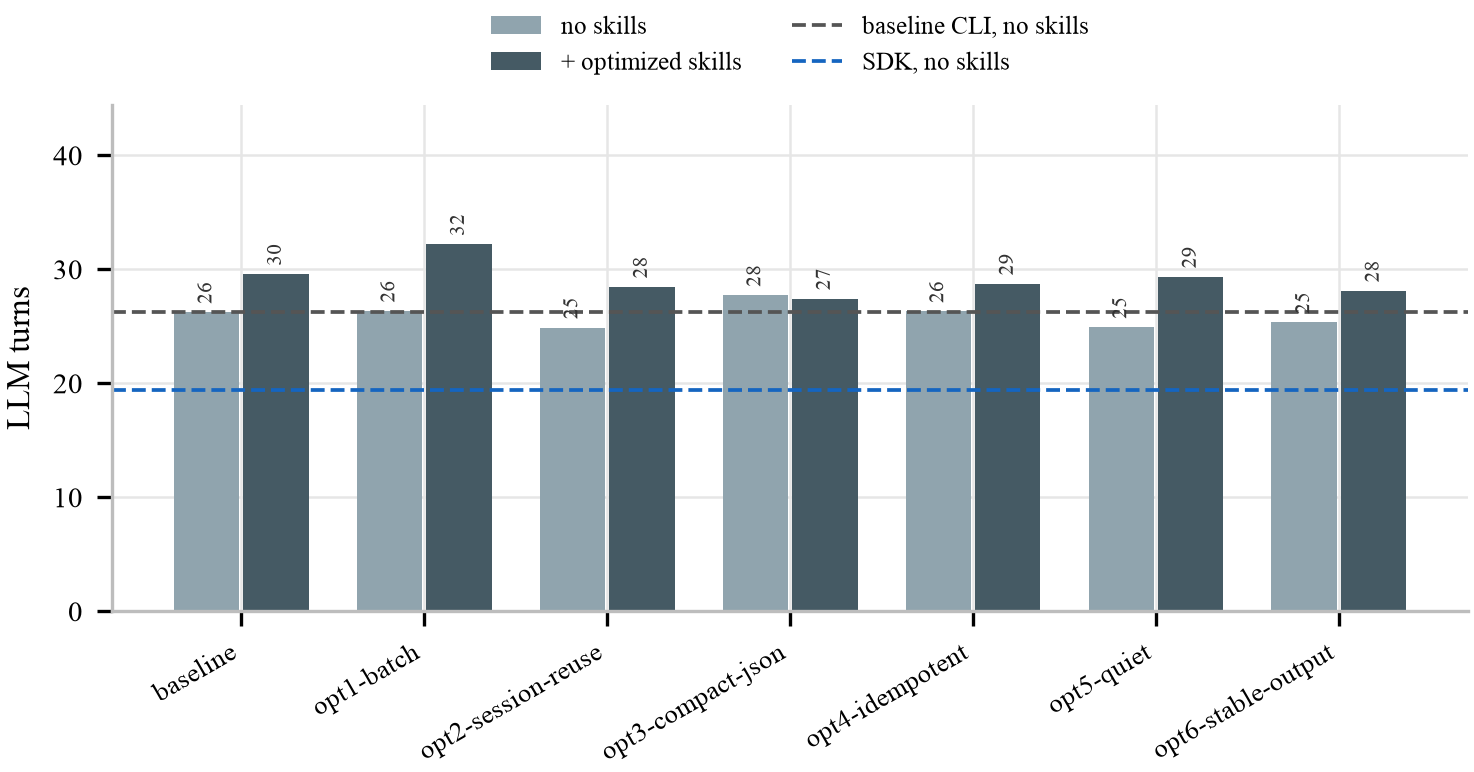

**optimizations_pass.png**

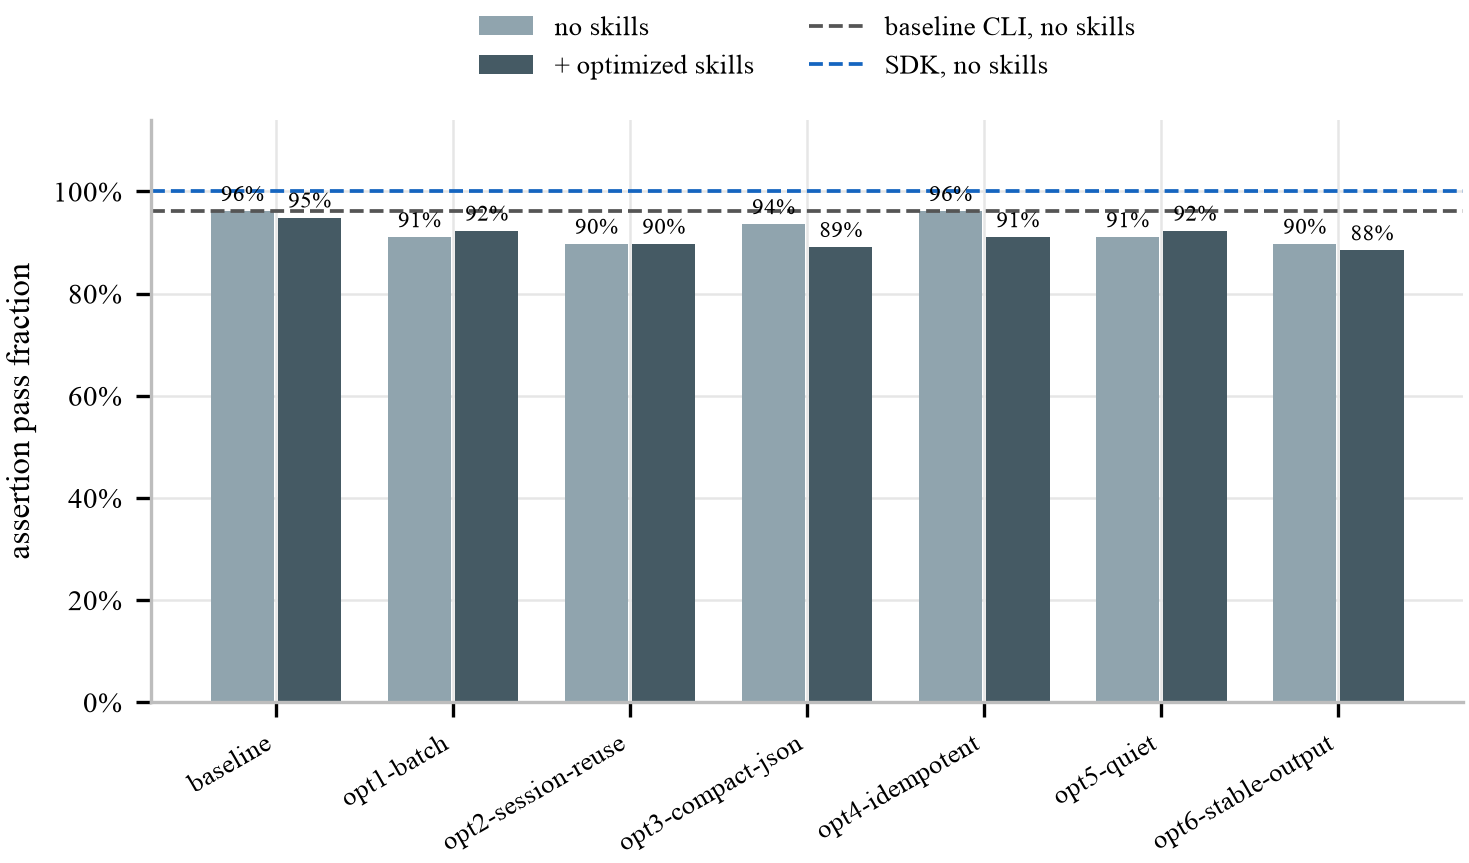

**optimizations_stats_cli.png**

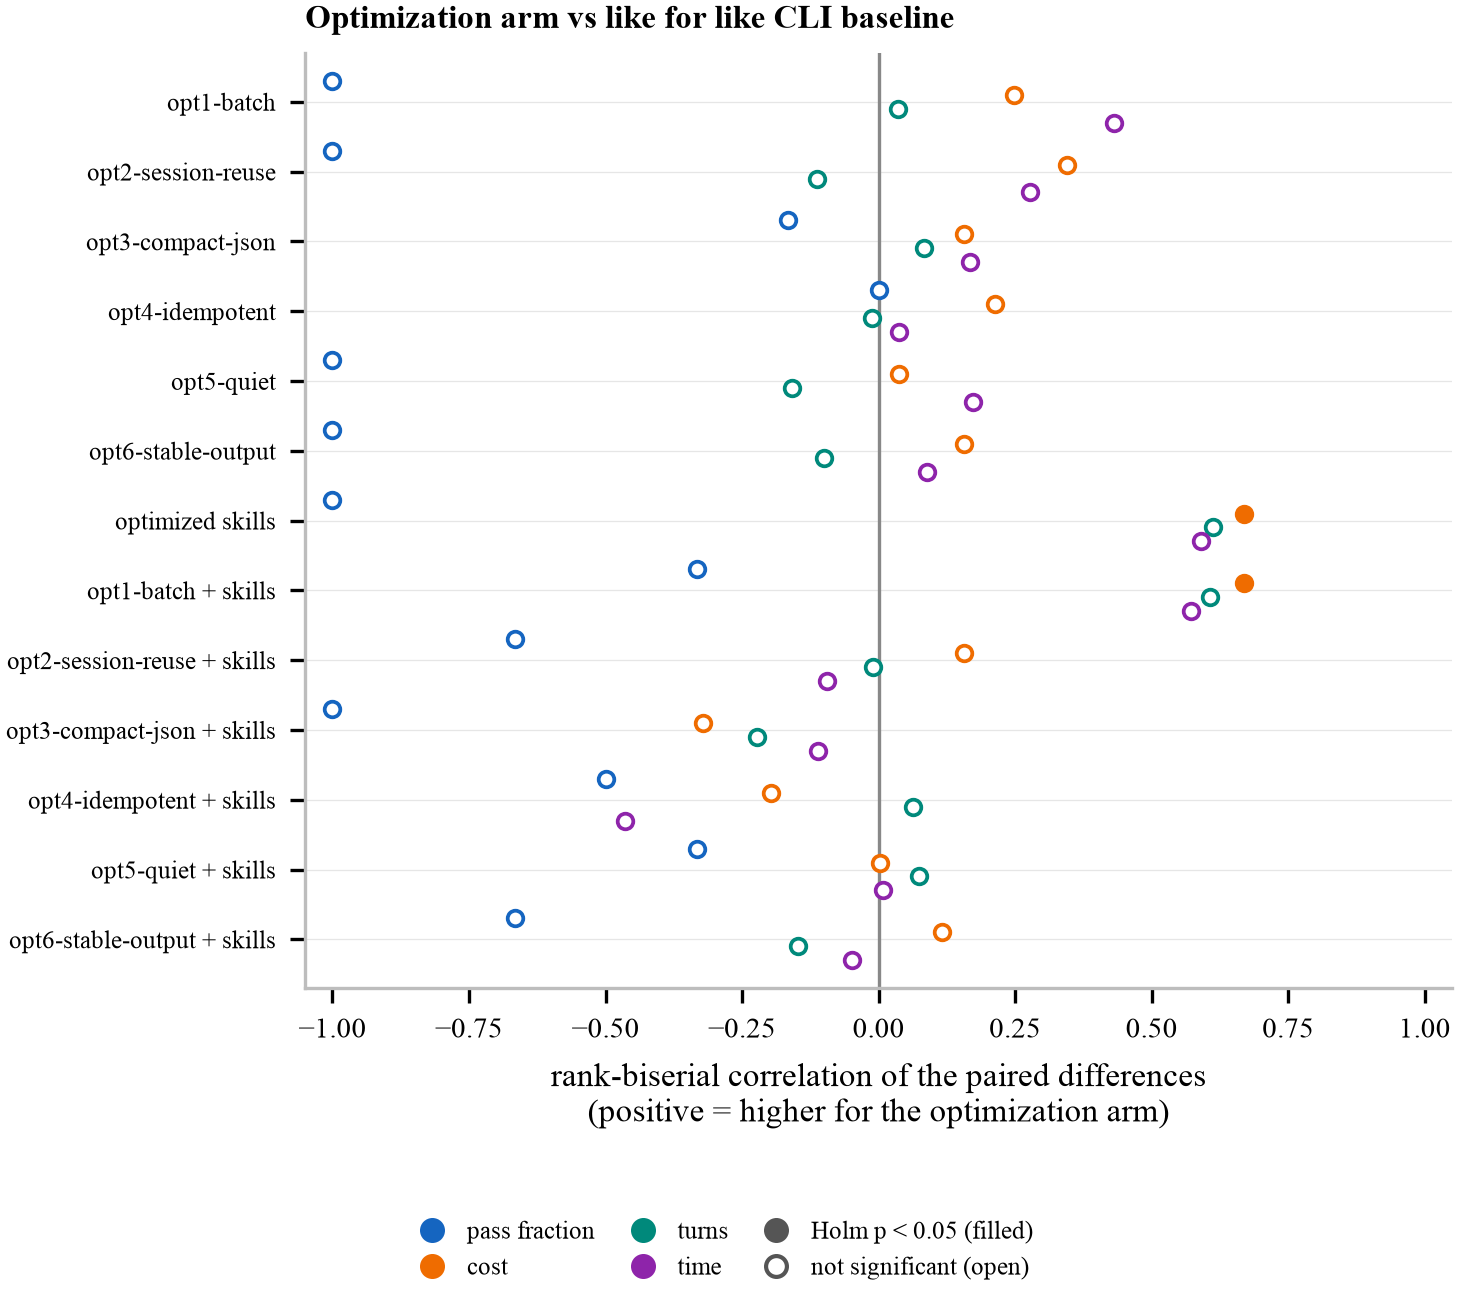

**optimizations_stats_sdk.png**

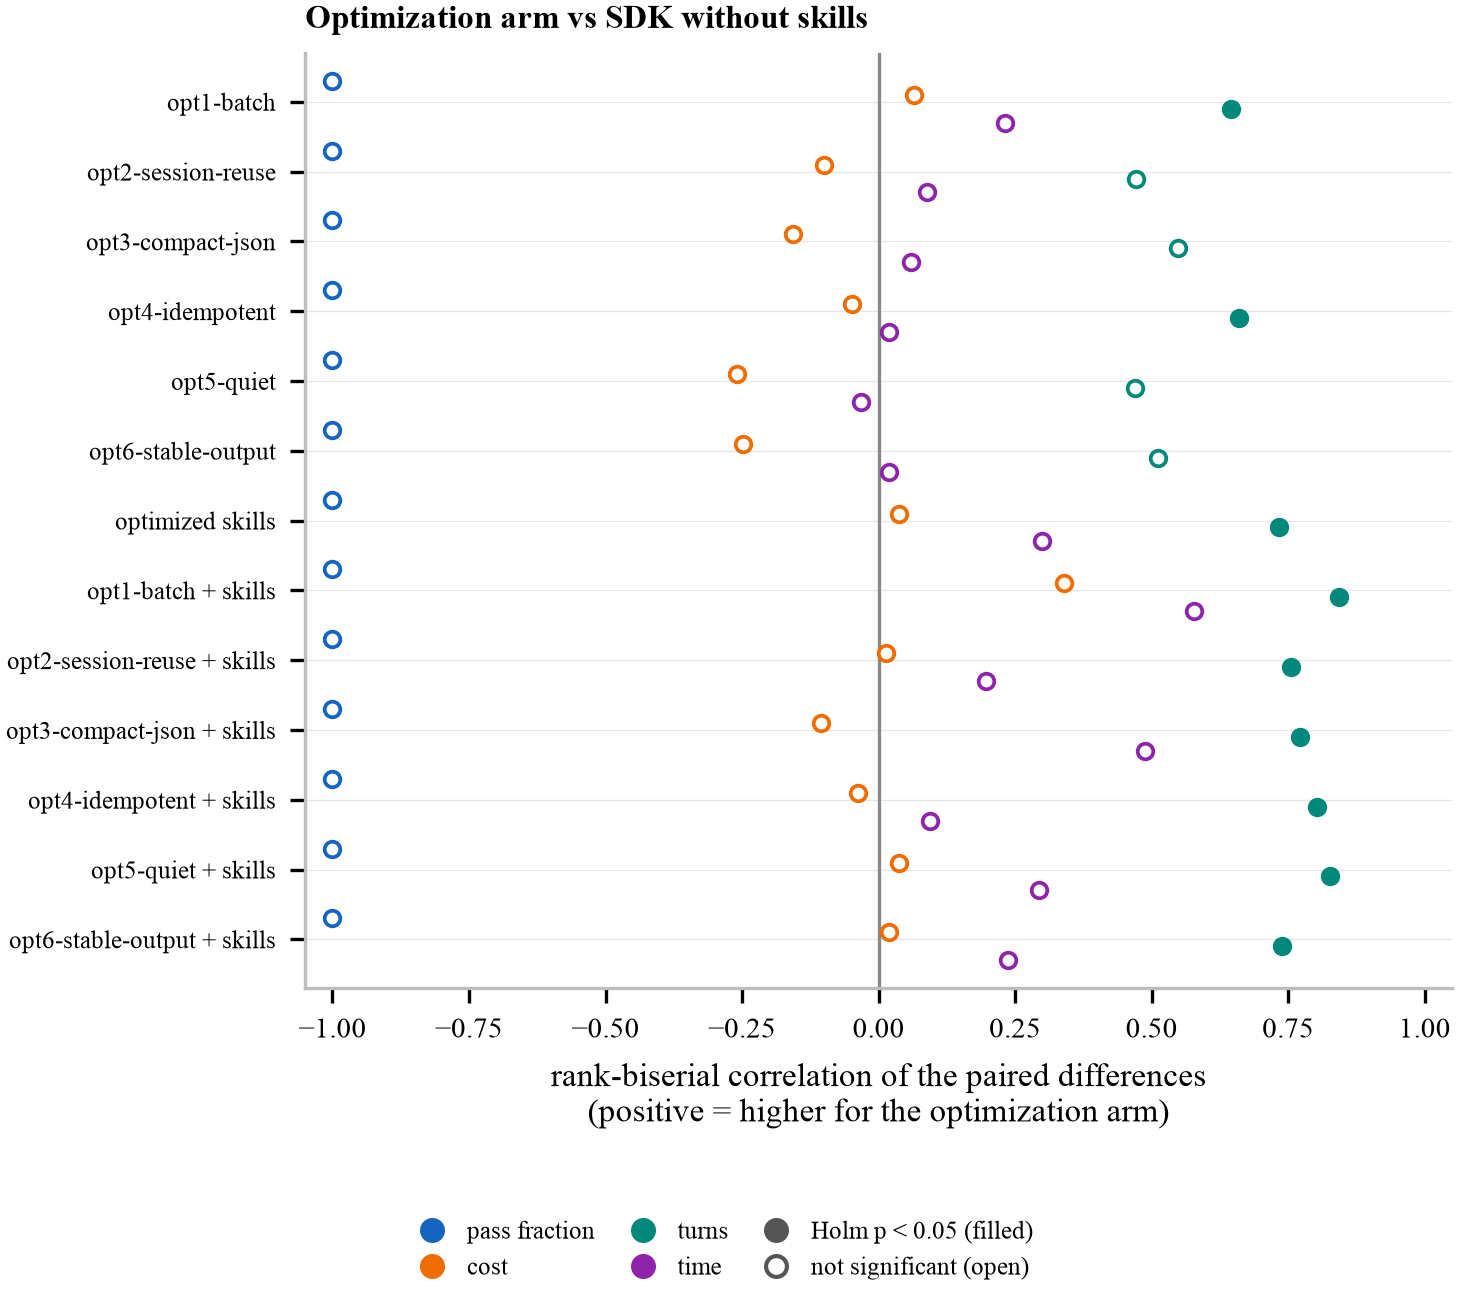

In [21]:
from IPython.display import Image, Markdown, display

for folder in ["market", "benchmark", "optimizations"]:
    display(Markdown(f"### {folder}"))
    for png in sorted(Path(f"../docs/thesis/img/{folder}").glob("*.png")):
        display(Markdown(f"**{png.name}**"))
        display(Image(str(png), width=700))